# Spectral_Analysis — part 5 of 7

This notebook was automatically split from a larger notebook.

# Spectral Entropy

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>Utilising Welch's method, an adaptation of Fourier Transform designed for reducing noise and improving spectral estimate accuracy, the EEG data is transposed from the time to the frequency domain. This is achieved using the `welch` function from the `scipy.signal` library with a sampling frequency \( f_s \) of 1000 Hz and a segment length \( n_{\text{perseg}} \) of 2000 samples. The output is a power spectral density (PSD), \( P_{xx} \), which is then normalised to serve as a probability density function (PDF). Mathematically, the Shannon spectral entropy \( H \) is calculated as:</p>
        <p>
        \[
        H = -\sum_{i} p(x_i) \log_2 p(x_i)
        \]
        </p>
        <p>Where \( p(x_i) \) are the probabilities corresponding to the power at each frequency bin in \( P_{xx} \). Shannon's entropy serves as an apt measure to gauge the complexity and variability inherent in neural signals. </p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>In the neuroscientific sphere, the algorithm interrogates EEG channels that span strategic cortical regions, thereby permitting an enriched understanding of different cognitive and motor functions. Spectral entropy functions as an incisive index for assessing neural complexity and has found applications in delineating various mental states such as relaxation, attention, and cognitive load, as well as pathological states including epilepsy and Alzheimer's disease. </p>
        <p>The code is structured to iterate through each EEG channel, calculate its power spectral density, normalise this density, and derive its spectral entropy. These entropy values are meticulously stored in a Python dictionary, which dovetails with the code's modular architecture. Finally, the spectral entropy values are visualised through a bar graph, offering an intuitive medium for channel-wise comparisons. This is enabled through Python libraries like `numpy`, `matplotlib`, and `scipy`, thus amalgamating computational efficacy with rigorous mathematical and neuroscientific reasoning.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


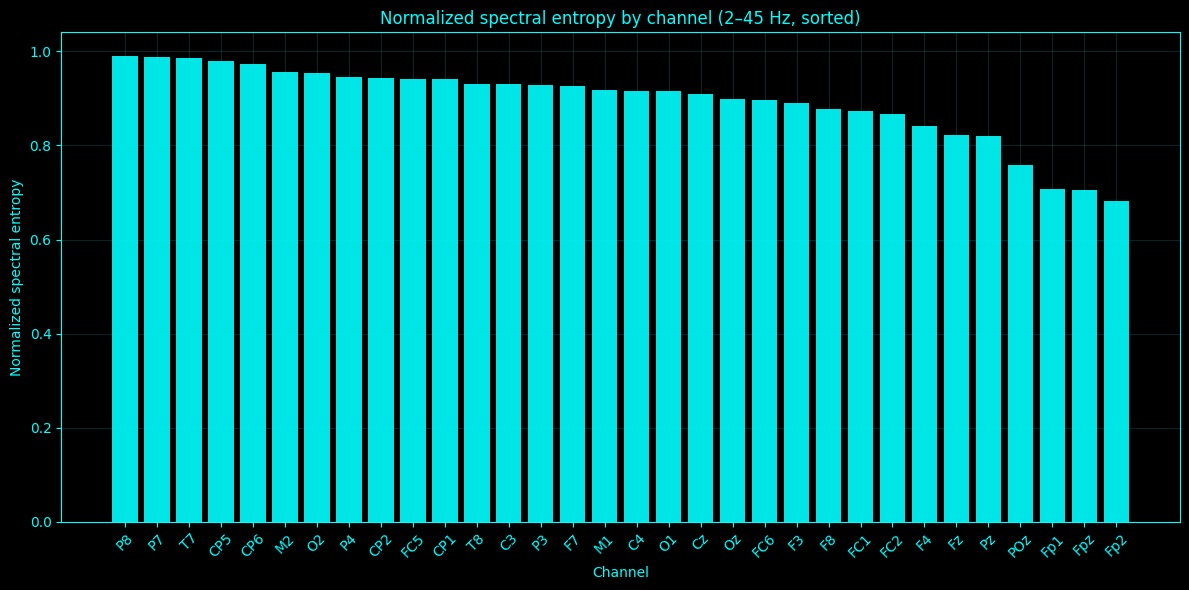

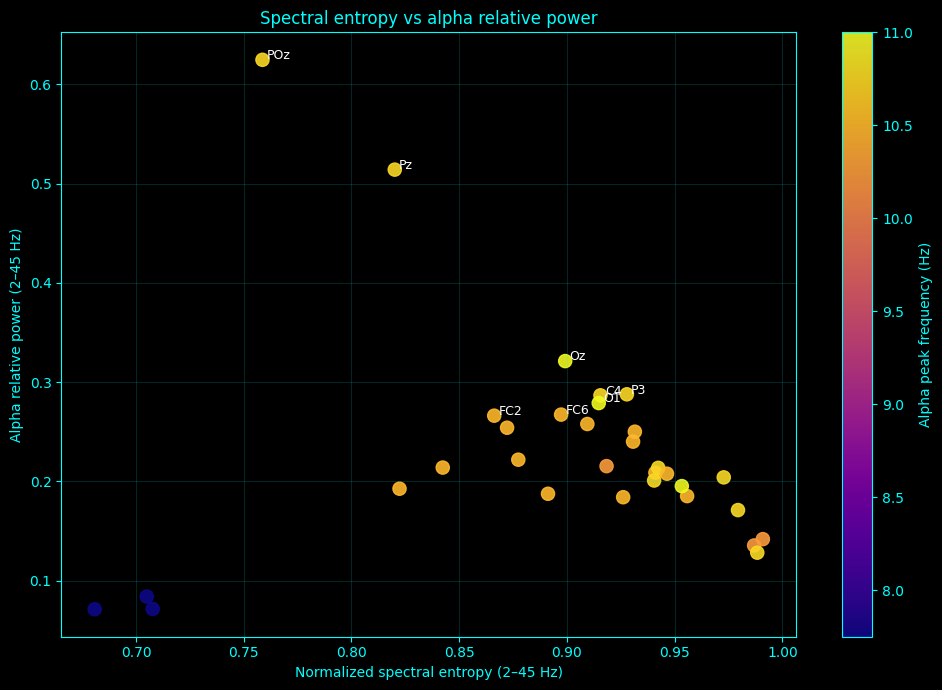

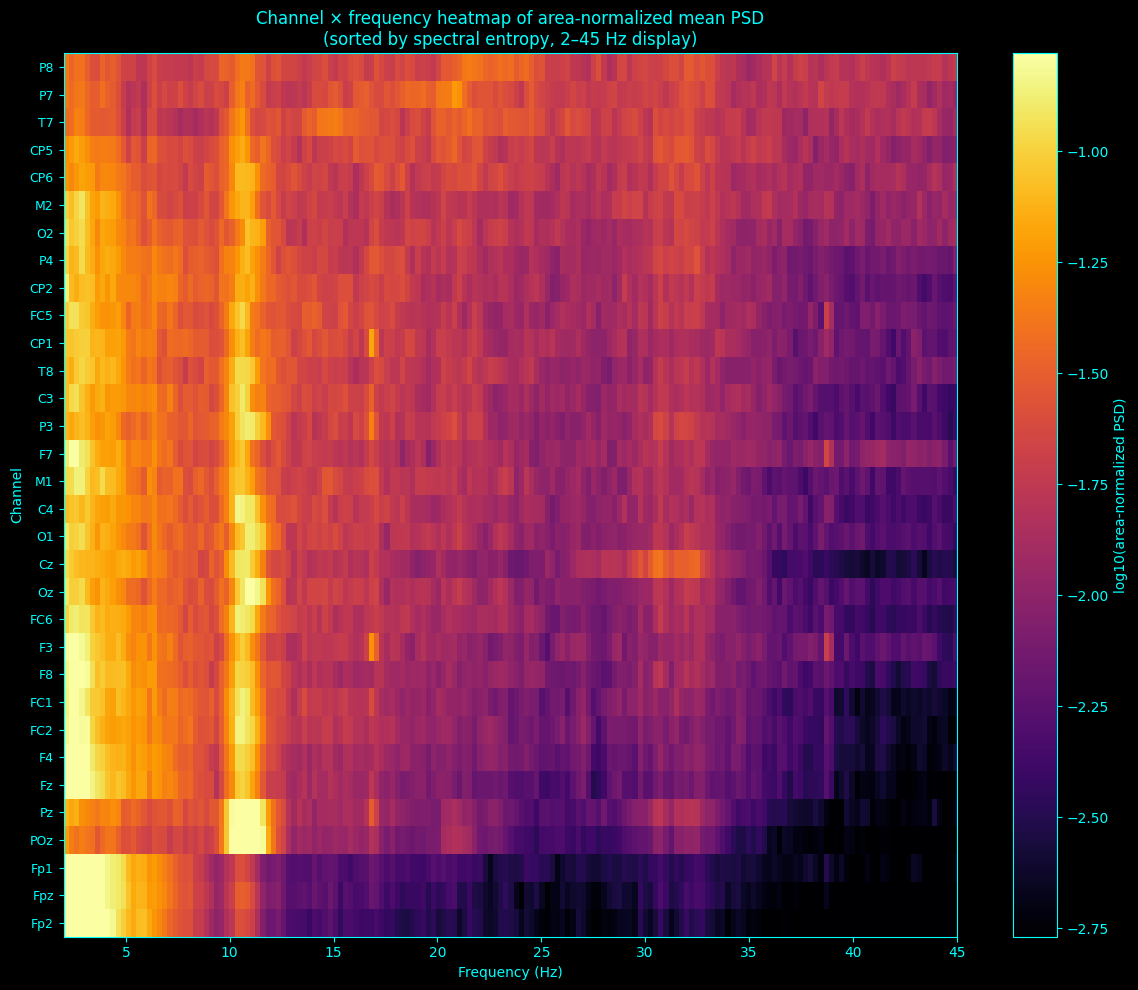

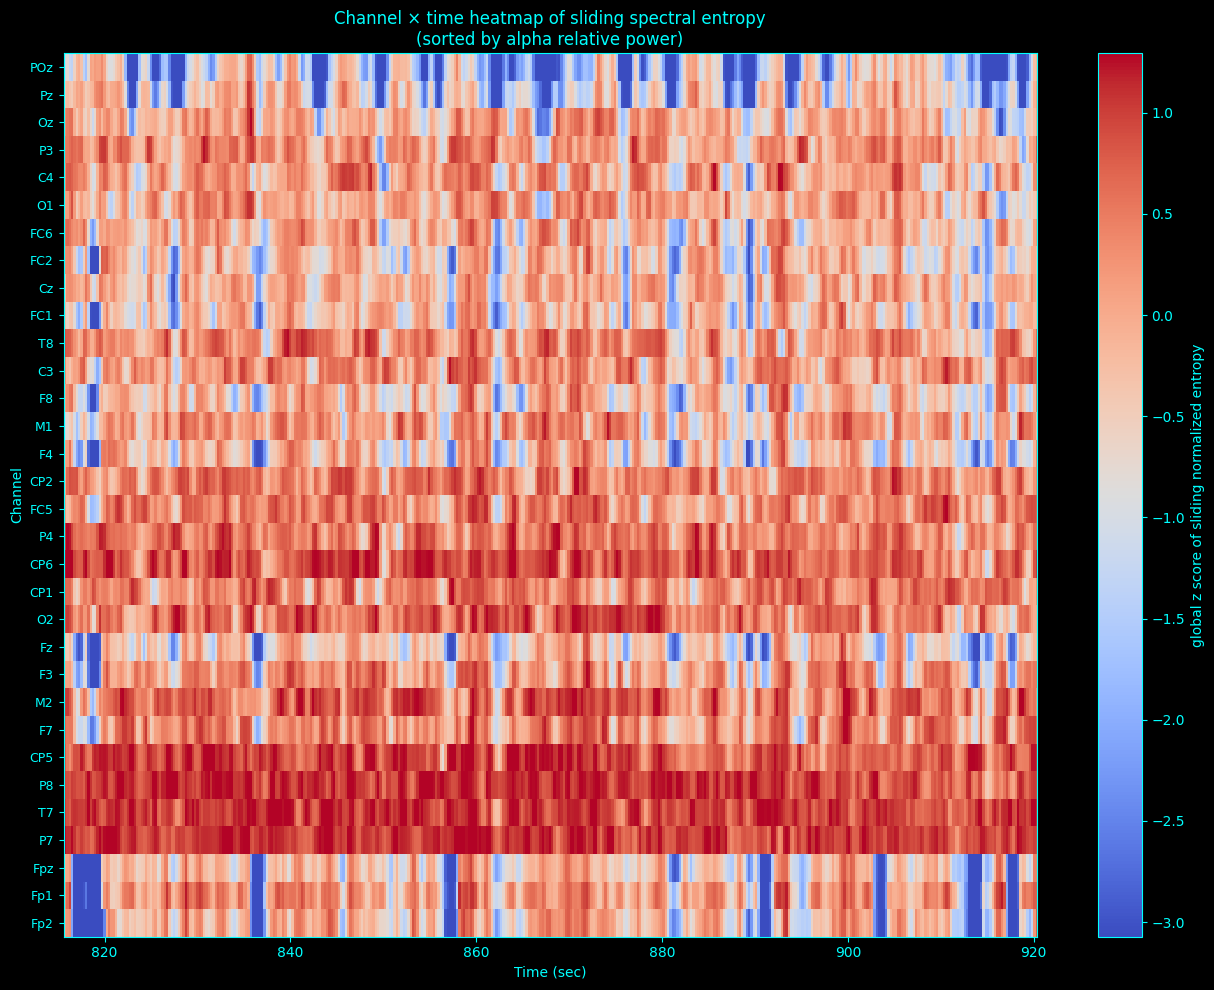

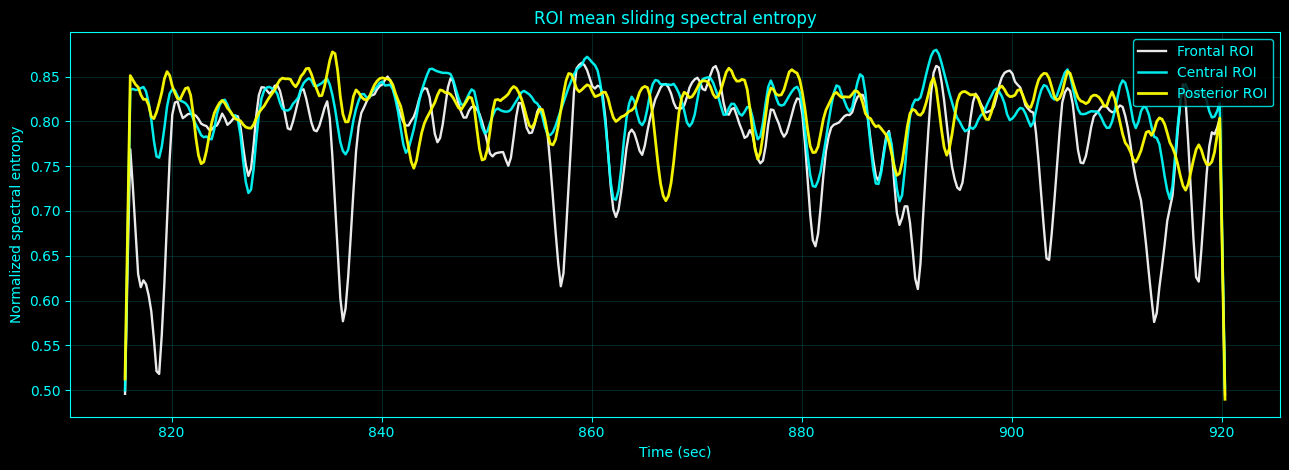

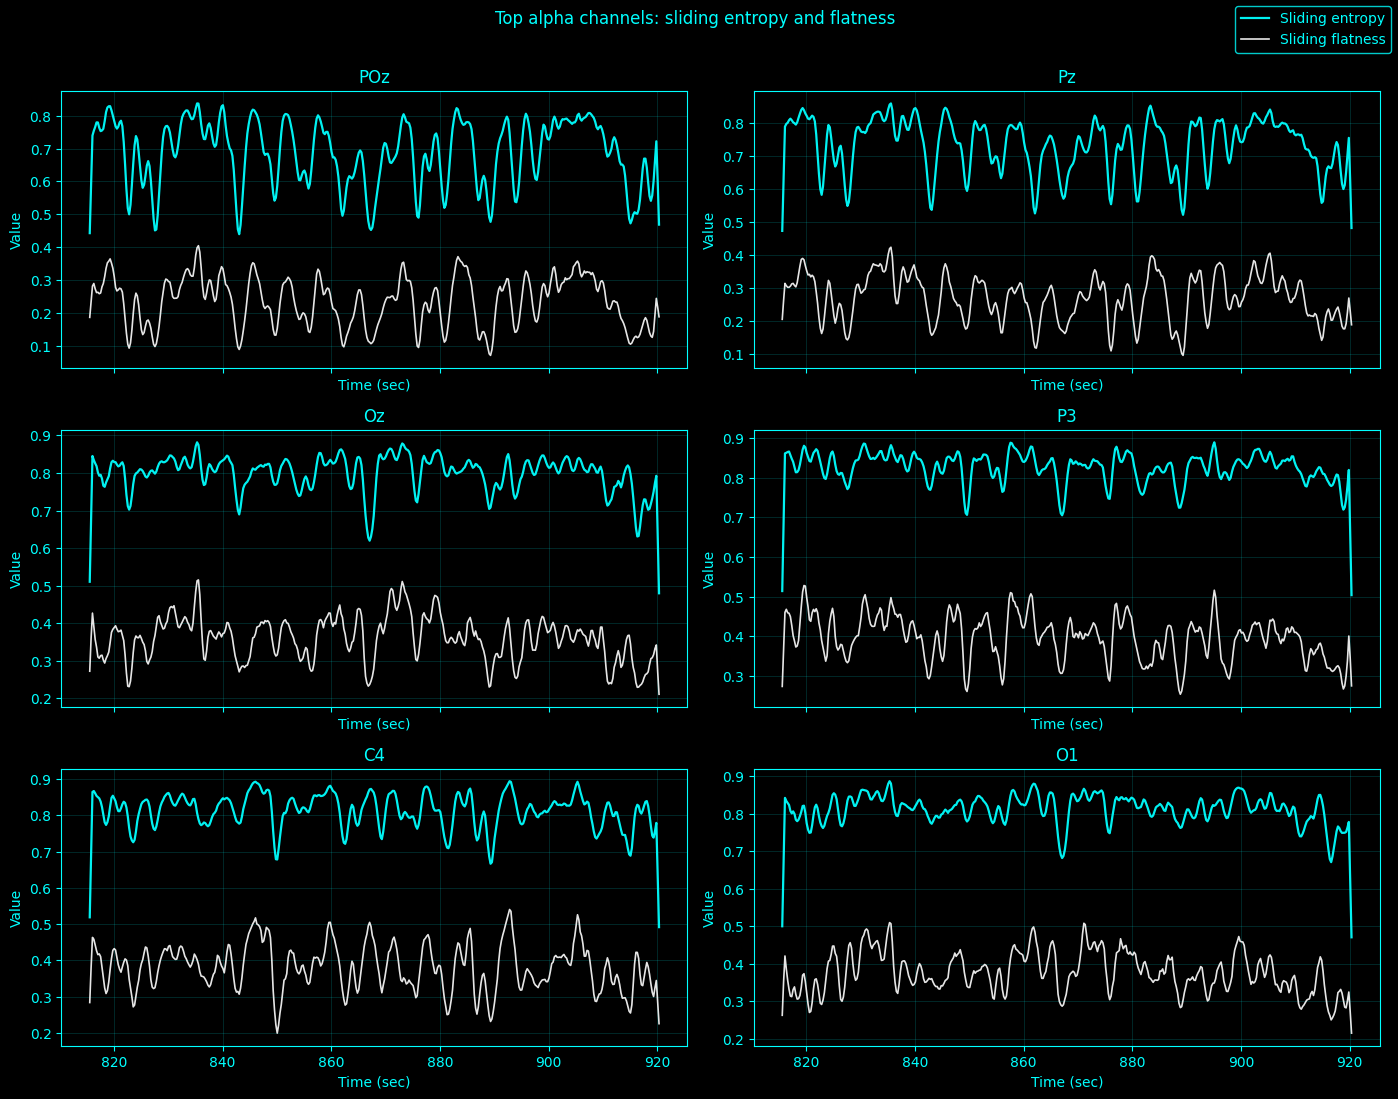


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_entropy/SpectralEntropy_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_entropy/exploratory_spectral_entropy_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_entropy/spectral_entropy_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_entropy/exploratory_spectral_entropy_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_entropy/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_spectral_entropy")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Spectral-entropy design
# Use 2–45 Hz as the main comparison band so DC drift and 60 Hz do not dominate the geometry.
entropy_band = (2.0, 45.0)
full_display_band = (1.0, 60.0)
alpha_search_band = (7.0, 13.0)

# Welch settings
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = None
detrend_mode = "constant"

# Sliding entropy settings
sliding_window_sec = 2.0
sliding_step_sec = 0.25

# Preprocessing
apply_common_average_reference = False

# Channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def shannon_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True, log_base=2):
    """
    Spectral entropy from area-normalized PSD inside a chosen band.
    normalize=True returns entropy / log(K), so values lie in [0, 1].
    """
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    log_fn = np.log2 if log_base == 2 else np.log
    H = -np.sum(p * log_fn(p + eps))
    Hmax = log_fn(len(p) + eps)
    Hnorm = H / (Hmax + eps) if normalize else H

    effective_rank = float(np.exp((-np.sum(p * np.log(p + eps)))))
    return float(H), float(Hnorm), effective_rank

def spectral_flatness_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx > 0)
    if np.sum(mask) < 2:
        return np.nan
    p = np.asarray(pxx[mask], dtype=float)
    gm = np.exp(np.mean(np.log(p + eps)))
    am = np.mean(p)
    return float(gm / (am + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]
    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    c = np.cumsum(p)
    if c[-1] <= 0:
        return np.nan

    c = c / c[-1]
    idx = int(np.searchsorted(c, edge))
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def roi_average_vector(values, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.nan
    return float(np.nanmean(values[idx]))

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

def sliding_entropy_series(y, fs, band=(2.0, 45.0), window_sec=2.0, step_sec=0.25):
    win = max(int(round(window_sec * fs)), 256)
    step = max(int(round(step_sec * fs)), 1)

    centers_sec = []
    H_raw = []
    H_norm = []
    flatness = []

    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]

        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend_mode,
            nfft=None,
        )

        H, Hn, _ = shannon_entropy_from_psd(freqs_hz, pxx, band=band, normalize=True, log_base=2)
        sf = spectral_flatness_from_psd(freqs_hz, pxx, band=band)

        centers_sec.append((start + stop) / 2.0 / fs)
        H_raw.append(H)
        H_norm.append(Hn)
        flatness.append(sf)

    return np.asarray(centers_sec), np.asarray(H_raw), np.asarray(H_norm), np.asarray(flatness)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
spectral_entropy_dict = {}
mean_psd_matrix = []
sliding_entropy_matrix = []
sliding_flatness_matrix = []
time_centers_ref = None

summary_rows = []

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    H_raw, H_norm, effective_rank = shannon_entropy_from_psd(
        freqs_hz,
        pxx,
        band=entropy_band,
        normalize=True,
        log_base=2,
    )

    flatness = spectral_flatness_from_psd(freqs_hz, pxx, band=entropy_band)
    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, entropy_band)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        freqs_hz,
        mean_psd_norm,
        band=alpha_search_band,
        smooth_win=7,
    )

    alpha_rel = integrate_band_1d(freqs_hz, mean_psd_norm, (8.0, 13.0))
    theta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, (4.0, 8.0))
    beta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, (13.0, 30.0))

    sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=entropy_band)
    sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=entropy_band)

    t_centers_sec, H_series, Hn_series, flatness_series = sliding_entropy_series(
        y,
        fs=sampling_rate,
        band=entropy_band,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
    )

    if time_centers_ref is None:
        time_centers_ref = t_centers_sec

    spectral_entropy_dict[ch_name] = {
        "spectral_entropy_bits": H_raw,
        "spectral_entropy_normalized": H_norm,
        "effective_spectral_rank": effective_rank,
        "spectral_flatness": flatness,
        "sliding_entropy_bits": H_series,
        "sliding_entropy_normalized": Hn_series,
        "sliding_flatness": flatness_series,
        "frequencies_hz": freqs_hz,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
    }

    summary_rows.append({
        "channel": ch_name,
        "spectral_entropy_bits_2_45Hz": H_raw,
        "spectral_entropy_normalized_2_45Hz": H_norm,
        "effective_spectral_rank_2_45Hz": effective_rank,
        "spectral_flatness_2_45Hz": flatness,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "alpha_theta_ratio": alpha_rel / (theta_rel + eps),
        "alpha_beta_ratio": alpha_rel / (beta_rel + eps),
        "spectral_edge_50Hz": sef50,
        "spectral_edge_95Hz": sef95,
        "sliding_entropy_mean": float(np.nanmean(Hn_series)),
        "sliding_entropy_std": float(np.nanstd(Hn_series)),
        "sliding_entropy_range": float(np.nanmax(Hn_series) - np.nanmin(Hn_series)),
        "sliding_flatness_mean": float(np.nanmean(flatness_series)),
        "sliding_flatness_std": float(np.nanstd(flatness_series)),
        "has_clear_alpha_peak": bool(np.isfinite(alpha_peak_hz)),
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_entropy_matrix.append(Hn_series)
    sliding_flatness_matrix.append(flatness_series)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
sliding_flatness_matrix = np.column_stack(sliding_flatness_matrix)
time_sec_abs = start_time + time_centers_ref

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "SpectralEntropy_x.npy")
npz_path = os.path.join(out_dir, "exploratory_spectral_entropy_outputs.npz")
summary_csv_path = os.path.join(out_dir, "spectral_entropy_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_spectral_entropy_notes.txt")

np.save(dict_npy_path, spectral_entropy_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_hz,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_entropy_normalized_2_45Hz=sliding_entropy_matrix,
    sliding_flatness_2_45Hz=sliding_flatness_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
)

summary_df.to_csv(summary_csv_path, index=False)

top_entropy = summary_df.sort_values("spectral_entropy_normalized_2_45Hz", ascending=False).head(8)
low_entropy = summary_df.sort_values("spectral_entropy_normalized_2_45Hz", ascending=True).head(8)
top_alpha_ordered = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory spectral entropy notes\n")
    f.write("==================================\n\n")
    f.write("Intent:\n")
    f.write("This pass is a hypothesis-generating summary of spectral complexity in the selected EEG segment,\n")
    f.write("not a publication-ready classifier, not a benchmark, and not a scoring system.\n\n")
    f.write("Key methodological upgrades relative to the original block:\n")
    f.write("1. The analysis is restricted to the selected recording interval.\n")
    f.write("2. Spectral entropy is computed in a controlled 2–45 Hz band so slow drift and 60 Hz do not dominate the geometry.\n")
    f.write("3. Both raw entropy (bits) and normalized entropy are saved, plus effective spectral rank and spectral flatness.\n")
    f.write("4. Sliding entropy is added so the segment is not treated as perfectly stationary.\n")
    f.write("5. Alpha peak and relative alpha/theta/beta structure are saved so entropy can be interpreted in context.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Entropy band: [{entropy_band[0]:.1f}, {entropy_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding entropy window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding entropy step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest normalized spectral entropy channels:\n")
    for _, row in top_entropy.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"Hnorm={row['spectral_entropy_normalized_2_45Hz']:.4f}, "
            f"flatness={row['spectral_flatness_2_45Hz']:.4f}, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}\n"
        )

    f.write("\nLowest normalized spectral entropy channels:\n")
    for _, row in low_entropy.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"Hnorm={row['spectral_entropy_normalized_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"alpha_contrast={row['alpha_peak_contrast']:.3f}\n"
        )

    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha_ordered.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"Hnorm={row['spectral_entropy_normalized_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bar plot of normalized spectral entropy sorted by entropy
sort_df = summary_df.sort_values("spectral_entropy_normalized_2_45Hz", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)
ax.bar(sort_df["channel"], sort_df["spectral_entropy_normalized_2_45Hz"], color=ACCENT, alpha=0.9)
ax.set_title("Normalized spectral entropy by channel (2–45 Hz, sorted)")
ax.set_xlabel("Channel")
ax.set_ylabel("Normalized spectral entropy")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_spectral_entropy_bar_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Descriptor space: entropy vs alpha relative power
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["spectral_entropy_normalized_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["alpha_peak_frequency_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["spectral_entropy_normalized_2_45Hz"] + 0.002,
        row["alpha_relative_power_2_45Hz"] + 0.0007,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("Spectral entropy vs alpha relative power")
ax.set_xlabel("Normalized spectral entropy (2–45 Hz)")
ax.set_ylabel("Alpha relative power (2–45 Hz)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Alpha peak frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_entropy_vs_alpha_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean PSD, sorted by entropy
sort_df = summary_df.sort_values("spectral_entropy_normalized_2_45Hz", ascending=False).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

# Only display the actual entropy-analysis band
display_mask = band_mask(freqs_hz, entropy_band)
freqs_display = freqs_hz[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)

im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)

ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by spectral entropy, 2–45 Hz display)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_entropy_sorted_FIXED.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Sliding entropy heatmap across channels
alpha_sorted_df = summary_df.sort_values(
    by=["alpha_relative_power_2_45Hz", "spectral_entropy_normalized_2_45Hz"],
    ascending=[False, False],
).reset_index(drop=True)
alpha_sorted_channels = list(alpha_sorted_df["channel"].values)
alpha_sorted_idx = [eeg_channel_names.index(ch) for ch in alpha_sorted_channels]

sliding_heat = zscore_1d(sliding_entropy_matrix[:, alpha_sorted_idx].T.ravel()).reshape(len(alpha_sorted_channels), -1)
vmin, vmax = percentile_limits(sliding_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    sliding_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(alpha_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of sliding spectral entropy\n(sorted by alpha relative power)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(alpha_sorted_channels)) + 0.5)
ax.set_yticklabels(alpha_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("global z score of sliding normalized entropy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_sliding_entropy_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) ROI mean sliding entropy
frontal_entropy = roi_average_matrix(sliding_entropy_matrix, eeg_channel_names, roi_definitions["frontal"])
central_entropy = roi_average_matrix(sliding_entropy_matrix, eeg_channel_names, roi_definitions["central"])
posterior_entropy = roi_average_matrix(sliding_entropy_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)
ax.plot(time_sec_abs, smooth_1d(frontal_entropy, win=5), color="white", linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_1d(central_entropy, win=5), color=ACCENT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_1d(posterior_entropy, win=5), color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.set_title("ROI mean sliding spectral entropy")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Normalized spectral entropy")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_roi_mean_sliding_entropy.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Top alpha channels: entropy and flatness over time
top_alpha_channels = list(summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=False)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_alpha_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)

    ent = smooth_1d(sliding_entropy_matrix[:, ch_idx], win=5)
    flat = smooth_1d(sliding_flatness_matrix[:, ch_idx], win=5)

    ax.plot(time_sec_abs, ent, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding entropy")
    ax.plot(time_sec_abs, flat, color="white", linewidth=1.2, alpha=0.9, label="Sliding flatness")
    ax.set_title(ch_name)
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Value")

for ax in axes[len(top_alpha_channels):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top alpha channels: sliding entropy and flatness", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "06_top_alpha_channels_entropy_flatness.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Coherence

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code performs a nuanced analysis of EEG coherence using the Continuous Wavelet Transform (CWT). Unlike the Fourier Transform, which assumes stationarity in signals, CWT allows for the local analysis of non-stationary signals, a property which makes it quite pertinent for EEG analysis. Mathematically, CWT for a signal \( x(t) \) is defined as:</p>
        \[
        W(a, b) = \int x(t)\psi_{a,b}(t)dt
        \]
        <p>where \( \psi_{a,b}(t) \) is the Morlet wavelet, and \( a \) and \( b \) are the scale and translation parameters, respectively. Here, \( psd1 \) and \( psd2 \) are the power spectral densities of two EEG channels, derived from the squared magnitude of their wavelet coefficients.</p>
        <p>The coherence \( C(f) \) between two signals \( x \) and \( y \) in frequency domain \( f \) is given by:</p>
        \[
        C(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f) \times P_{yy}(f)}
        \]
        <p>Where \( P_{xy} \) is the cross-power spectral density, and \( P_{xx} \) and \( P_{yy} \) are the auto-power spectral densities of \( x \) and \( y \) respectively. These are computed in the code by the expressions \( \text{np.abs(cross\_psd)}^2 \) and \( \text{psd1} \times \text{psd2} \), thereby aligning precisely with the mathematical underpinning of coherence.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>From a neuroscientific viewpoint, the algorithm scrutinises a plethora of EEG channels positioned across key neural substrates. The objective is to calculate inter-channel coherence, which is a measure of how well the frequency components of different channels are related to each other. Coherence can elucidate on neural synchronization and has applications in studying cognitive functions, such as attention and memory, as well as neurological disorders like epilepsy.</p>
        <p>Upon extracting the wavelet coefficients for each channel, the algorithm calculates the power spectral density and cross-power spectral density to arrive at the coherence value. These steps are encapsulated in a modular loop that iterates through each channel, effectuating a pairwise comparison, thereby yielding a coherence matrix. The numerical results are then visualised through heatmaps, offering a robust visual representation of inter-channel coherence. By employing Python libraries such as `numpy`, `pywt`, and `matplotlib`, the code offers a perfect blend of mathematical rigor, computational efficiency, and neuroscientific relevance.</p>
        <p>In essence, the program serves as an advanced toolkit for understanding neural oscillations, bringing together wavelet analysis and coherence metrics to offer high-resolution insights into brain dynamics.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled coherence segment shape: (10695, 32)
Coherence sampling rate: 100.0 Hz
Wavelet frequencies: 2.00–40.00 Hz (28 bins)
Coherence smoothing: 1.00 sec x 3 freq bins
Output time decimation: every 4 samples -> 2674 time bins
Computed Morlet coefficients and smoothed auto-spectra.
Pair 50/496
Pair 100/496
Pair 150/496
Pair 200/496
Pair 250/496
Pair 300/496
Pair 350/496
Pair 400/496
Pair 450/496
Pair 496/496


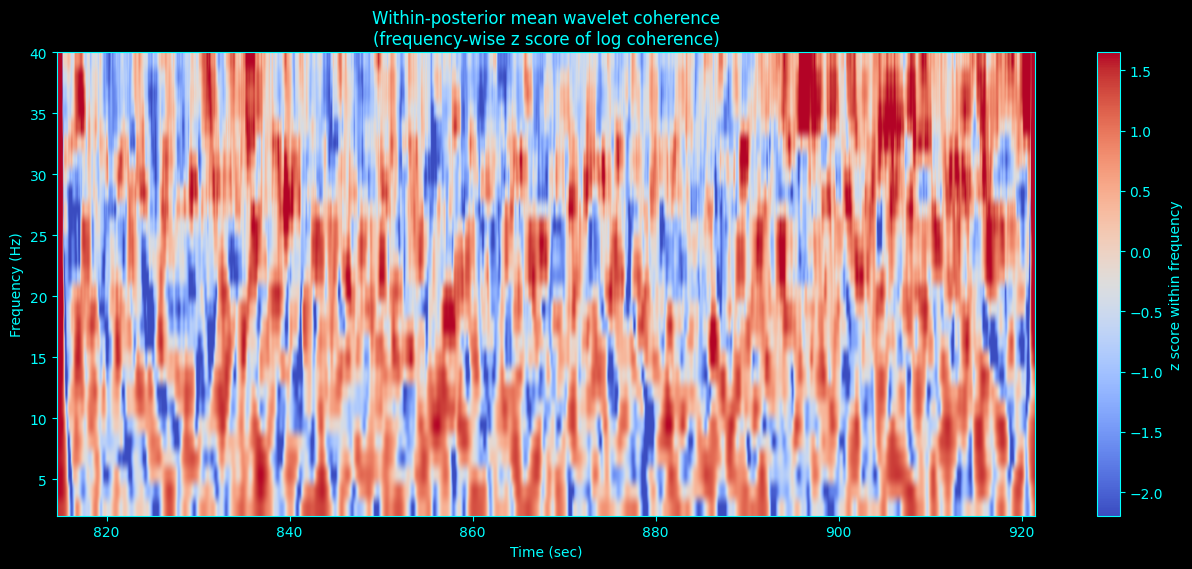

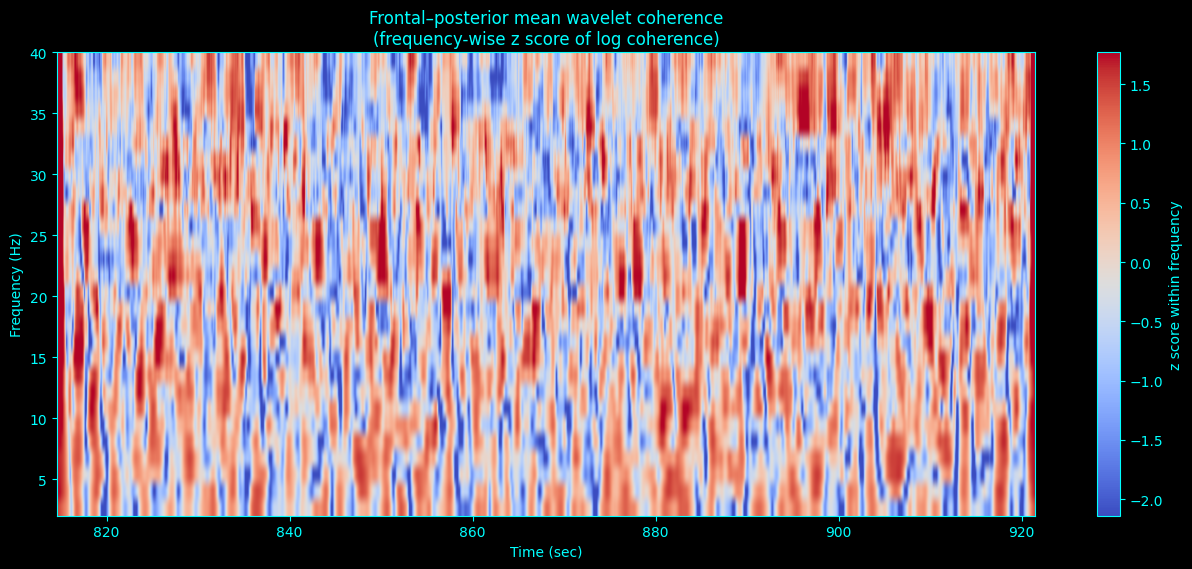

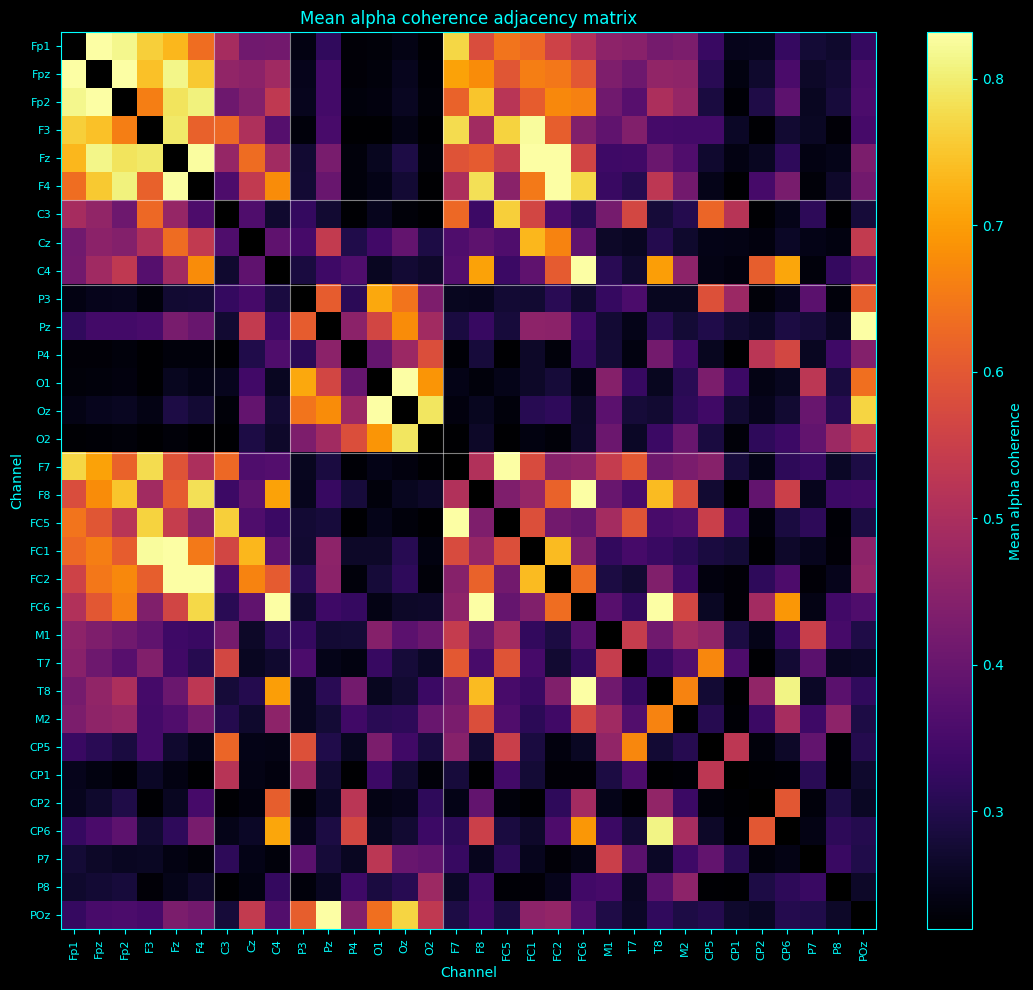

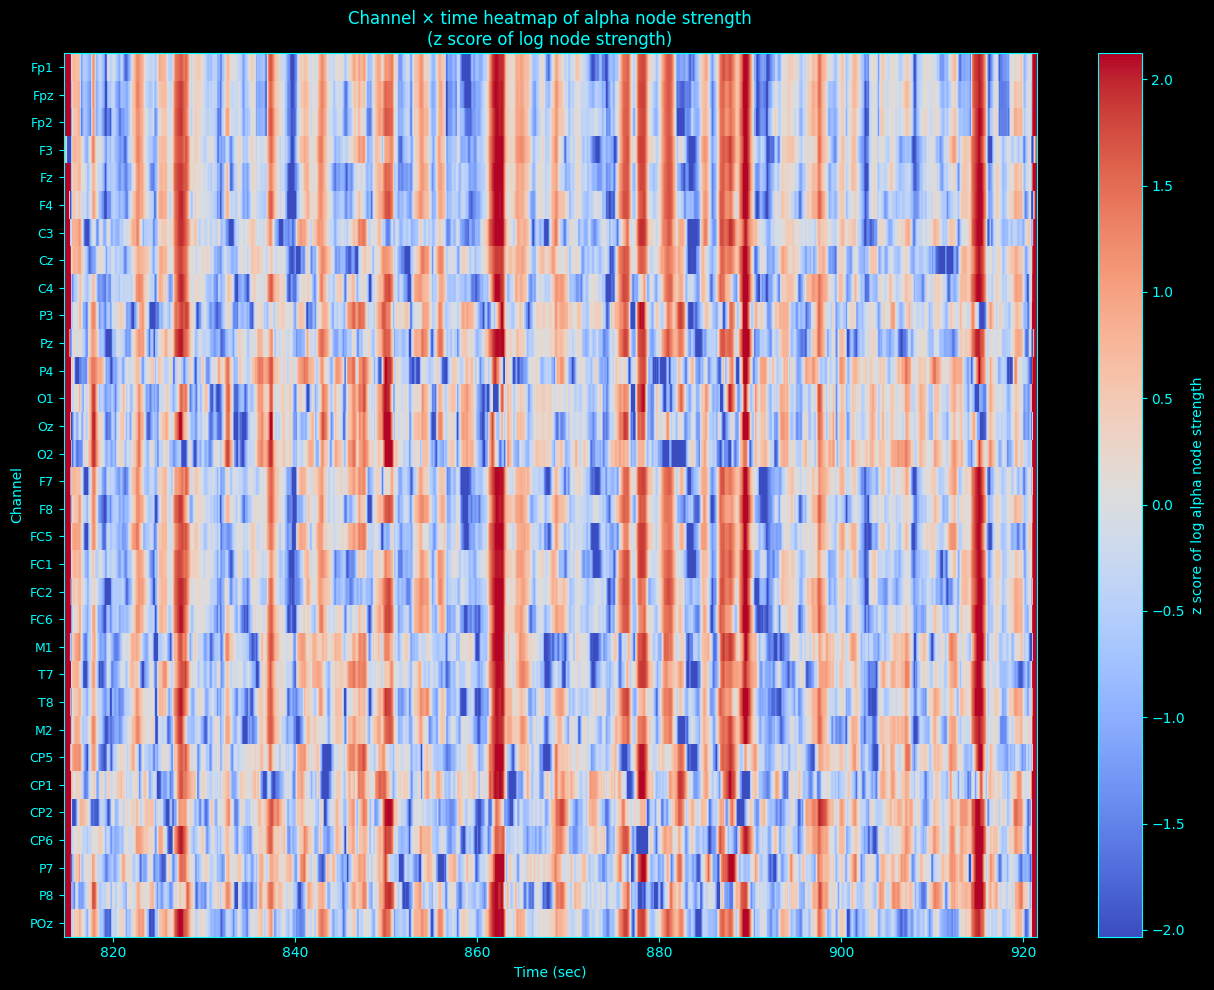

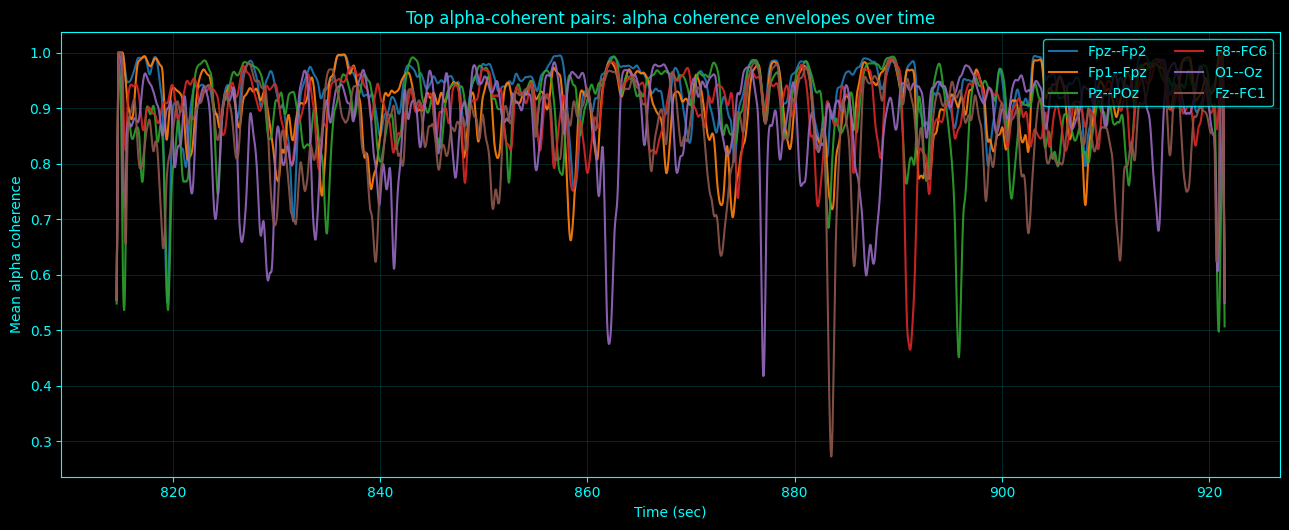

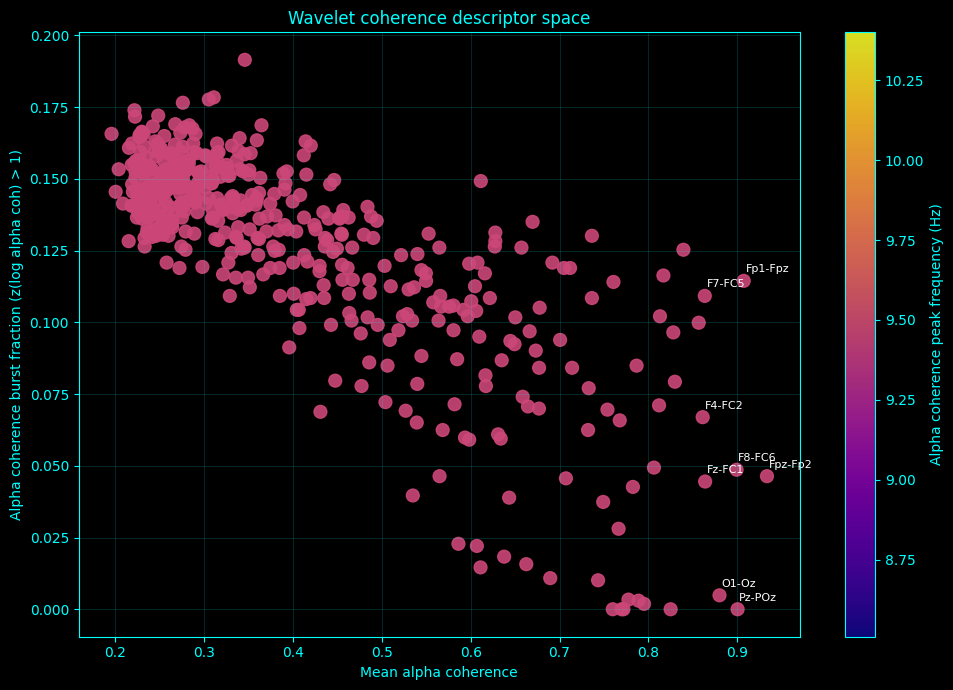

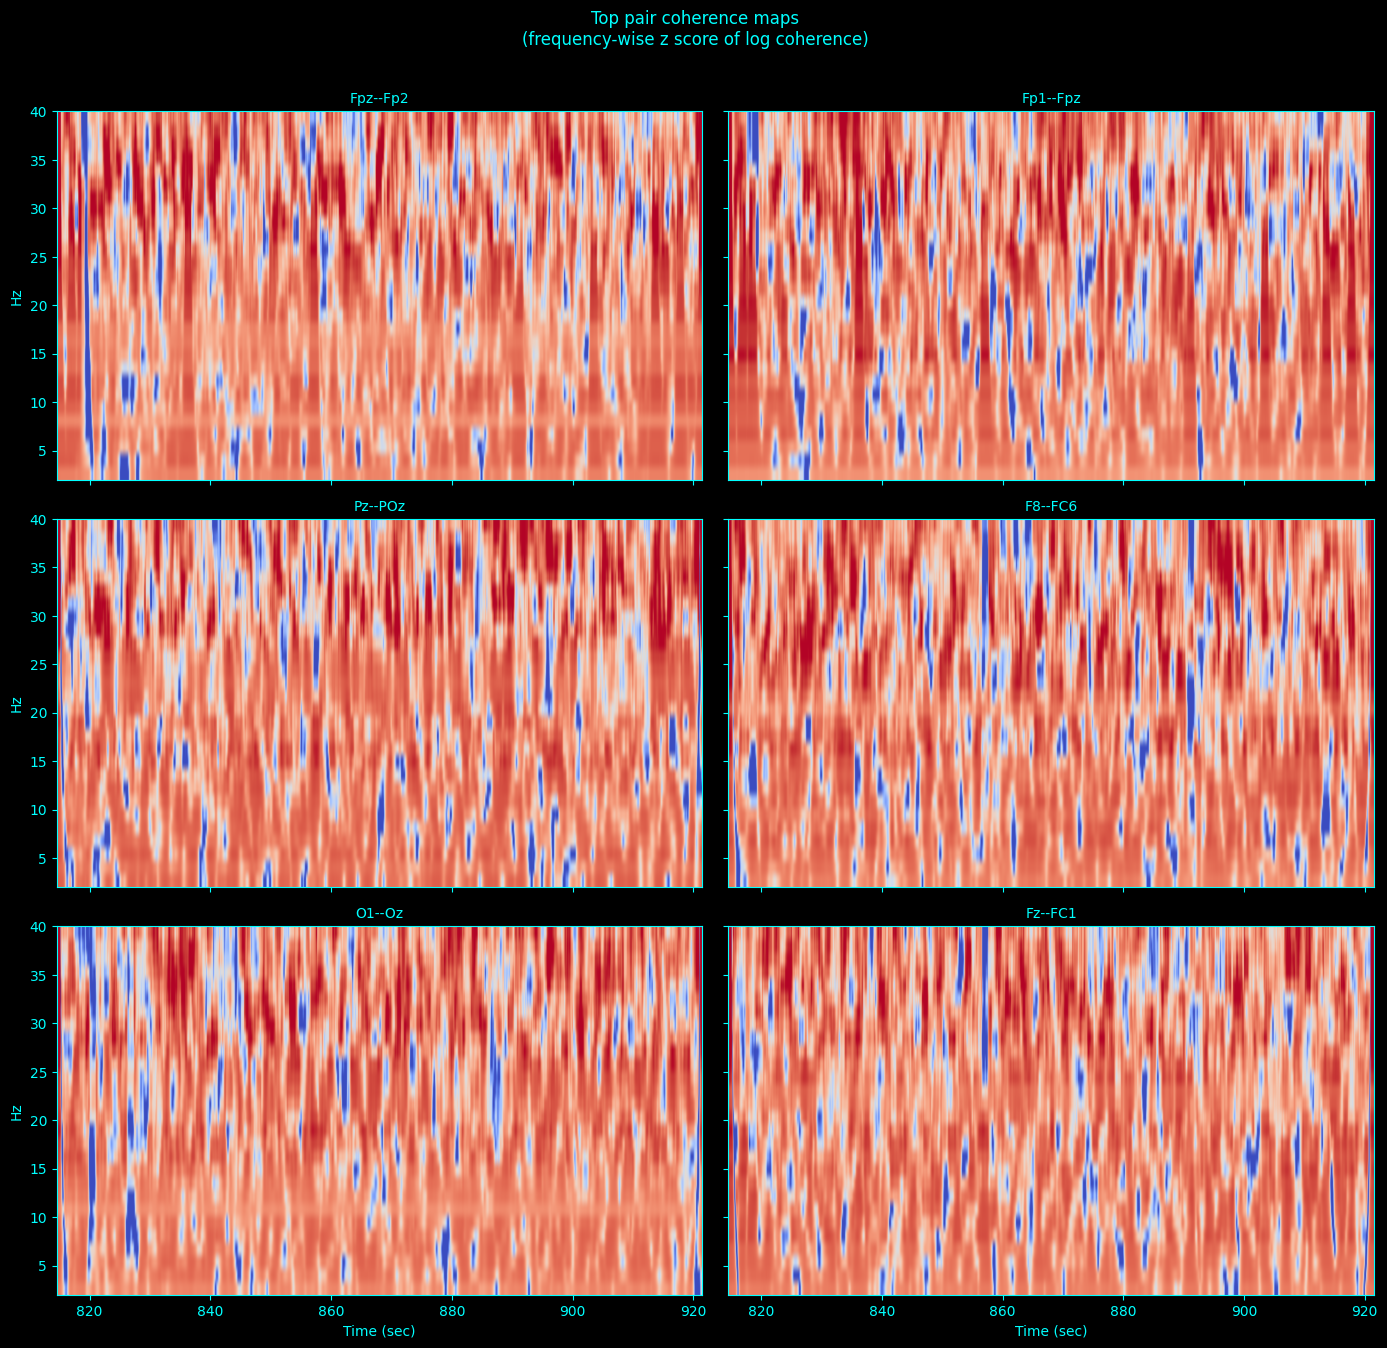


Saved pair summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coherence/wavelet_coherence_pair_summary.csv
Saved channel summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coherence/wavelet_coherence_channel_summary.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coherence/exploratory_wavelet_coherence_outputs.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coherence/exploratory_wavelet_coherence_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coherence/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, ndimage

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_wavelet_coherence")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# WHY THIS VERSION IS DIFFERENT
# -------------------------------------------------------
# The original block computes:
#   |conj(Wx) * Wy|^2 / (|Wx|^2 * |Wy|^2)
# directly from unsmoothed wavelet coefficients.
#
# That is NOT useful wavelet coherence in practice because without smoothing
# it tends to collapse toward a trivial pointwise ratio and exaggerates certainty.
#
# This version computes exploratory Morlet wavelet coherence as:
#   | S(Wxy) |^2 / ( S(|Wx|^2) * S(|Wy|^2) )
# where S(.) is separable smoothing across time and frequency.
#
# This is still exploratory research code, not a publication pipeline.
# The aim is to inspect dynamic coupling structure, intermittency,
# regional backbones, and pair-level coherence motifs.

# -------------------------------------------------------
# COHERENCE PASS DESIGN
# -------------------------------------------------------
# Downsample only for this pass. Keep enough Nyquist margin for 2–40 Hz coherence.
coh_downsample_factor = 10
fs_coh = sampling_rate / coh_downsample_factor  # 100 Hz

# Frequency design
fmin, fmax = 2.0, 40.0
n_wavelet_freqs = 28
target_freqs_hz = np.geomspace(fmin, fmax, n_wavelet_freqs)

# Morlet design
morlet_n_cycles = 7.0
morlet_support_sigma = 4.0  # support = +/- support_sigma * sigma_t

# Smoothing for coherence
# Expert point: coherence requires smoothing. Without it, the ratio is misleading.
coh_time_smooth_sec = 1.0
coh_freq_smooth_bins = 3

# Decimate the time axis AFTER smoothing for summaries / plots / storage
coh_time_decim = 4

# Preprocessing
apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

# Band summaries
band_specs = {
    "delta": [(2.0, 4.0)],
    "theta": [(4.0, 8.0)],
    "alpha": [(8.0, 13.0)],
    "beta":  [(13.0, 30.0)],
    "low_gamma": [(30.0, 40.0)],
}
display_band = (2.0, 40.0)
alpha_search_band = (7.0, 13.0)

# Top pair maps to retain and plot
top_n_pair_maps = 6

# Channels
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def band_mask(freqs_hz, lo, hi):
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def composite_band_mask(freqs_hz, band_list):
    mask = np.zeros_like(freqs_hz, dtype=bool)
    for lo, hi in band_list:
        mask |= band_mask(freqs_hz, lo, hi)
    return mask

def mean_composite_band(freqs_hz, values, band_list, axis=0):
    """
    For coherence, mean across frequency bins is usually more interpretable than integration,
    because coherence is already bounded on [0, 1].
    values can be 1D or 2D with freq axis first.
    """
    mask = composite_band_mask(freqs_hz, band_list)
    if np.sum(mask) < 1:
        if values.ndim == 1:
            return np.nan
        return np.full(values.shape[1], np.nan, dtype=float)
    return np.nanmean(values[mask], axis=axis)

def spectral_entropy_1d(freqs_hz, spectrum_1d, band=(2.0, 40.0)):
    mask = band_mask(freqs_hz, band[0], band[1]) & np.isfinite(spectrum_1d)
    p = np.asarray(spectrum_1d[mask], dtype=float)
    p = np.maximum(p, 0.0)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    p = p / s
    h = -np.sum(p * np.log(p + eps))
    hmax = np.log(len(p) + eps)
    return float(h / (hmax + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band[0], band[1]) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]

    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def morlet_wavelet(f_hz, fs, n_cycles=7.0, support_sigma=4.0):
    """
    Complex Morlet wavelet with unit-energy normalization.
    """
    sigma_t = n_cycles / (2.0 * np.pi * f_hz)
    half_width_sec = support_sigma * sigma_t
    t = np.arange(-half_width_sec, half_width_sec + 1.0 / fs, 1.0 / fs)

    wavelet = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t ** 2) / (2.0 * sigma_t ** 2))
    wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2) + eps)
    return wavelet.astype(np.complex64)

def compute_morlet_coeffs(y, fs, target_freqs_hz, n_cycles=7.0, support_sigma=4.0):
    """
    SciPy-only Morlet coefficients for one channel.
    Returns complex coefficient matrix of shape (n_freqs, n_times).
    """
    y = np.asarray(y, dtype=np.float32)
    coeff_rows = []

    for f_hz in target_freqs_hz:
        w = morlet_wavelet(f_hz, fs, n_cycles=n_cycles, support_sigma=support_sigma)
        coeff = signal.fftconvolve(y, np.conjugate(w[::-1]), mode="same")
        coeff_rows.append(coeff.astype(np.complex64))

    return np.vstack(coeff_rows)

def smooth_real_2d(x, freq_bins=3, time_bins=11):
    y = ndimage.uniform_filter1d(np.asarray(x, dtype=np.float32), size=max(int(time_bins), 1), axis=1, mode="nearest")
    y = ndimage.uniform_filter1d(y, size=max(int(freq_bins), 1), axis=0, mode="nearest")
    return y.astype(np.float32)

def smooth_complex_2d(x, freq_bins=3, time_bins=11):
    xr = smooth_real_2d(np.real(x), freq_bins=freq_bins, time_bins=time_bins)
    xi = smooth_real_2d(np.imag(x), freq_bins=freq_bins, time_bins=time_bins)
    return (xr + 1j * xi).astype(np.complex64)

def frequencywise_zlog_map(x):
    logx = np.log10(np.maximum(x, eps))
    return (logx - np.nanmean(logx, axis=1, keepdims=True)) / (np.nanstd(logx, axis=1, keepdims=True) + eps)

def channel_region_map(channel_names, roi_defs):
    mapping = {}
    frontal = set(roi_defs["frontal"])
    central = set(roi_defs["central"])
    posterior = set(roi_defs["posterior"])
    for ch in channel_names:
        if ch in frontal:
            mapping[ch] = "frontal"
        elif ch in central:
            mapping[ch] = "central"
        elif ch in posterior:
            mapping[ch] = "posterior"
        else:
            mapping[ch] = "other"
    return mapping

def pair_region_relation(ch1, ch2, region_map):
    r1 = region_map[ch1]
    r2 = region_map[ch2]
    if r1 == r2:
        return f"within_{r1}"
    pair_set = frozenset([r1, r2])
    if pair_set == frozenset(["frontal", "posterior"]):
        return "frontal_posterior"
    if pair_set == frozenset(["frontal", "central"]):
        return "frontal_central"
    if pair_set == frozenset(["central", "posterior"]):
        return "central_posterior"
    return "mixed_other"

def coherence_for_pair(i, j, coeffs_cube, auto_smooth_cube, freq_bins, time_bins, time_keep_idx):
    cross = coeffs_cube[:, :, i] * np.conjugate(coeffs_cube[:, :, j])
    cross_smooth = smooth_complex_2d(cross, freq_bins=freq_bins, time_bins=time_bins)
    coh = np.abs(cross_smooth) ** 2 / (auto_smooth_cube[:, :, i] * auto_smooth_cube[:, :, j] + eps)
    coh = np.clip(coh, 0.0, 1.0).astype(np.float32)
    coh_ds = coh[:, time_keep_idx]
    return coh_ds

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=coh_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=np.float32)

time_sec_rel_full = np.arange(segment_ds.shape[0], dtype=float) / fs_coh
time_smooth_bins = max(int(round(coh_time_smooth_sec * fs_coh)), 1)
time_keep_idx = np.arange(0, segment_ds.shape[0], coh_time_decim, dtype=int)
time_sec_rel = time_sec_rel_full[time_keep_idx]
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled coherence segment shape: {segment_ds.shape}")
print(f"Coherence sampling rate: {fs_coh:.1f} Hz")
print(f"Wavelet frequencies: {target_freqs_hz[0]:.2f}–{target_freqs_hz[-1]:.2f} Hz ({len(target_freqs_hz)} bins)")
print(f"Coherence smoothing: {coh_time_smooth_sec:.2f} sec x {coh_freq_smooth_bins} freq bins")
print(f"Output time decimation: every {coh_time_decim} samples -> {len(time_sec_abs)} time bins")

# -------------------------------------------------------
# PRECOMPUTE COEFFICIENTS AND AUTO-SPECTRA
# -------------------------------------------------------
n_freqs = len(target_freqs_hz)
n_times_full = segment_ds.shape[0]
n_channels = len(eeg_channel_names)

coeffs_cube = np.full((n_freqs, n_times_full, n_channels), np.nan + 1j * np.nan, dtype=np.complex64)
auto_smooth_cube = np.full((n_freqs, n_times_full, n_channels), np.nan, dtype=np.float32)

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    coeffs = compute_morlet_coeffs(
        y,
        fs_coh,
        target_freqs_hz,
        n_cycles=morlet_n_cycles,
        support_sigma=morlet_support_sigma,
    )
    auto_power = np.abs(coeffs) ** 2

    coeffs_cube[:, :, ch_i] = coeffs
    auto_smooth_cube[:, :, ch_i] = smooth_real_2d(
        auto_power,
        freq_bins=coh_freq_smooth_bins,
        time_bins=time_smooth_bins,
    )

print("Computed Morlet coefficients and smoothed auto-spectra.")

# -------------------------------------------------------
# PAIRWISE COHERENCE SUMMARIES
# -------------------------------------------------------
region_map = channel_region_map(eeg_channel_names, roi_definitions)
pair_rows = []

alpha_adj = np.full((n_channels, n_channels), np.nan, dtype=np.float32)
global_adj = np.full((n_channels, n_channels), np.nan, dtype=np.float32)

alpha_node_accum = np.zeros((len(time_sec_abs), n_channels), dtype=np.float32)
alpha_node_count = np.zeros((len(time_sec_abs), n_channels), dtype=np.float32)

roi_map_accum = {
    "global": np.zeros((n_freqs, len(time_sec_abs)), dtype=np.float32),
    "within_posterior": np.zeros((n_freqs, len(time_sec_abs)), dtype=np.float32),
    "within_frontal": np.zeros((n_freqs, len(time_sec_abs)), dtype=np.float32),
    "within_central": np.zeros((n_freqs, len(time_sec_abs)), dtype=np.float32),
    "frontal_posterior": np.zeros((n_freqs, len(time_sec_abs)), dtype=np.float32),
}
roi_map_count = {k: 0 for k in roi_map_accum.keys()}

pair_index = 0
n_pairs = n_channels * (n_channels - 1) // 2

for i in range(n_channels):
    for j in range(i + 1, n_channels):
        pair_index += 1
        if pair_index % 50 == 0 or pair_index == n_pairs:
            print(f"Pair {pair_index}/{n_pairs}")

        ch_i = eeg_channel_names[i]
        ch_j = eeg_channel_names[j]

        coh_ds = coherence_for_pair(
            i,
            j,
            coeffs_cube,
            auto_smooth_cube,
            freq_bins=coh_freq_smooth_bins,
            time_bins=time_smooth_bins,
            time_keep_idx=time_keep_idx,
        )

        mean_coh_spectrum = np.nanmean(coh_ds, axis=1)

        alpha_env = mean_composite_band(target_freqs_hz, coh_ds, band_specs["alpha"], axis=0)
        beta_env = mean_composite_band(target_freqs_hz, coh_ds, band_specs["beta"], axis=0)
        theta_env = mean_composite_band(target_freqs_hz, coh_ds, band_specs["theta"], axis=0)
        global_env = mean_composite_band(target_freqs_hz, coh_ds, [(display_band[0], display_band[1])], axis=0)

        alpha_mean = float(np.nanmean(alpha_env))
        beta_mean = float(np.nanmean(beta_env))
        theta_mean = float(np.nanmean(theta_env))
        global_mean = float(np.nanmean(coh_ds))

        alpha_z = zscore_1d(np.log10(alpha_env + eps))
        alpha_burst_fraction = float(np.nanmean(alpha_z > 1.0))
        alpha_cv = float(np.nanstd(alpha_env) / (np.nanmean(alpha_env) + eps))
        alpha_range = float(np.nanmax(alpha_env) - np.nanmin(alpha_env))

        alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
            target_freqs_hz,
            mean_coh_spectrum,
            band=alpha_search_band,
            smooth_win=5,
        )

        pair_entropy = spectral_entropy_1d(target_freqs_hz, mean_coh_spectrum, band=display_band)
        relation = pair_region_relation(ch_i, ch_j, region_map)

        pair_rows.append({
            "pair": f"{ch_i}--{ch_j}",
            "channel_1": ch_i,
            "channel_2": ch_j,
            "region_1": region_map[ch_i],
            "region_2": region_map[ch_j],
            "relation": relation,
            "global_mean_coherence_2_40Hz": global_mean,
            "delta_mean_coherence": float(np.nanmean(mean_composite_band(target_freqs_hz, coh_ds, band_specs["delta"], axis=0))),
            "theta_mean_coherence": theta_mean,
            "alpha_mean_coherence": alpha_mean,
            "beta_mean_coherence": beta_mean,
            "low_gamma_mean_coherence": float(np.nanmean(mean_composite_band(target_freqs_hz, coh_ds, band_specs["low_gamma"], axis=0))),
            "alpha_coherence_std": float(np.nanstd(alpha_env)),
            "alpha_coherence_cv": alpha_cv,
            "alpha_coherence_range": alpha_range,
            "alpha_burst_fraction_z_gt_1": alpha_burst_fraction,
            "alpha_beta_selectivity": alpha_mean / (beta_mean + eps),
            "alpha_theta_selectivity": alpha_mean / (theta_mean + eps),
            "alpha_peak_frequency_Hz": alpha_peak_hz,
            "alpha_peak_height": alpha_peak_height,
            "alpha_peak_prominence": alpha_peak_prominence,
            "alpha_peak_contrast": alpha_peak_contrast,
            "coherence_spectral_entropy_2_40Hz": pair_entropy,
        })

        alpha_adj[i, j] = alpha_adj[j, i] = alpha_mean
        global_adj[i, j] = global_adj[j, i] = global_mean

        alpha_node_accum[:, i] += alpha_env
        alpha_node_accum[:, j] += alpha_env
        alpha_node_count[:, i] += 1.0
        alpha_node_count[:, j] += 1.0

        roi_map_accum["global"] += coh_ds
        roi_map_count["global"] += 1

        if relation in roi_map_accum:
            roi_map_accum[relation] += coh_ds
            roi_map_count[relation] += 1

pair_df = pd.DataFrame(pair_rows)
for col in pair_df.columns:
    if col not in ["pair", "channel_1", "channel_2", "region_1", "region_2", "relation"]:
        pair_df[col] = pd.to_numeric(pair_df[col], errors="coerce")

alpha_node_strength = alpha_node_accum / (alpha_node_count + eps)
alpha_node_strength_z = np.full_like(alpha_node_strength, np.nan, dtype=np.float32)
for ch_i in range(n_channels):
    alpha_node_strength_z[:, ch_i] = zscore_1d(np.log10(alpha_node_strength[:, ch_i] + eps))

alpha_upper = alpha_adj[np.triu_indices(n_channels, k=1)]
alpha_threshold = float(np.nanpercentile(alpha_upper[np.isfinite(alpha_upper)], 75))

channel_rows = []
for ch_i, ch_name in enumerate(eeg_channel_names):
    connected = alpha_adj[ch_i, :]
    degree = int(np.nansum(connected >= alpha_threshold))
    channel_rows.append({
        "channel": ch_name,
        "region": region_map[ch_name],
        "alpha_node_strength_mean": float(np.nanmean(alpha_node_strength[:, ch_i])),
        "alpha_node_strength_std": float(np.nanstd(alpha_node_strength[:, ch_i])),
        "alpha_node_strength_cv": float(np.nanstd(alpha_node_strength[:, ch_i]) / (np.nanmean(alpha_node_strength[:, ch_i]) + eps)),
        "alpha_node_burst_fraction_z_gt_1": float(np.nanmean(alpha_node_strength_z[:, ch_i] > 1.0)),
        "alpha_static_degree_above_75pct": degree,
        "alpha_mean_pairwise_coherence": float(np.nanmean(alpha_adj[ch_i, :])),
        "global_mean_pairwise_coherence": float(np.nanmean(global_adj[ch_i, :])),
    })

channel_df = pd.DataFrame(channel_rows)
for col in channel_df.columns:
    if col not in ["channel", "region"]:
        channel_df[col] = pd.to_numeric(channel_df[col], errors="coerce")

roi_maps_mean = {}
for key, acc in roi_map_accum.items():
    if roi_map_count[key] > 0:
        roi_maps_mean[key] = acc / roi_map_count[key]
    else:
        roi_maps_mean[key] = np.full_like(acc, np.nan)

# -------------------------------------------------------
# RECOMPUTE ONLY TOP PAIRS FOR SAVED MAPS
# -------------------------------------------------------
top_pairs_df = pair_df.sort_values("alpha_mean_coherence", ascending=False, na_position="last").head(top_n_pair_maps).reset_index(drop=True)
top_pair_names = list(top_pairs_df["pair"].values)
top_pair_stack = np.full((n_freqs, len(time_sec_abs), len(top_pair_names)), np.nan, dtype=np.float32)
top_pair_stack_zfreq = np.full_like(top_pair_stack, np.nan, dtype=np.float32)

for k, row in top_pairs_df.iterrows():
    i = eeg_channel_names.index(row["channel_1"])
    j = eeg_channel_names.index(row["channel_2"])
    coh_ds = coherence_for_pair(
        i,
        j,
        coeffs_cube,
        auto_smooth_cube,
        freq_bins=coh_freq_smooth_bins,
        time_bins=time_smooth_bins,
        time_keep_idx=time_keep_idx,
    )
    top_pair_stack[:, :, k] = coh_ds
    top_pair_stack_zfreq[:, :, k] = frequencywise_zlog_map(coh_ds).astype(np.float32)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
pair_csv_path = os.path.join(out_dir, "wavelet_coherence_pair_summary.csv")
channel_csv_path = os.path.join(out_dir, "wavelet_coherence_channel_summary.csv")
npz_path = os.path.join(out_dir, "exploratory_wavelet_coherence_outputs.npz")
notes_txt_path = os.path.join(out_dir, "exploratory_wavelet_coherence_notes.txt")

pair_df.to_csv(pair_csv_path, index=False)
channel_df.to_csv(channel_csv_path, index=False)

np.savez_compressed(
    npz_path,
    frequencies_hz=target_freqs_hz,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_sec_rel,
    alpha_adj=alpha_adj,
    global_adj=global_adj,
    alpha_node_strength=alpha_node_strength,
    alpha_node_strength_z=alpha_node_strength_z,
    roi_global_map=roi_maps_mean["global"],
    roi_within_posterior_map=roi_maps_mean["within_posterior"],
    roi_within_frontal_map=roi_maps_mean["within_frontal"],
    roi_within_central_map=roi_maps_mean["within_central"],
    roi_frontal_posterior_map=roi_maps_mean["frontal_posterior"],
    top_pair_stack=top_pair_stack,
    top_pair_stack_zfreq=top_pair_stack_zfreq,
    top_pair_names=np.array(top_pair_names, dtype=object),
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    coherence_sampling_rate=fs_coh,
    coherence_downsample_factor=coh_downsample_factor,
    coherence_time_smooth_sec=coh_time_smooth_sec,
    coherence_freq_smooth_bins=coh_freq_smooth_bins,
    coherence_time_decim=coh_time_decim,
    morlet_n_cycles=morlet_n_cycles,
    morlet_support_sigma=morlet_support_sigma,
)

top_alpha_pairs = pair_df.sort_values("alpha_mean_coherence", ascending=False, na_position="last").head(8)
top_bursty_pairs = pair_df.sort_values("alpha_burst_fraction_z_gt_1", ascending=False, na_position="last").head(8)
top_channels = channel_df.sort_values("alpha_node_strength_mean", ascending=False, na_position="last").head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory wavelet coherence notes\n")
    f.write("===================================\n\n")
    f.write("Intent:\n")
    f.write("This is a hypothesis-generating map of dynamic cross-channel coupling in the selected EEG segment,\n")
    f.write("not a publication-ready connectivity pipeline, not a benchmark, and not a scoring system.\n\n")
    f.write("Key methodological upgrades relative to the original block:\n")
    f.write("1. The original coefficient-wise ratio behaves like a pseudo-coherence because it lacks smoothing.\n")
    f.write("2. This version computes smoothed Morlet wavelet coherence, which is the correct exploratory direction.\n")
    f.write("3. The analysis is restricted to the selected recording interval.\n")
    f.write("4. The pass is downsampled only for coherence so the dynamic maps remain tractable.\n")
    f.write("5. Pairwise summaries, regional backbone maps, and channel-wise node strength are emphasized instead of dumping 1024 raw pair plots.\n")
    f.write("6. Novel exploratory descriptors are added: coherence intermittency, alpha selectivity, dynamic node strength, and backbone persistence.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Coherence fs: {fs_coh:.1f} Hz\n")
    f.write(f"Downsample factor: {coh_downsample_factor}\n")
    f.write(f"Frequency range analyzed: [{fmin:.1f}, {fmax:.1f}] Hz\n")
    f.write(f"Wavelet frequencies: {n_wavelet_freqs}\n")
    f.write(f"Morlet n_cycles: {morlet_n_cycles}\n")
    f.write(f"Coherence smoothing time: {coh_time_smooth_sec:.2f} sec\n")
    f.write(f"Coherence smoothing freq bins: {coh_freq_smooth_bins}\n")
    f.write(f"Output time decimation: {coh_time_decim}\n\n")

    f.write("Top alpha-coherent pairs:\n")
    for _, row in top_alpha_pairs.iterrows():
        f.write(
            f"  {row['pair']}: "
            f"alpha_mean={row['alpha_mean_coherence']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"alpha_selectivity={row['alpha_beta_selectivity']:.3f}, "
            f"relation={row['relation']}\n"
        )

    f.write("\nTop alpha-bursty pairs:\n")
    for _, row in top_bursty_pairs.iterrows():
        f.write(
            f"  {row['pair']}: "
            f"burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}, "
            f"alpha_mean={row['alpha_mean_coherence']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}\n"
        )

    f.write("\nTop alpha-node-strength channels:\n")
    for _, row in top_channels.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_node_strength_mean={row['alpha_node_strength_mean']:.4f}, "
            f"static_degree_above_75pct={row['alpha_static_degree_above_75pct']}, "
            f"region={row['region']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# Useful channel ordering for adjacency / node maps
region_order = (
    roi_definitions["frontal"]
    + roi_definitions["central"]
    + roi_definitions["posterior"]
    + [ch for ch in eeg_channel_names if ch not in set(roi_definitions["frontal"] + roi_definitions["central"] + roi_definitions["posterior"])]
)
region_idx = [eeg_channel_names.index(ch) for ch in region_order]

# 1) Within-posterior mean coherence map
posterior_map = roi_maps_mean["within_posterior"]
posterior_zfreq = frequencywise_zlog_map(posterior_map)
vmin, vmax = percentile_limits(posterior_zfreq, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax, heatmap=True)
mesh = ax.imshow(
    posterior_zfreq,
    extent=[time_sec_abs[0], time_sec_abs[-1], target_freqs_hz[0], target_freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Within-posterior mean wavelet coherence\n(frequency-wise z score of log coherence)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(display_band[0], display_band[1])

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("z score within frequency", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_within_posterior_mean_coherence_map.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Frontal–posterior mean coherence map
fp_map = roi_maps_mean["frontal_posterior"]
fp_zfreq = frequencywise_zlog_map(fp_map)
vmin, vmax = percentile_limits(fp_zfreq, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax, heatmap=True)
mesh = ax.imshow(
    fp_zfreq,
    extent=[time_sec_abs[0], time_sec_abs[-1], target_freqs_hz[0], target_freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Frontal–posterior mean wavelet coherence\n(frequency-wise z score of log coherence)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(display_band[0], display_band[1])

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("z score within frequency", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_frontal_posterior_mean_coherence_map.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Alpha coherence adjacency matrix
alpha_adj_sorted = alpha_adj[np.ix_(region_idx, region_idx)]
fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
style_ax(ax, heatmap=True)
vmin, vmax = percentile_limits(alpha_adj_sorted, lo=2, hi=98)

im = ax.imshow(
    alpha_adj_sorted,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax.set_title("Mean alpha coherence adjacency matrix")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(region_order)))
ax.set_xticklabels(region_order, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(region_order)))
ax.set_yticklabels(region_order, fontsize=8)

# Region separators
fr_end = len(roi_definitions["frontal"])
ce_end = fr_end + len(roi_definitions["central"])
po_end = ce_end + len(roi_definitions["posterior"])
for boundary in [fr_end - 0.5, ce_end - 0.5, po_end - 0.5]:
    ax.axhline(boundary, color="white", linewidth=0.8, alpha=0.5)
    ax.axvline(boundary, color="white", linewidth=0.8, alpha=0.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean alpha coherence", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_alpha_coherence_adjacency_matrix.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of alpha node strength
alpha_node_strength_sorted = alpha_node_strength_z[:, region_idx].T
vmin, vmax = percentile_limits(alpha_node_strength_sorted, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    alpha_node_strength_sorted,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(region_order), 0],
)
ax.set_title("Channel × time heatmap of alpha node strength\n(z score of log node strength)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(region_order)) + 0.5)
ax.set_yticklabels(region_order, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("z score of log alpha node strength", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_alpha_node_strength_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Top alpha pair envelopes over time
fig, ax = plt.subplots(figsize=(13, 5.4), facecolor=BG)
style_ax(ax)

for k, row in top_pairs_df.iterrows():
    alpha_env = mean_composite_band(target_freqs_hz, top_pair_stack[:, :, k], band_specs["alpha"], axis=0)
    alpha_env_s = smooth_1d(alpha_env, win=9)
    ax.plot(time_sec_abs, alpha_env_s, linewidth=1.5, alpha=0.92, label=row["pair"])

ax.set_title("Top alpha-coherent pairs: alpha coherence envelopes over time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Mean alpha coherence")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_top_alpha_pair_envelopes.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Pair descriptor space
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

scatter = ax.scatter(
    pair_df["alpha_mean_coherence"].values,
    pair_df["alpha_burst_fraction_z_gt_1"].values,
    c=pair_df["alpha_peak_frequency_Hz"].values,
    s=85,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = pair_df.sort_values("alpha_mean_coherence", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["alpha_mean_coherence"] + 0.002,
        row["alpha_burst_fraction_z_gt_1"] + 0.003,
        f"{row['channel_1']}-{row['channel_2']}",
        color="white",
        fontsize=8,
    )

ax.set_title("Wavelet coherence descriptor space")
ax.set_xlabel("Mean alpha coherence")
ax.set_ylabel("Alpha coherence burst fraction (z(log alpha coh) > 1)")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Alpha coherence peak frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_wavelet_coherence_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top pair coherence maps
n_show = min(top_n_pair_maps, len(top_pair_names))
n_cols = 2
n_rows = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), facecolor=BG, sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

grid_vmin, grid_vmax = percentile_limits(top_pair_stack_zfreq[:, :, :n_show], lo=2, hi=98)

for k in range(n_show):
    ax = axes[k]
    style_ax(ax, heatmap=True)
    ax.imshow(
        top_pair_stack_zfreq[:, :, k],
        extent=[time_sec_abs[0], time_sec_abs[-1], target_freqs_hz[0], target_freqs_hz[-1]],
        aspect="auto",
        origin="lower",
        cmap="coolwarm",
        vmin=grid_vmin,
        vmax=grid_vmax,
    )
    ax.set_title(top_pair_names[k], fontsize=10)
    ax.set_ylim(display_band[0], display_band[1])

for ax in axes[n_show:]:
    ax.axis("off")

for i, ax in enumerate(axes[:n_show]):
    if i % n_cols == 0:
        ax.set_ylabel("Hz")
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel("Time (sec)")

fig.suptitle("Top pair coherence maps\n(frequency-wise z score of log coherence)", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_pair_coherence_maps.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved pair summary CSV: {pair_csv_path}")
print(f"Saved channel summary CSV: {channel_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Spectral Centroids

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code aims to assess the spectral characteristics of EEG data by calculating the spectral centroid for each channel. The spectral centroid is a feature that is often used to describe a frequency spectrum and serves as a sort of 'center of mass' for the spectrum. Understanding this feature can give us insights into the characteristics of the EEG signal in different brain regions.</p>
         <p>The Fourier Transform allows us to convert our time-domain signal into its frequency domain representation. Mathematically, it is expressed as:</p>
        \[
        F(f) = \int_{-\infty}^{\infty} x(t) e^{-2\pi ift} dt
        \]
        <p>This transformation is implemented in the code using the <code>scipy.fft.fft</code> function, which provides us with \( F(f) \), the Fourier Transform of the signal.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
               <p>Once in the frequency domain, the spectral centroid \( C \) for a signal is calculated as:</p>
        \[
        C = \frac{\sum_{n=0}^{N-1} f(n) \times |X(f(n))|}{\sum_{n=0}^{N-1} |X(f(n))|}
        \]
        <p>Here, \( f(n) \) are the frequencies associated with the Fourier Transform values. These frequencies are generated by the function <code>scipy.fft.fftfreq</code> in the code. \( |X(f(n))| \) represents the magnitude of the Fourier Transform at those frequencies, calculated as the absolute value of the complex Fourier coefficients.</p>
        <p>The spectral centroid provides a weighted average of the frequency components, effectively giving us a single scalar that characterizes the distribution of energy across frequencies. In the code, this is stored in the <code>spectral_centroids</code> dictionary, with one entry per EEG channel.</p>
    </div>
</div>


Running expert spectral-centroid analysis
FAST_OPTION: ultra
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Loaded EEG data: 4227788 samples x 32 channels
Original segment shape: (106944, 32)
Analysis segment shape: (26736, 32)
Analysis sampling rate: 250.00 Hz
Segment of interest: 814.571 to 921.515 sec
Centroid band: 2.0–45.0 Hz
[01/32] Fp1 | centroid=7.15 Hz | spread=8.27 Hz | alpha=0.081 | entropy=0.716 | 0.07s
[02/32] Fpz | centroid=6.77 Hz | spread=7.48 Hz | alpha=0.096 | entropy=0.711 | 0.06s
[03/32] Fp2 | centroid=6.30 Hz | spread=7.08 Hz | alpha=0.083 | entropy=0.687 | 0.06s
[04/32]  F7 | centroid=15.09 Hz | spread=12.28 Hz | alpha=0.184 | entropy=0.927 | 0.07s
[05/32]  F3 | centroid=13.11 Hz | spread=11.26 Hz | alpha=0.195 | entropy=0.896 | 0.06s
[06/32]  Fz | centroid=10.01 Hz | spread=9.27 Hz | alpha=0.211 | entropy=0.829 | 0.06s
[07/32]  F4 | centroid=10.70 Hz | spread=9.55 Hz | alpha=0.232 | entropy=0.846 | 0.06s
[08/32]  F8 | centro

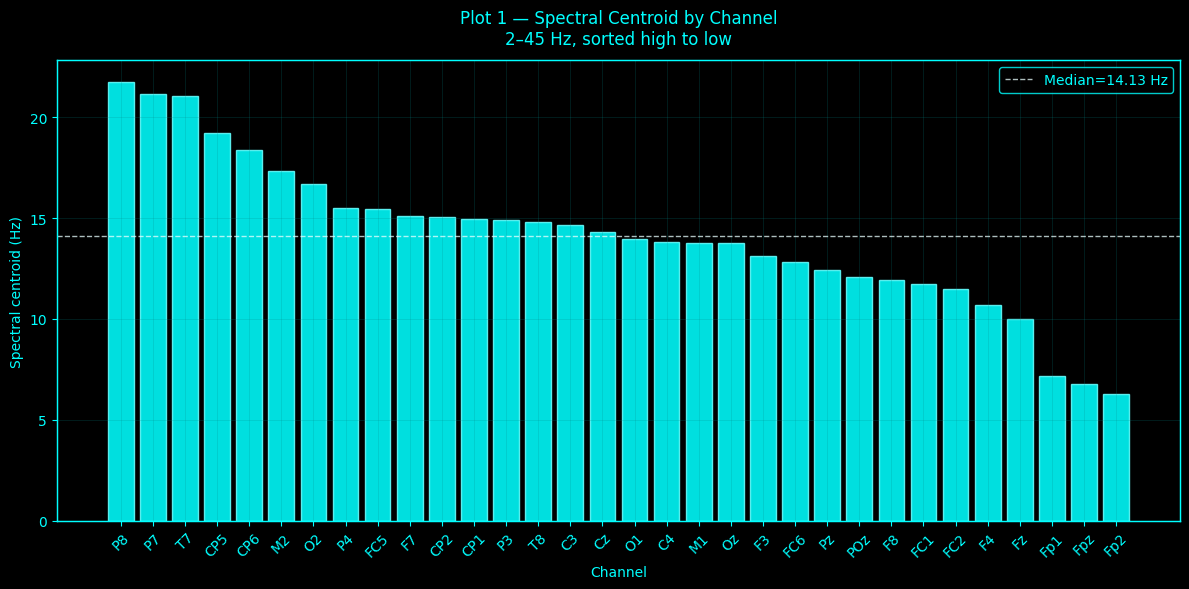

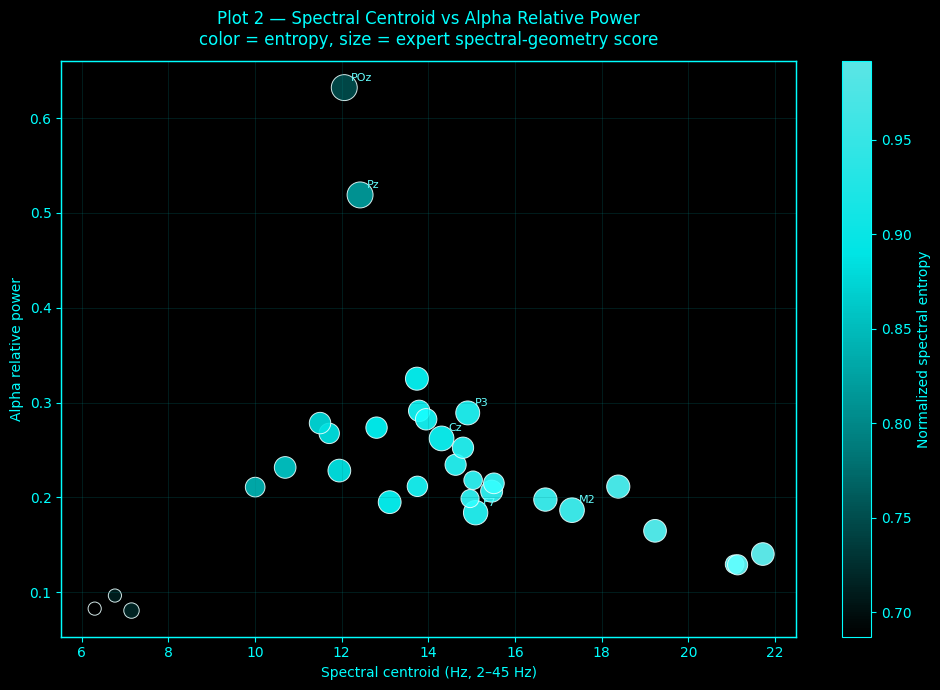

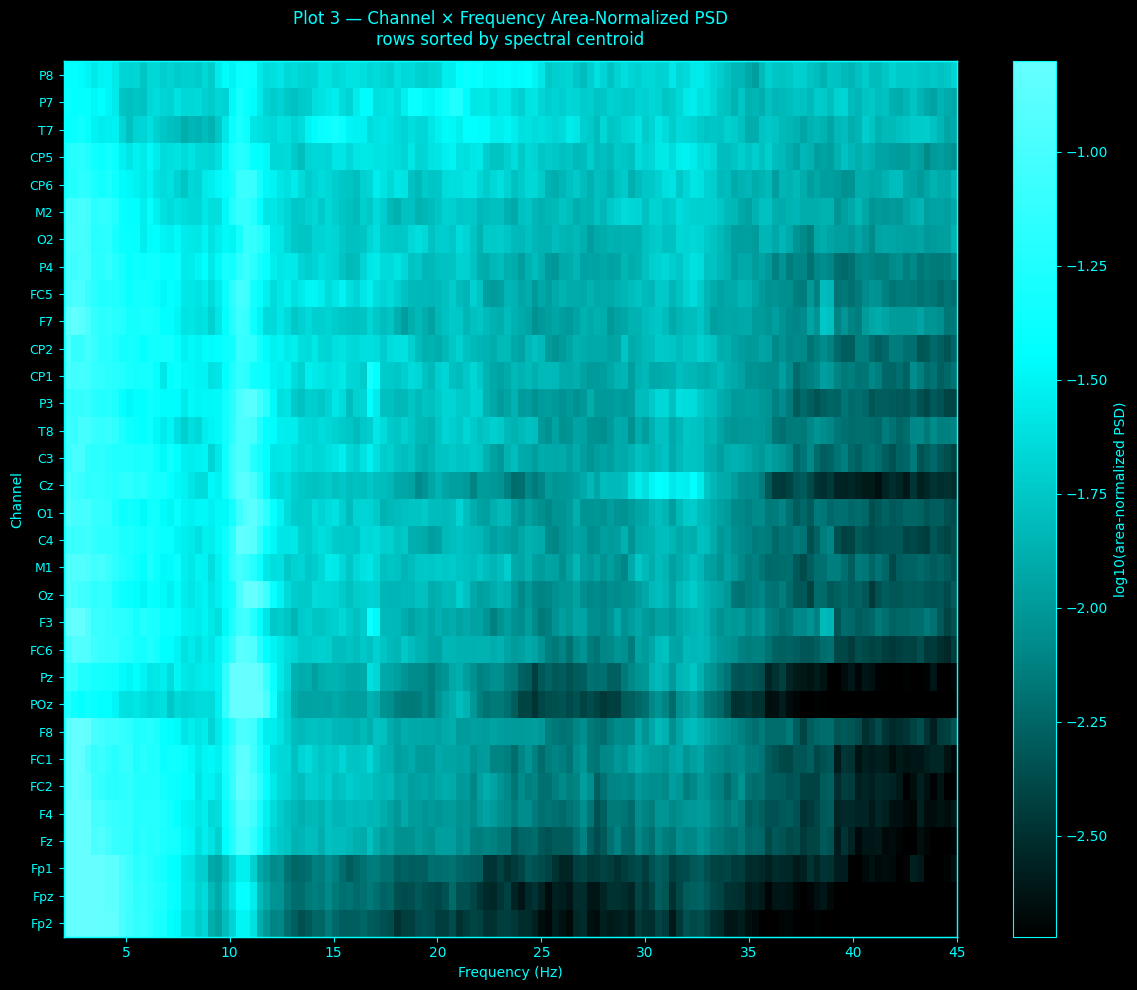

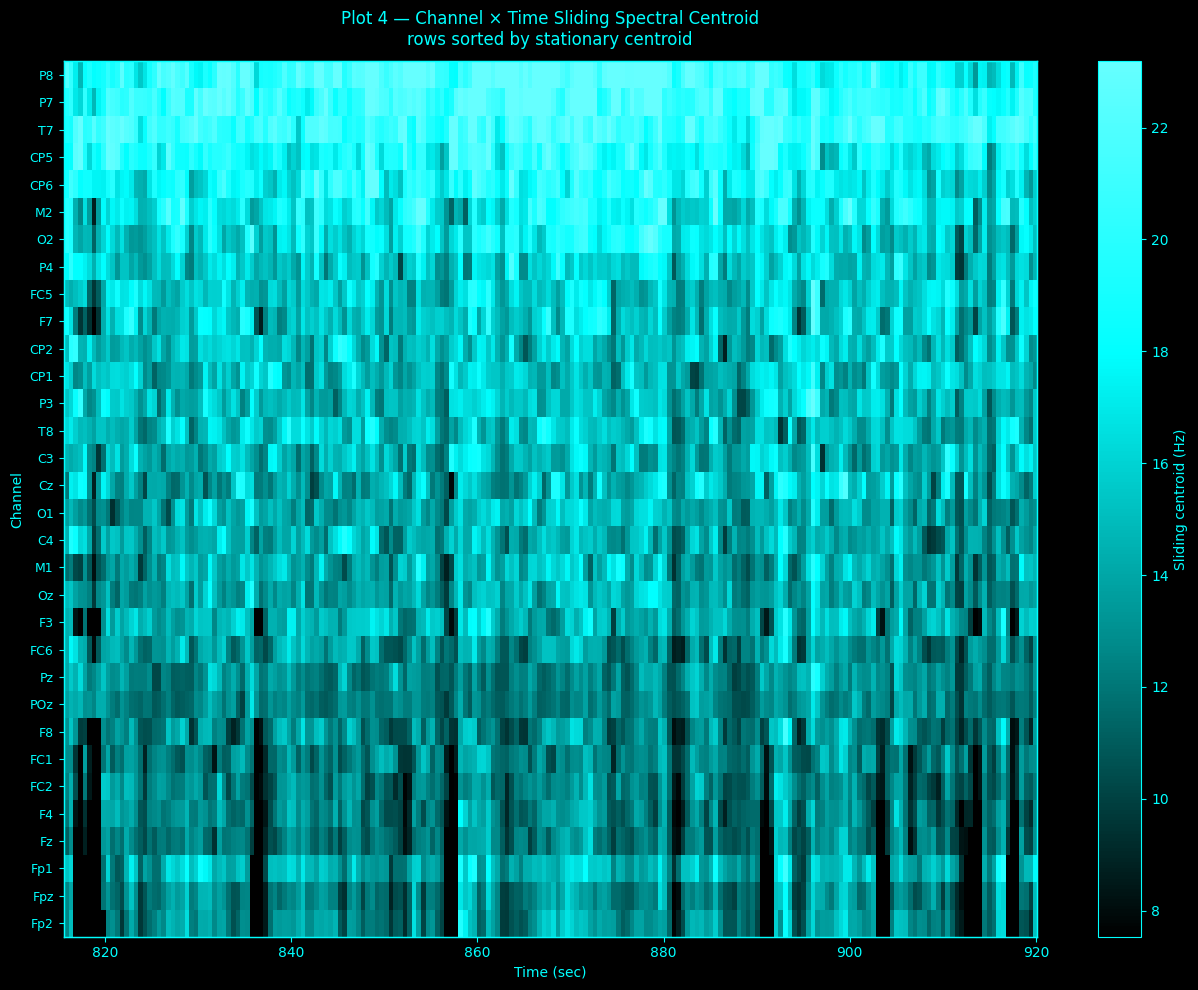

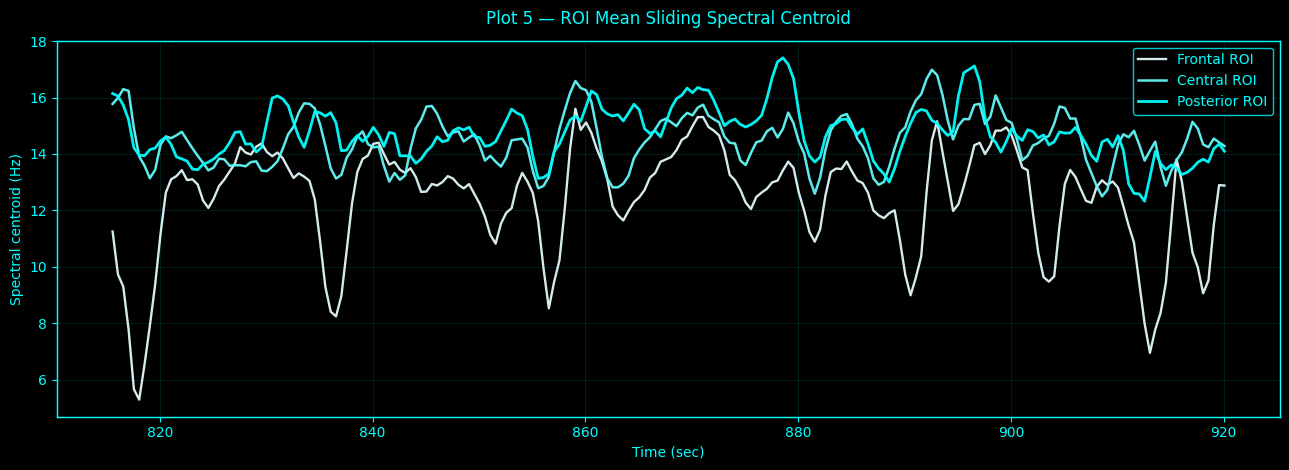

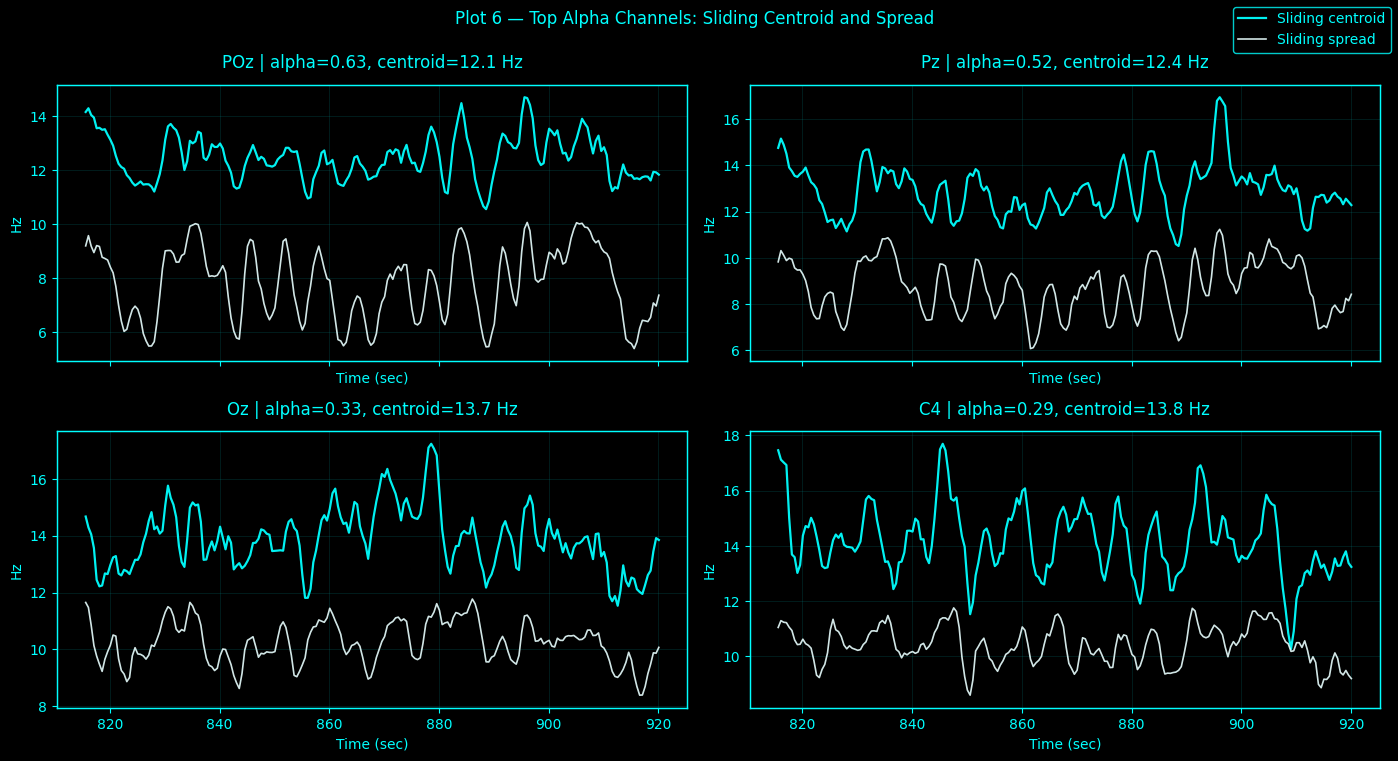

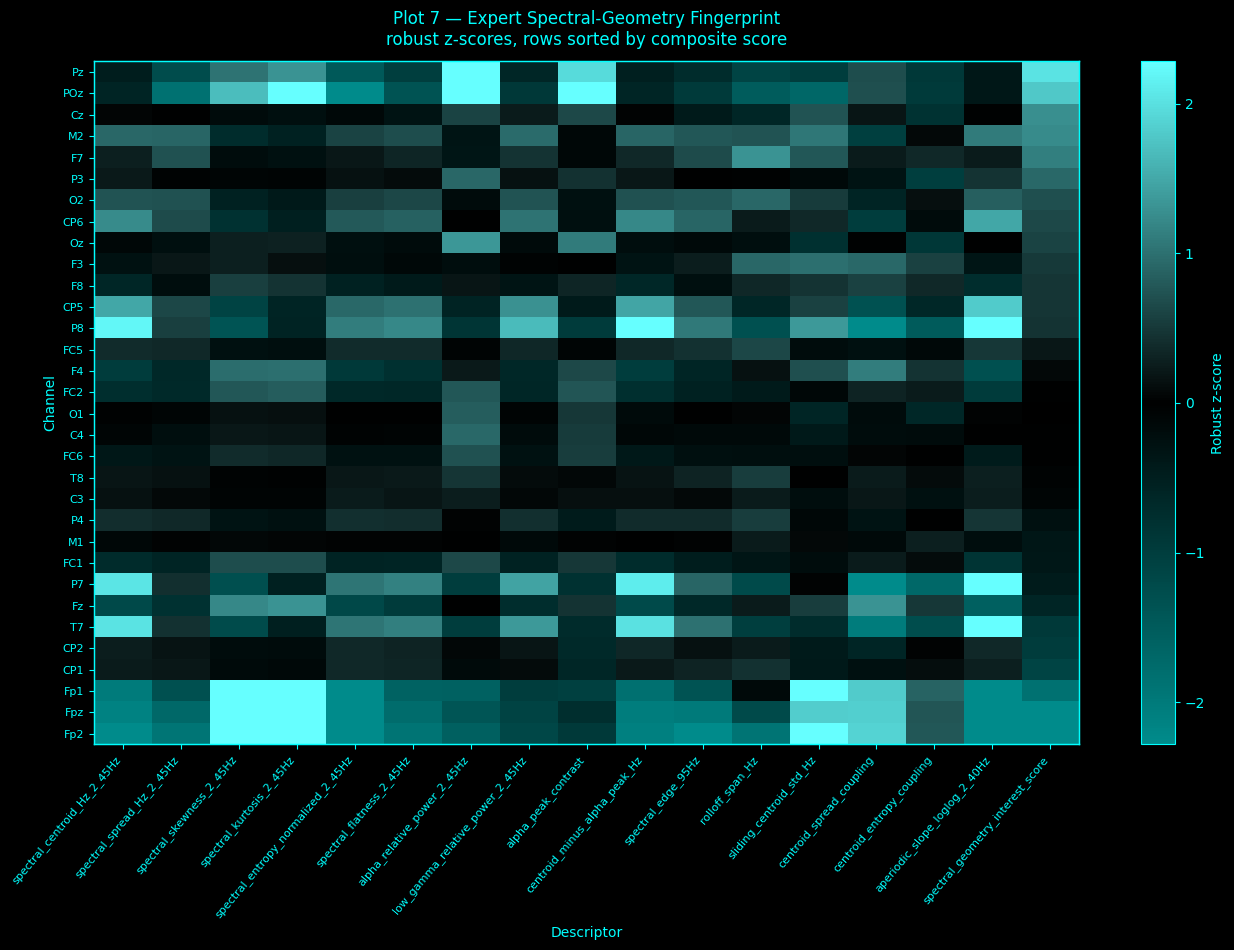

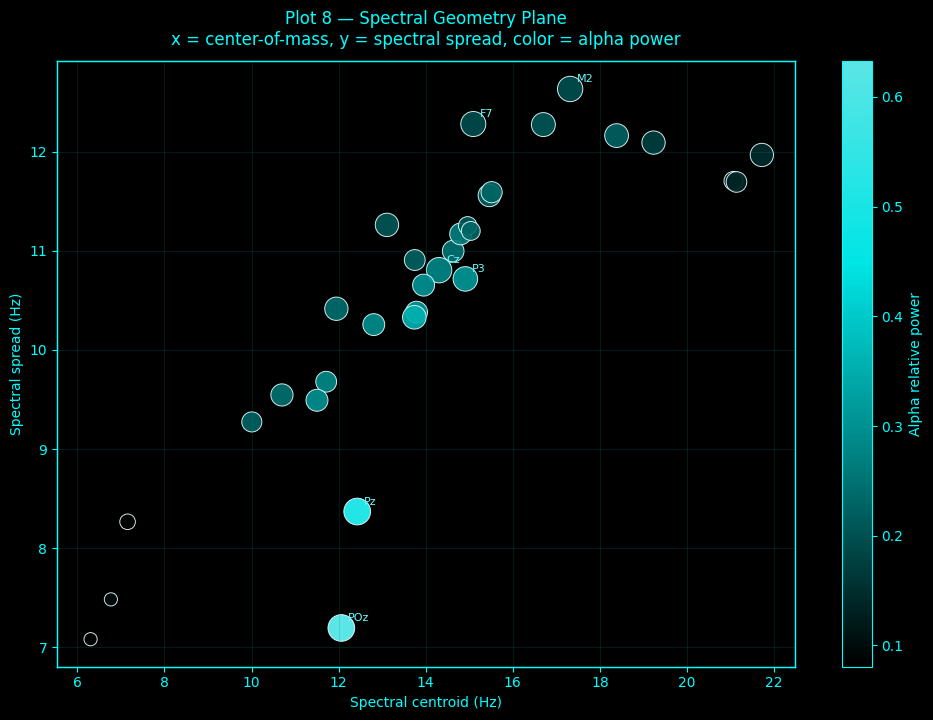

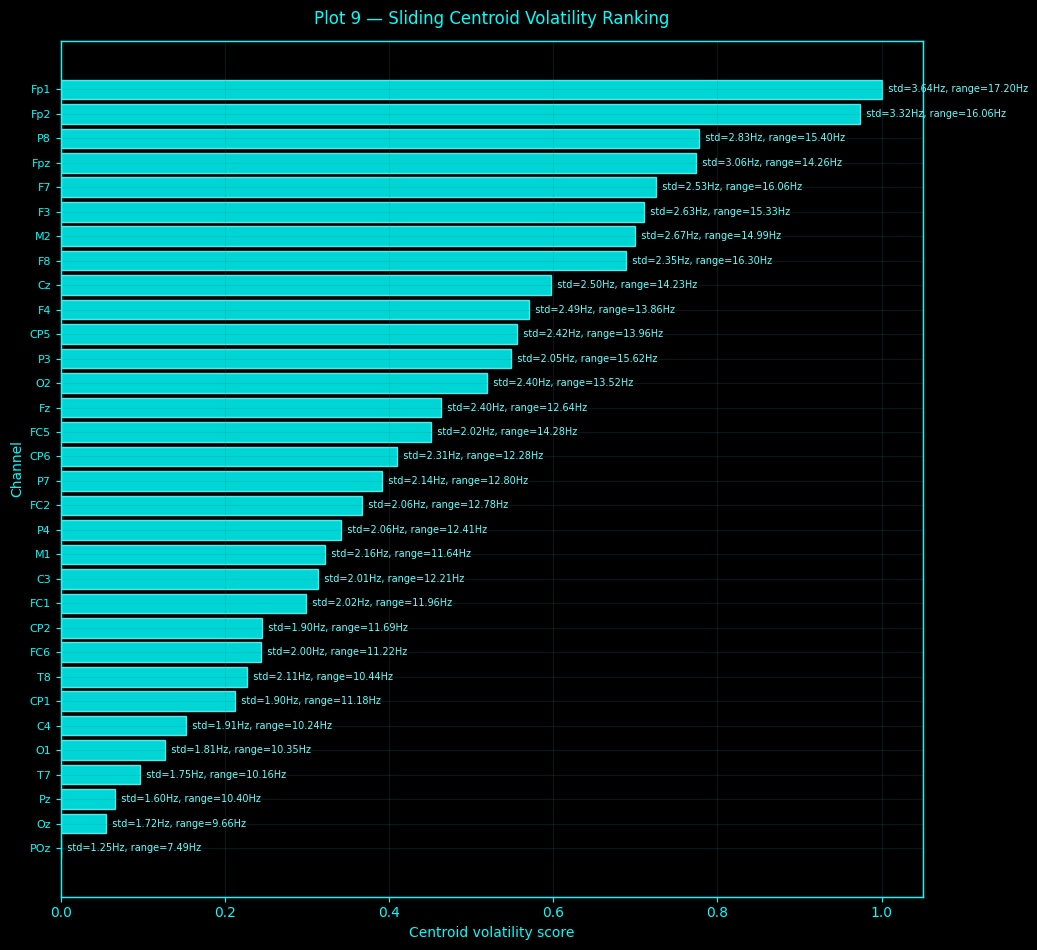

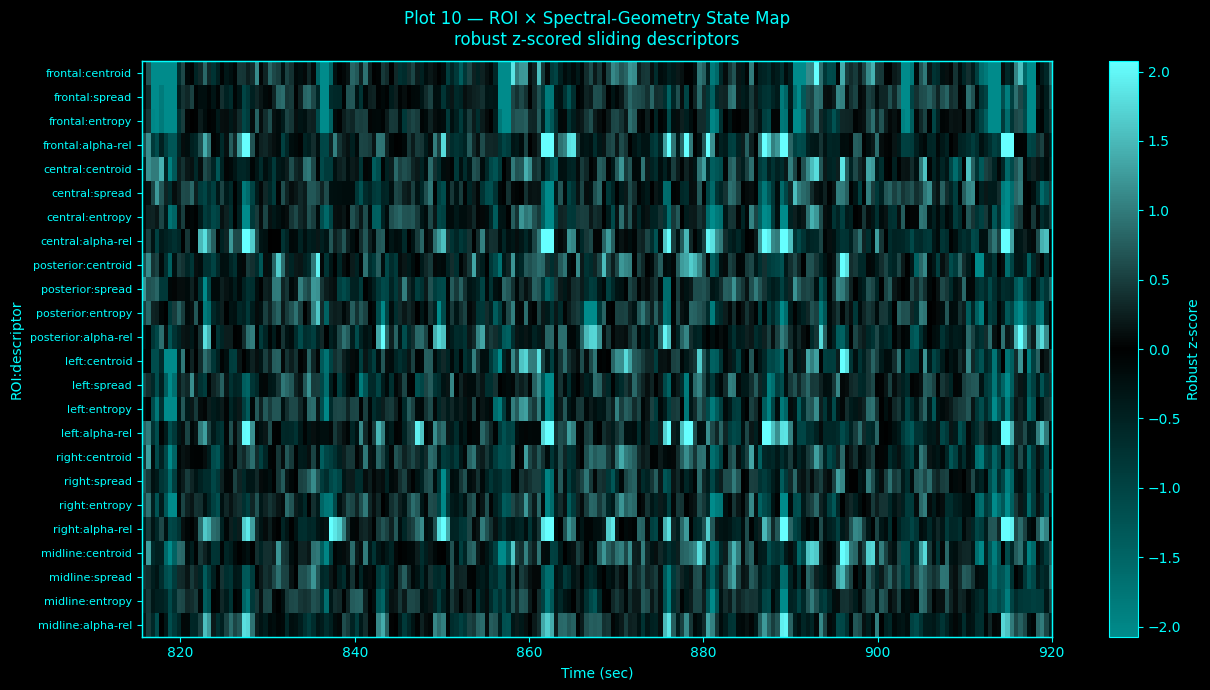

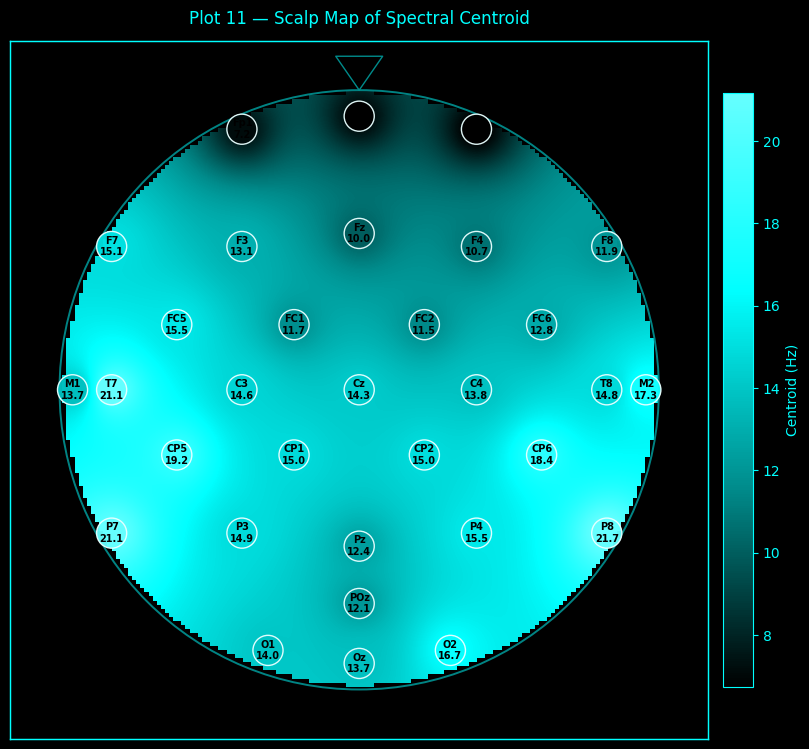

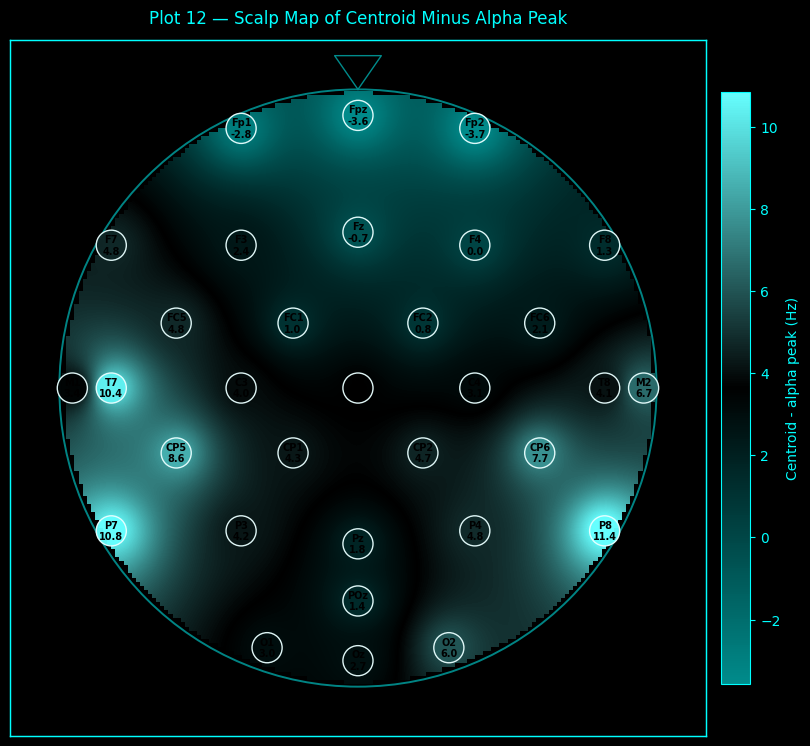

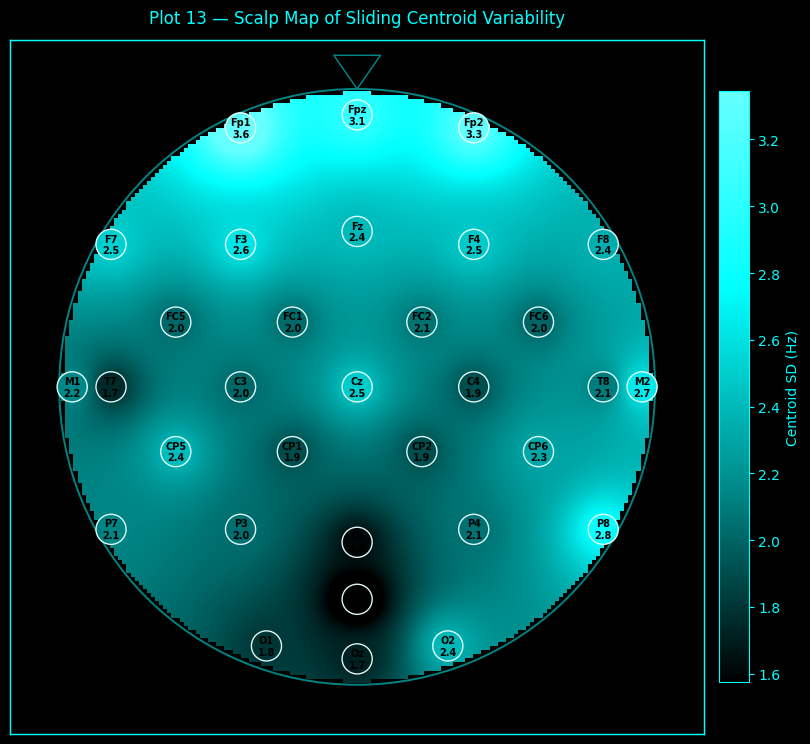

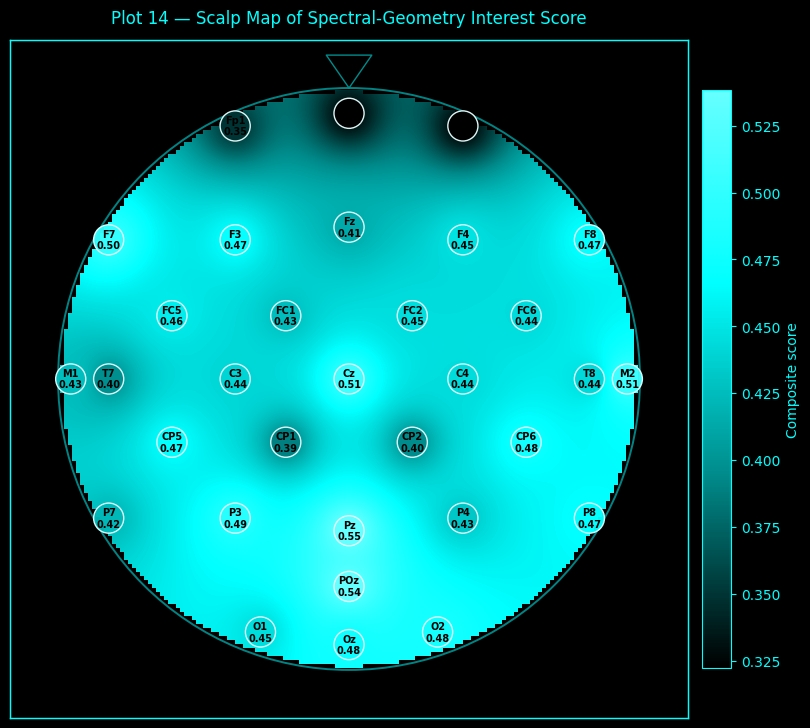

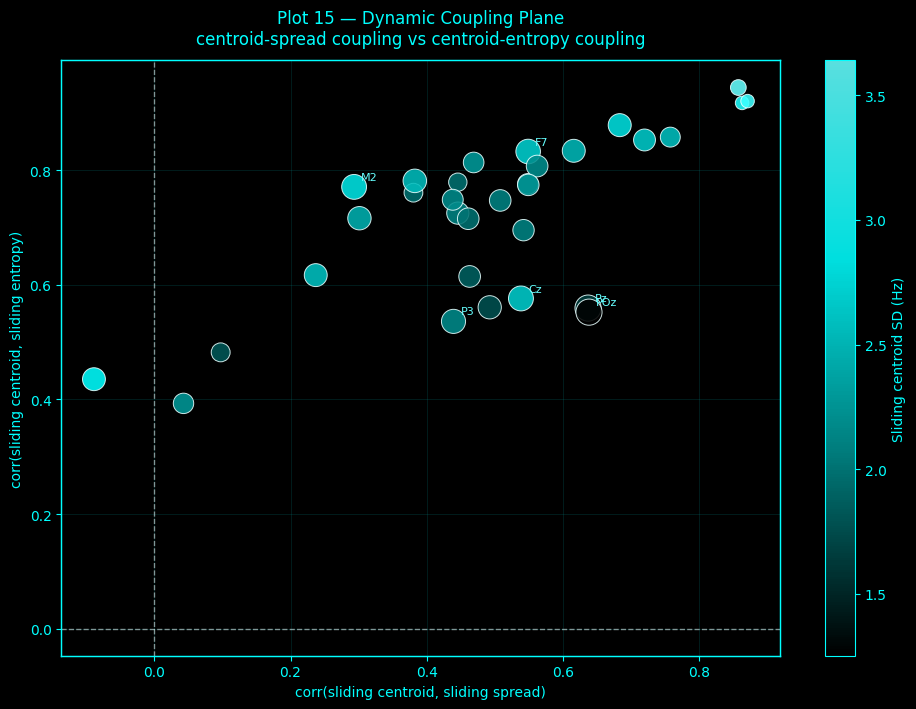

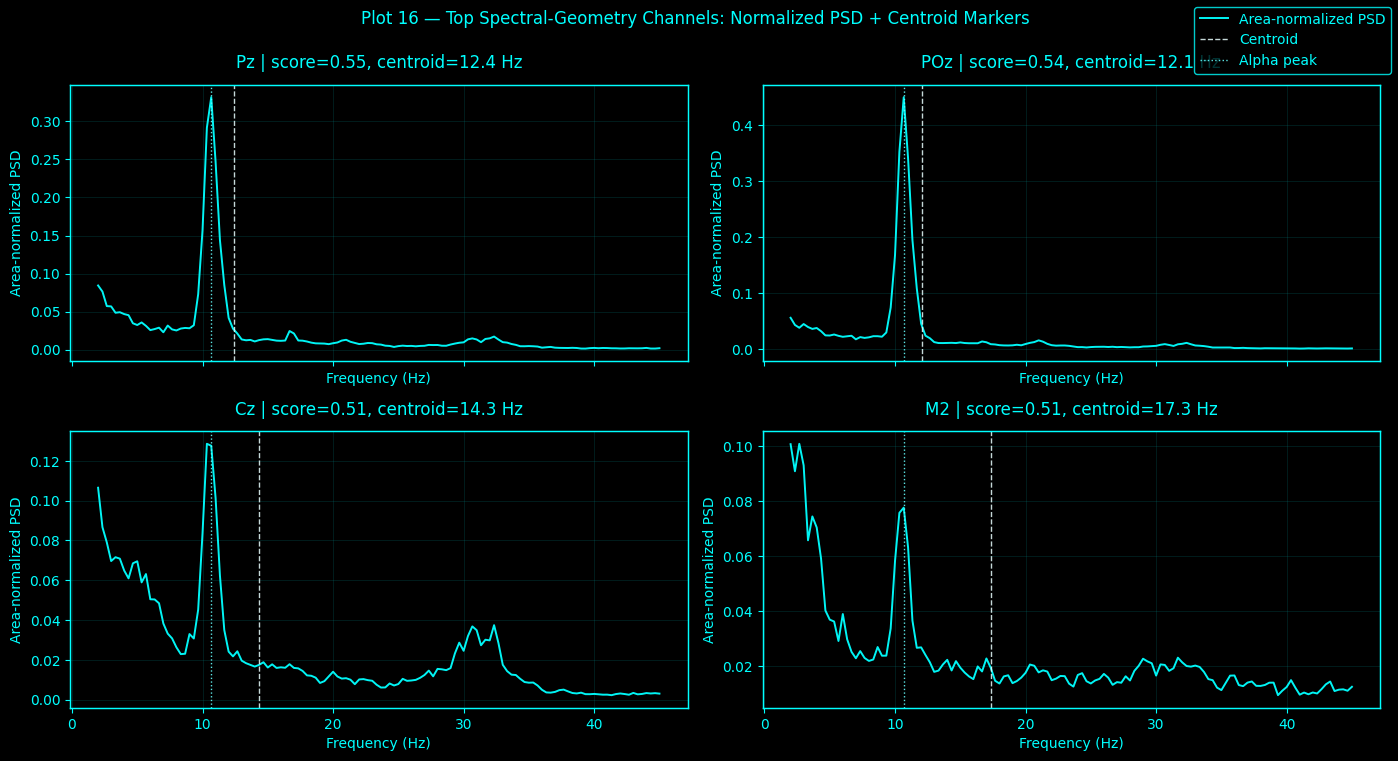

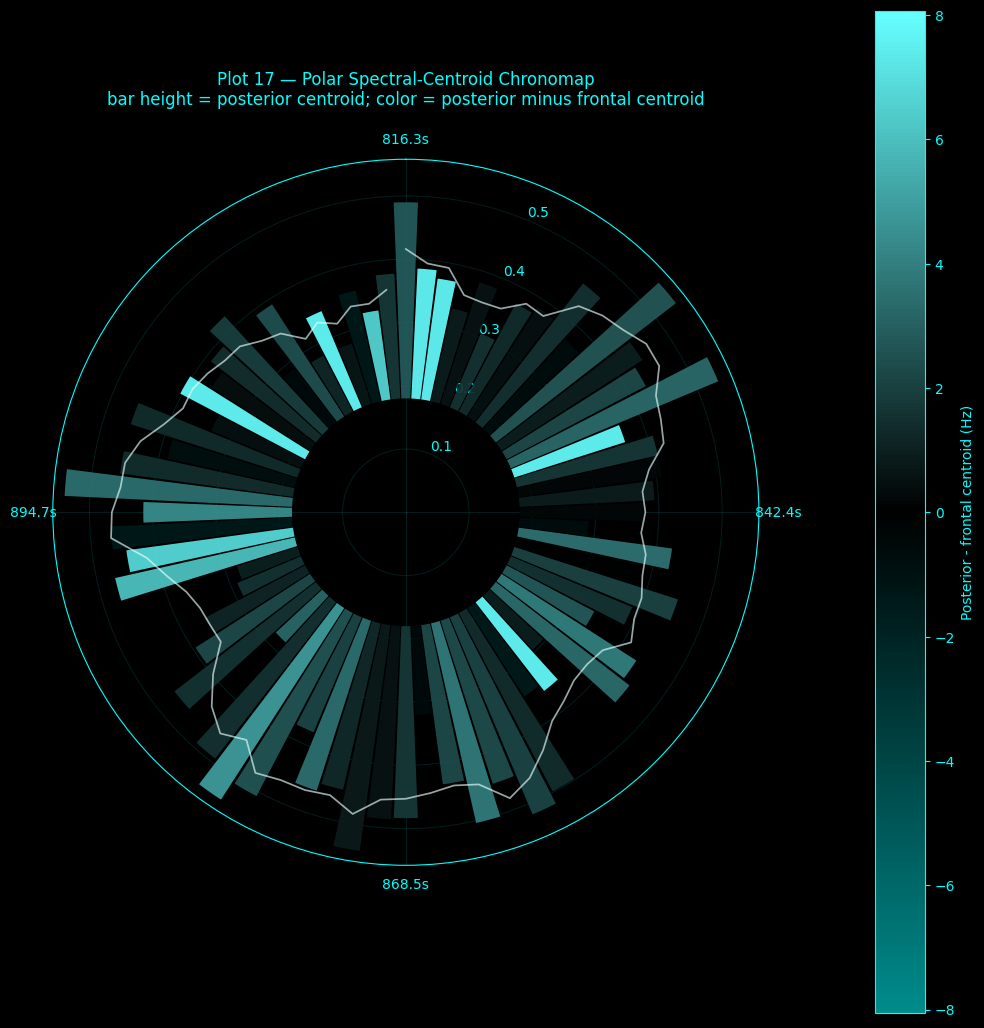

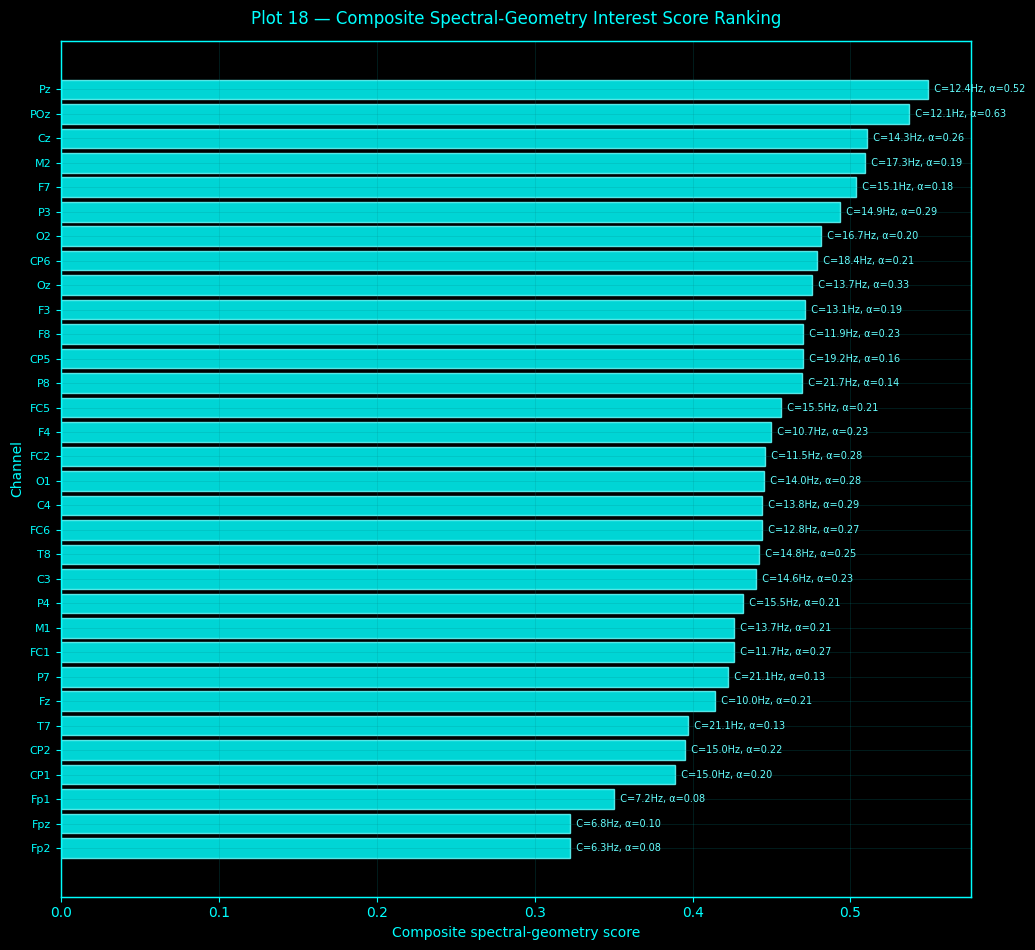


EXPERT SPECTRAL-CENTROID SUMMARY
FAST_OPTION: ultra
Original segment shape: (106944, 32)
Analysis segment shape: (26736, 32)
Original sampling rate: 1000.0 Hz
Analysis sampling rate: 250.0 Hz
Centroid band: 2.0–45.0 Hz
Channels analyzed: 32
Elapsed: 0.16 min

Top 15 channels by spectral-geometry interest score:
channel  spectral_geometry_interest_score  spectral_centroid_Hz_2_45Hz  spectral_spread_Hz_2_45Hz  alpha_relative_power_2_45Hz  alpha_peak_frequency_Hz  centroid_minus_alpha_peak_Hz  sliding_centroid_std_Hz  spectral_entropy_normalized_2_45Hz  aperiodic_slope_loglog_2_40Hz hemisphere           region
     Pz                          0.549091                    12.426514                   8.369746                     0.518996                10.666667                      1.759847                 1.598790                            0.808376                      -1.033061    midline         parietal
    POz                          0.537338                    12.061997            

In [1]:
import os
import time
import math
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False

if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

FAST_OPTION = "ultra"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    analysis_downsample_factor = 4
    centroid_band = (2.0, 45.0)
    display_band = (1.0, 60.0)
    welch_window_sec = 3.0
    welch_overlap = 0.40
    welch_nfft = None
    sliding_window_sec = 2.0
    sliding_step_sec = 0.50
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    top_trace_n = 4
    top_annotate_n = 6
    heatmap_max_time_bins = 1200
    topographic_grid_n = 150
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 170
    zip_outputs = False

elif FAST_OPTION == "fast":
    analysis_downsample_factor = 2
    centroid_band = (2.0, 45.0)
    display_band = (1.0, 60.0)
    welch_window_sec = 4.0
    welch_overlap = 0.50
    welch_nfft = None
    sliding_window_sec = 2.0
    sliding_step_sec = 0.25
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    top_trace_n = 6
    top_annotate_n = 8
    heatmap_max_time_bins = 2000
    topographic_grid_n = 190
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 190
    zip_outputs = True

elif FAST_OPTION == "balanced":
    analysis_downsample_factor = 2
    centroid_band = (2.0, 45.0)
    display_band = (1.0, 60.0)
    welch_window_sec = 4.0
    welch_overlap = 0.60
    welch_nfft = None
    sliding_window_sec = 2.0
    sliding_step_sec = 0.20
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    top_trace_n = 8
    top_annotate_n = 10
    heatmap_max_time_bins = 3200
    topographic_grid_n = 220
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 220
    zip_outputs = True

elif FAST_OPTION == "full":
    analysis_downsample_factor = 1
    centroid_band = (2.0, 45.0)
    display_band = (1.0, 60.0)
    welch_window_sec = 6.0
    welch_overlap = 0.60
    welch_nfft = None
    sliding_window_sec = 2.0
    sliding_step_sec = 0.15
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    top_trace_n = 10
    top_annotate_n = 12
    heatmap_max_time_bins = 5000
    topographic_grid_n = 260
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 240
    zip_outputs = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

out_dir = os.path.join(base_dir, "results", "exploratory_spectral_centroid_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
expert_plots_dir = os.path.join(plots_dir, "expert")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(expert_plots_dir, exist_ok=True)

sampling_rate_original = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate_original), int(end_time * sampling_rate_original)

alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
low_gamma_band = (30.0, 45.0)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

roi_definitions = {
    "frontal": ["Fp1", "Fpz", "Fp2", "F3", "Fz", "F4"],
    "central": ["C3", "Cz", "C4"],
    "posterior": ["P3", "Pz", "P4", "O1", "Oz", "O2"],
    "left": left_channels,
    "right": right_channels,
    "midline": midline_channels,
}

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

eps = 1e-12
ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True, heatmap=False, polar=False):
    ax.set_facecolor(BLACK)
    if polar:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
        ax.spines["polar"].set_color(ACCENT)
        ax.tick_params(colors=ACCENT)
    else:
        for spine in ax.spines.values():
            spine.set_color(ACCENT)
            spine.set_linewidth(1.05)
        ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
        ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
        if heatmap:
            ax.grid(False)
        elif grid:
            ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.65)
        else:
            ax.grid(False)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for lab in cbar.ax.get_yticklabels():
        lab.set_color(ACCENT)

def save_fig(fig, path, show=True):
    fig.tight_layout()
    if save_plots_to_disk and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)
    if show_plots_in_notebook and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif show_plots_in_notebook and show:
        plt.show()
    plt.close(fig)
    return path

def safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isfinite(x), x, np.nan)

def robust_minmax(x, lo=3, hi=97):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return np.zeros_like(x, dtype=float)
    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)
    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)
    return np.clip((x - a) / (b - a + eps), 0, 1)

def robust_z(x):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return np.zeros_like(x, dtype=float)
    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25
    if not np.isfinite(iqr) or iqr <= eps:
        return (x - med) / (np.nanstd(finite) + eps)
    return (x - med) / (iqr + eps)

def percentile_limits(x, lo=2, hi=98, symmetric=False):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    lo_v = float(np.percentile(x, lo))
    hi_v = float(np.percentile(x, hi))
    if symmetric:
        m = max(abs(lo_v), abs(hi_v), eps)
        return -m, m
    if hi_v <= lo_v:
        lo_v = float(np.min(x))
        hi_v = float(np.max(x))
        if hi_v <= lo_v:
            hi_v = lo_v + 1e-6
    return lo_v, hi_v

def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    if x.shape[1] > n_channels_expected:
        return x[:, :n_channels_expected]
    if x.shape[0] > n_channels_expected:
        return x.T[:, :n_channels_expected]
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def apply_notch_filter_multichannel(x, fs, f0=60.0, q=35.0, enabled=True):
    if not enabled:
        return x
    if fs <= 2 * f0:
        return x
    b, a = signal.iirnotch(w0=f0, Q=q, fs=fs)
    return signal.filtfilt(b, a, x, axis=0)

def downsample_multichannel(x, factor):
    x = np.asarray(x, dtype=float)
    if factor <= 1:
        return x
    return signal.resample_poly(x, up=1, down=factor, axis=0)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def smooth_nanaware(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x.copy()
    valid = np.isfinite(x).astype(float)
    x_fill = np.where(np.isfinite(x), x, 0.0)
    kernel = np.ones(win, dtype=float)
    num = np.convolve(x_fill, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    y = num / np.maximum(den, eps)
    y[den < 1] = np.nan
    return y

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    y = np.asarray(y, dtype=float)
    y = np.where(np.isfinite(y), y, np.nan)
    if np.any(~np.isfinite(y)):
        med = np.nanmedian(y)
        if not np.isfinite(med):
            med = 0.0
        y = np.nan_to_num(y, nan=med, posinf=med, neginf=med)
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)
    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out
    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out
    out[mask] = x[mask] / area
    return out

def weighted_spectral_moments(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    mass = integrate_trapezoid(p, f)
    if not np.isfinite(mass) or mass <= 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan
    mu = integrate_trapezoid(f * p, f) / (mass + eps)
    var = integrate_trapezoid(((f - mu) ** 2) * p, f) / (mass + eps)
    sd = np.sqrt(max(var, 0.0) + eps)
    skew = integrate_trapezoid((((f - mu) / (sd + eps)) ** 3) * p, f) / (mass + eps)
    kurt = integrate_trapezoid((((f - mu) / (sd + eps)) ** 4) * p, f) / (mass + eps)
    return float(mu), float(sd), float(skew), float(kurt), float(mass)

def spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    c = np.cumsum(p)
    if c[-1] <= 0:
        return np.nan
    c = c / c[-1]
    idx = int(np.searchsorted(c, edge))
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan
    p = p / (np.sum(p) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_flatness_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx > 0)
    if np.sum(mask) < 2:
        return np.nan
    p = np.asarray(pxx[mask], dtype=float)
    gm = np.exp(np.mean(np.log(p + eps)))
    am = np.mean(p)
    return float(gm / (am + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(8.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan
    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)
    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan
    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan
    peaks = peaks[valid]
    prominences = prominences[valid]
    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan
    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]
    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def estimate_aperiodic_slope(freqs_hz, pxx, fit_band=(2.0, 40.0), exclude_bands=((7.0, 14.0),)):
    mask = band_mask(freqs_hz, fit_band) & np.isfinite(pxx) & (pxx > 0)
    for lo, hi in exclude_bands:
        mask &= ~((freqs_hz >= lo) & (freqs_hz <= hi))
    if np.sum(mask) < 6:
        return np.nan, np.nan, np.nan
    x = np.log10(freqs_hz[mask])
    y = np.log10(pxx[mask] + eps)
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return float(slope), float(intercept), float(r2)

def sliding_spectral_geometry(y, fs, band=(2.0, 45.0), window_sec=2.0, step_sec=0.25):
    win = max(int(round(window_sec * fs)), min(256, len(y)))
    step = max(int(round(step_sec * fs)), 1)
    centers_sec = []
    centroid_series = []
    spread_series = []
    entropy_series = []
    flatness_series = []
    edge95_series = []
    alpha_rel_series = []
    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]
        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend_mode,
            nfft=None,
        )
        centroid, spread, _, _, _ = weighted_spectral_moments(freqs_hz, pxx, band=band)
        _, Hn = spectral_entropy_from_psd(freqs_hz, pxx, band=band, normalize=True)
        flat = spectral_flatness_from_psd(freqs_hz, pxx, band=band)
        edge95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=band)
        norm_pxx = area_normalize_1d(freqs_hz, pxx, band)
        alpha_rel = integrate_band_1d(freqs_hz, norm_pxx, alpha_band)
        centers_sec.append((start + stop) / 2.0 / fs)
        centroid_series.append(centroid)
        spread_series.append(spread)
        entropy_series.append(Hn)
        flatness_series.append(flat)
        edge95_series.append(edge95)
        alpha_rel_series.append(alpha_rel)
    return (
        np.asarray(centers_sec),
        np.asarray(centroid_series),
        np.asarray(spread_series),
        np.asarray(entropy_series),
        np.asarray(flatness_series),
        np.asarray(edge95_series),
        np.asarray(alpha_rel_series),
    )

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []
    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")
        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")
    df["hemisphere"] = hemispheres
    df["region"] = regions
    return df

def add_expert_scores(df):
    df = df.copy()
    df["spectral_concentration_2_45Hz"] = 1.0 - df["spectral_entropy_normalized_2_45Hz"]
    df["centroid_volatility_score"] = (
        0.55 * robust_minmax(df["sliding_centroid_std_Hz"].to_numpy(dtype=float))
        + 0.45 * robust_minmax(df["sliding_centroid_range_Hz"].to_numpy(dtype=float))
    )
    df["alpha_anchor_strength"] = robust_minmax(-np.abs(df["centroid_minus_alpha_peak_Hz"].to_numpy(dtype=float)))
    df["spectral_geometry_interest_score"] = (
        0.22 * robust_minmax(df["spectral_centroid_Hz_2_45Hz"].to_numpy(dtype=float))
        + 0.16 * robust_minmax(df["spectral_spread_Hz_2_45Hz"].to_numpy(dtype=float))
        + 0.16 * robust_minmax(df["alpha_relative_power_2_45Hz"].to_numpy(dtype=float))
        + 0.14 * robust_minmax(df["alpha_peak_contrast"].to_numpy(dtype=float))
        + 0.12 * robust_minmax(df["spectral_concentration_2_45Hz"].to_numpy(dtype=float))
        + 0.10 * robust_minmax(df["centroid_volatility_score"].to_numpy(dtype=float))
        + 0.10 * robust_minmax(-df["aperiodic_slope_loglog_2_40Hz"].to_numpy(dtype=float))
    )
    return df

def downsample_time_heatmap(M, t, max_bins):
    M = np.asarray(M, dtype=float)
    if max_bins is None or M.shape[1] <= max_bins:
        return M, t
    step = int(np.ceil(M.shape[1] / max_bins))
    return M[:, ::step], t[::step]

def plot_topographic_metric(summary_df, metric_col, title, cbar_label, path, cmap=CYAN_SEQUENTIAL_CMAP):
    df = summary_df.copy()
    df = df[np.isfinite(df[metric_col])]
    xs = []
    ys = []
    vals = []
    labels = []
    for _, row in df.iterrows():
        ch = row["channel"]
        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row[metric_col]))
            labels.append(ch)
    if len(vals) == 0:
        return None
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)
    gx = np.linspace(-1.18, 1.18, topographic_grid_n)
    gy = np.linspace(-1.18, 1.18, topographic_grid_n)
    GX, GY = np.meshgrid(gx, gy)
    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2
    Z_num = np.zeros_like(GX)
    Z_den = np.zeros_like(GX)
    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.025 ** 2)
        Z_num += w * v
        Z_den += w
    Z = Z_num / (Z_den + eps)
    Z[~mask] = np.nan
    finite = vals[np.isfinite(vals)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1
    fig, ax = plt.subplots(figsize=(8.2, 8.2), facecolor=BLACK)
    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )
    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)
    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)
    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )
    for x, y, ch, v in zip(xs, ys, labels, vals):
        if "Hz" in metric_col or "centroid" in metric_col or "spread" in metric_col or "edge" in metric_col:
            label = f"{ch}\n{v:.1f}"
        else:
            label = f"{ch}\n{v:.2f}"
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])
    style_ax(ax, title=title, xlabel="", ylabel="", grid=False, heatmap=True)
    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    style_cbar(cbar, cbar_label)
    save_fig(fig, path)
    return path

start_all = time.perf_counter()

print("Running expert spectral-centroid analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)

eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment_original = eeg_data[start_index:end_index, :len(eeg_channel_names)].copy()
segment_original = maybe_common_average_reference(segment_original, enabled=apply_common_average_reference)
segment_original = apply_notch_filter_multichannel(
    segment_original,
    fs=sampling_rate_original,
    f0=60.0,
    q=notch_q,
    enabled=apply_notch_60,
)

segment = downsample_multichannel(segment_original, analysis_downsample_factor)
sampling_rate = sampling_rate_original / analysis_downsample_factor

effective_centroid_band = (
    centroid_band[0],
    min(centroid_band[1], 0.45 * sampling_rate),
)
effective_display_band = (
    display_band[0],
    min(display_band[1], 0.45 * sampling_rate),
)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Original segment shape: {segment_original.shape}")
print(f"Analysis segment shape: {segment.shape}")
print(f"Analysis sampling rate: {sampling_rate:.2f} Hz")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Centroid band: {effective_centroid_band[0]:.1f}–{effective_centroid_band[1]:.1f} Hz")

spectral_geometry_dict = {}
summary_rows = []
mean_psd_matrix = []
sliding_centroid_matrix = []
sliding_spread_matrix = []
sliding_entropy_matrix = []
sliding_flatness_matrix = []
sliding_edge95_matrix = []
sliding_alpha_rel_matrix = []
time_centers_ref = None
freqs_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    t0 = time.perf_counter()
    y = segment[:, ch_i]

    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, effective_centroid_band)

    centroid_hz, spread_hz, skewness, kurtosis, mass = weighted_spectral_moments(
        freqs_hz,
        pxx,
        band=effective_centroid_band,
    )

    H_raw, H_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=effective_centroid_band, normalize=True)
    flatness = spectral_flatness_from_psd(freqs_hz, pxx, band=effective_centroid_band)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    alpha_rel = integrate_band_1d(freqs_hz, mean_psd_norm, alpha_band)
    theta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, theta_band)
    beta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, beta_band)
    low_gamma_rel = integrate_band_1d(freqs_hz, mean_psd_norm, low_gamma_band)

    sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=effective_centroid_band)
    sef80 = spectral_edge_frequency(freqs_hz, pxx, edge=0.80, band=effective_centroid_band)
    sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=effective_centroid_band)

    rolloff_span = sef95 - sef50 if np.isfinite(sef95) and np.isfinite(sef50) else np.nan

    centroid_minus_alpha_peak = (
        centroid_hz - alpha_peak_hz
        if np.isfinite(centroid_hz) and np.isfinite(alpha_peak_hz)
        else np.nan
    )

    slope, intercept, slope_r2 = estimate_aperiodic_slope(
        freqs_hz,
        pxx,
        fit_band=(2.0, min(40.0, effective_centroid_band[1])),
        exclude_bands=((7.0, 14.0),),
    )

    (
        t_centers_sec,
        centroid_series,
        spread_series,
        entropy_series,
        flatness_series,
        edge95_series,
        alpha_rel_series,
    ) = sliding_spectral_geometry(
        y,
        fs=sampling_rate,
        band=effective_centroid_band,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
    )

    if time_centers_ref is None:
        time_centers_ref = t_centers_sec

    if np.nanstd(centroid_series) > 0 and np.nanstd(spread_series) > 0:
        centroid_spread_coupling = float(np.corrcoef(centroid_series, spread_series)[0, 1])
    else:
        centroid_spread_coupling = np.nan

    if np.nanstd(centroid_series) > 0 and np.nanstd(entropy_series) > 0:
        centroid_entropy_coupling = float(np.corrcoef(centroid_series, entropy_series)[0, 1])
    else:
        centroid_entropy_coupling = np.nan

    if np.nanstd(centroid_series) > 0 and np.nanstd(alpha_rel_series) > 0:
        centroid_alpha_coupling = float(np.corrcoef(centroid_series, alpha_rel_series)[0, 1])
    else:
        centroid_alpha_coupling = np.nan

    spectral_geometry_dict[ch_name] = {
        "spectral_centroid_Hz": centroid_hz,
        "spectral_spread_Hz": spread_hz,
        "spectral_skewness": skewness,
        "spectral_kurtosis": kurtosis,
        "spectral_entropy_normalized": H_norm,
        "spectral_flatness": flatness,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_relative_power": alpha_rel,
        "theta_relative_power": theta_rel,
        "beta_relative_power": beta_rel,
        "low_gamma_relative_power": low_gamma_rel,
        "spectral_edge_50Hz": sef50,
        "spectral_edge_80Hz": sef80,
        "spectral_edge_95Hz": sef95,
        "rolloff_span_Hz": rolloff_span,
        "centroid_minus_alpha_peak_Hz": centroid_minus_alpha_peak,
        "aperiodic_slope_loglog_2_40Hz": slope,
        "aperiodic_intercept_loglog_2_40Hz": intercept,
        "aperiodic_fit_r2": slope_r2,
        "sliding_centroid_Hz": centroid_series,
        "sliding_spread_Hz": spread_series,
        "sliding_entropy_normalized": entropy_series,
        "sliding_flatness": flatness_series,
        "sliding_edge95_Hz": edge95_series,
        "sliding_alpha_relative_power": alpha_rel_series,
        "time_sec_rel": t_centers_sec,
        "frequencies_hz": freqs_hz,
        "mean_psd_area_norm": mean_psd_norm,
    }

    summary_rows.append({
        "channel": ch_name,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_spread_Hz_2_45Hz": spread_hz,
        "spectral_skewness_2_45Hz": skewness,
        "spectral_kurtosis_2_45Hz": kurtosis,
        "spectral_entropy_normalized_2_45Hz": H_norm,
        "spectral_entropy_raw_2_45Hz": H_raw,
        "spectral_flatness_2_45Hz": flatness,
        "spectral_mass_2_45Hz": mass,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "low_gamma_relative_power_2_45Hz": low_gamma_rel,
        "alpha_theta_ratio": alpha_rel / (theta_rel + eps),
        "alpha_beta_ratio": alpha_rel / (beta_rel + eps),
        "alpha_low_gamma_ratio": alpha_rel / (low_gamma_rel + eps),
        "spectral_edge_50Hz": sef50,
        "spectral_edge_80Hz": sef80,
        "spectral_edge_95Hz": sef95,
        "rolloff_span_Hz": rolloff_span,
        "centroid_minus_alpha_peak_Hz": centroid_minus_alpha_peak,
        "aperiodic_slope_loglog_2_40Hz": slope,
        "aperiodic_intercept_loglog_2_40Hz": intercept,
        "aperiodic_fit_r2": slope_r2,
        "sliding_centroid_mean_Hz": float(np.nanmean(centroid_series)),
        "sliding_centroid_std_Hz": float(np.nanstd(centroid_series)),
        "sliding_centroid_range_Hz": float(np.nanmax(centroid_series) - np.nanmin(centroid_series)),
        "sliding_spread_mean_Hz": float(np.nanmean(spread_series)),
        "sliding_spread_std_Hz": float(np.nanstd(spread_series)),
        "sliding_entropy_mean": float(np.nanmean(entropy_series)),
        "sliding_entropy_std": float(np.nanstd(entropy_series)),
        "sliding_flatness_mean": float(np.nanmean(flatness_series)),
        "sliding_edge95_mean_Hz": float(np.nanmean(edge95_series)),
        "sliding_alpha_relative_mean": float(np.nanmean(alpha_rel_series)),
        "centroid_spread_coupling": centroid_spread_coupling,
        "centroid_entropy_coupling": centroid_entropy_coupling,
        "centroid_alpha_coupling": centroid_alpha_coupling,
        "has_clear_alpha_peak": bool(np.isfinite(alpha_peak_hz)),
        "elapsed_sec_channel": time.perf_counter() - t0,
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_centroid_matrix.append(centroid_series)
    sliding_spread_matrix.append(spread_series)
    sliding_entropy_matrix.append(entropy_series)
    sliding_flatness_matrix.append(flatness_series)
    sliding_edge95_matrix.append(edge95_series)
    sliding_alpha_rel_matrix.append(alpha_rel_series)

    print(
        f"[{ch_i + 1:02d}/{len(eeg_channel_names)}] {ch_name:>3s} | "
        f"centroid={centroid_hz:.2f} Hz | spread={spread_hz:.2f} Hz | "
        f"alpha={alpha_rel:.3f} | entropy={H_norm:.3f} | "
        f"{time.perf_counter() - t0:.2f}s",
        flush=True,
    )

summary_df = pd.DataFrame(summary_rows)

for col in summary_df.columns:
    if col not in ["channel", "has_clear_alpha_peak"]:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df = add_channel_metadata(summary_df)
summary_df = add_expert_scores(summary_df)

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_centroid_matrix = np.column_stack(sliding_centroid_matrix)
sliding_spread_matrix = np.column_stack(sliding_spread_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
sliding_flatness_matrix = np.column_stack(sliding_flatness_matrix)
sliding_edge95_matrix = np.column_stack(sliding_edge95_matrix)
sliding_alpha_rel_matrix = np.column_stack(sliding_alpha_rel_matrix)

time_sec_abs = start_time + time_centers_ref

dict_npy_path = os.path.join(out_dir, f"SpectralCentroids_x_{FAST_OPTION}.npy")
npz_path = os.path.join(out_dir, f"exploratory_spectral_centroid_outputs_{FAST_OPTION}.npz")
summary_csv_path = os.path.join(out_dir, f"spectral_centroid_channel_summary_{FAST_OPTION}.csv")
notes_txt_path = os.path.join(out_dir, f"exploratory_spectral_centroid_notes_{FAST_OPTION}.txt")
metadata_json_path = os.path.join(out_dir, f"spectral_centroid_metadata_{FAST_OPTION}.json")

np.save(dict_npy_path, spectral_geometry_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_centroid_Hz=sliding_centroid_matrix,
    sliding_spread_Hz=sliding_spread_matrix,
    sliding_entropy_normalized=sliding_entropy_matrix,
    sliding_flatness=sliding_flatness_matrix,
    sliding_edge95_Hz=sliding_edge95_matrix,
    sliding_alpha_relative_power=sliding_alpha_rel_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate_original,
    analysis_sampling_rate=sampling_rate,
    analysis_downsample_factor=analysis_downsample_factor,
    centroid_band=np.array(effective_centroid_band, dtype=float),
    display_band=np.array(effective_display_band, dtype=float),
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
    FAST_OPTION=FAST_OPTION,
)

summary_df.to_csv(summary_csv_path, index=False)

metadata = {
    "FAST_OPTION": FAST_OPTION,
    "base_dir": base_dir,
    "eeg_path": eeg_path,
    "segment_start_sec": start_time,
    "segment_end_sec": end_time,
    "original_sampling_rate_hz": sampling_rate_original,
    "analysis_sampling_rate_hz": sampling_rate,
    "analysis_downsample_factor": analysis_downsample_factor,
    "centroid_band_hz": list(effective_centroid_band),
    "display_band_hz": list(effective_display_band),
    "welch_window_sec": welch_window_sec,
    "welch_overlap": welch_overlap,
    "sliding_window_sec": sliding_window_sec,
    "sliding_step_sec": sliding_step_sec,
    "apply_common_average_reference": apply_common_average_reference,
    "apply_notch_60": apply_notch_60,
    "notch_q": notch_q,
    "channel_names": eeg_channel_names,
    "segment_shape_original": list(segment_original.shape),
    "segment_shape_analysis": list(segment.shape),
}

with open(metadata_json_path, "w") as f:
    json.dump(metadata, f, indent=2)

top_centroid = summary_df.sort_values("spectral_centroid_Hz_2_45Hz", ascending=False).head(8)
low_centroid = summary_df.sort_values("spectral_centroid_Hz_2_45Hz", ascending=True).head(8)
top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_score = summary_df.sort_values("spectral_geometry_interest_score", ascending=False).head(12)

with open(notes_txt_path, "w") as f:
    f.write("Expert exploratory spectral-centroid notes\n")
    f.write("==========================================\n\n")
    f.write("Intent:\n")
    f.write("This analysis treats spectral centroid as one part of an exploratory spectral-geometry view of the selected EEG segment.\n")
    f.write("It is not a clinical biomarker, not a publication-ready benchmark, and not a standalone score.\n\n")
    f.write("Upgrades in this version:\n")
    f.write("1. Added FAST_OPTION modes: ultra, fast, balanced, full.\n")
    f.write("2. Added optional downsampling and notch filtering for faster, cleaner spectral computation.\n")
    f.write("3. Preserved the original spectral centroid, PSD heatmap, descriptor, ROI, and sliding plots.\n")
    f.write("4. Added expert diagnostics: spectral geometry fingerprint, volatility ranking, ROI state maps, scalp maps,\n")
    f.write("   coupling plots, top-channel PSD galleries, polar chronomap, and composite exploratory score.\n")
    f.write("5. Kept the centroid restricted to a controlled 2–45 Hz band to avoid DC drift and line-noise dominance.\n\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original sampling rate: {sampling_rate_original} Hz\n")
    f.write(f"Analysis sampling rate: {sampling_rate:.2f} Hz\n")
    f.write(f"Analysis downsample factor: {analysis_downsample_factor}\n")
    f.write(f"Centroid band: [{effective_centroid_band[0]:.1f}, {effective_centroid_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n")
    f.write(f"Notch 60 Hz applied: {apply_notch_60}\n\n")
    f.write("Top channels by composite spectral-geometry interest score:\n")
    for _, row in top_score.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"score={row['spectral_geometry_interest_score']:.6f}, "
            f"centroid={row['spectral_centroid_Hz_2_45Hz']:.3f} Hz, "
            f"spread={row['spectral_spread_Hz_2_45Hz']:.3f} Hz, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"entropy={row['spectral_entropy_normalized_2_45Hz']:.4f}, "
            f"volatility={row['centroid_volatility_score']:.4f}\n"
        )
    f.write("\nHighest centroid channels:\n")
    for _, row in top_centroid.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"centroid={row['spectral_centroid_Hz_2_45Hz']:.3f} Hz, "
            f"spread={row['spectral_spread_Hz_2_45Hz']:.3f} Hz, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"centroid-alpha={row['centroid_minus_alpha_peak_Hz']}\n"
        )
    f.write("\nLowest centroid channels:\n")
    for _, row in low_centroid.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"centroid={row['spectral_centroid_Hz_2_45Hz']:.3f} Hz, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"alpha_contrast={row['alpha_peak_contrast']:.3f}\n"
        )
    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"centroid={row['spectral_centroid_Hz_2_45Hz']:.3f} Hz, "
            f"centroid-alpha={row['centroid_minus_alpha_peak_Hz']}\n"
        )

plot_paths = []

sort_df = summary_df.sort_values("spectral_centroid_Hz_2_45Hz", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BLACK)
y = sort_df["spectral_centroid_Hz_2_45Hz"].to_numpy(dtype=float)
colors = sort_df["spectral_entropy_normalized_2_45Hz"].to_numpy(dtype=float)
bars = ax.bar(
    sort_df["channel"],
    y,
    color=ACCENT,
    edgecolor=ACCENT_SOFT,
    alpha=0.88,
)
ax.axhline(np.nanmedian(y), color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75, label=f"Median={np.nanmedian(y):.2f} Hz")
style_ax(
    ax,
    title="Plot 1 — Spectral Centroid by Channel\n2–45 Hz, sorted high to low",
    xlabel="Channel",
    ylabel="Spectral centroid (Hz)",
)
ax.tick_params(axis="x", rotation=45)
leg = ax.legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"01_spectral_centroid_bar_sorted_{FAST_OPTION}.png")))

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BLACK)
scatter = ax.scatter(
    summary_df["spectral_centroid_Hz_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["spectral_entropy_normalized_2_45Hz"].values,
    s=90 + 260 * robust_minmax(summary_df["spectral_geometry_interest_score"].values),
    alpha=0.90,
    cmap=CYAN_SEQUENTIAL_CMAP,
    edgecolors=WHITE,
    linewidths=0.7,
)
annotate_df = summary_df.sort_values("spectral_geometry_interest_score", ascending=False).head(top_annotate_n)
for _, row in annotate_df.iterrows():
    ax.annotate(
        row["channel"],
        (row["spectral_centroid_Hz_2_45Hz"], row["alpha_relative_power_2_45Hz"]),
        xytext=(5, 5),
        textcoords="offset points",
        color=ACCENT_SOFT,
        fontsize=8,
    )
style_ax(
    ax,
    title="Plot 2 — Spectral Centroid vs Alpha Relative Power\ncolor = entropy, size = expert spectral-geometry score",
    xlabel="Spectral centroid (Hz, 2–45 Hz)",
    ylabel="Alpha relative power",
)
cbar = plt.colorbar(scatter, ax=ax)
style_cbar(cbar, "Normalized spectral entropy")
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"02_centroid_vs_alpha_descriptor_space_{FAST_OPTION}.png")))

sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, effective_centroid_band)
freqs_display = freqs_ref[display_mask]
heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-8)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BLACK)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9, color=ACCENT)
style_ax(
    ax,
    title="Plot 3 — Channel × Frequency Area-Normalized PSD\nrows sorted by spectral centroid",
    xlabel="Frequency (Hz)",
    ylabel="Channel",
    heatmap=True,
)
cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "log10(area-normalized PSD)")
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"03_channel_frequency_heatmap_centroid_sorted_{FAST_OPTION}.png")))

centroid_sorted_df = summary_df.sort_values(
    by=["spectral_centroid_Hz_2_45Hz", "sliding_centroid_std_Hz"],
    ascending=[False, False],
).reset_index(drop=True)
centroid_sorted_channels = list(centroid_sorted_df["channel"].values)
centroid_sorted_idx = [eeg_channel_names.index(ch) for ch in centroid_sorted_channels]
sliding_heat = sliding_centroid_matrix[:, centroid_sorted_idx].T
sliding_heat_ds, time_ds = downsample_time_heatmap(sliding_heat, time_sec_abs, heatmap_max_time_bins)
vmin, vmax = percentile_limits(sliding_heat_ds, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BLACK)
im = ax.imshow(
    sliding_heat_ds,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[time_ds[0], time_ds[-1], len(centroid_sorted_channels), 0],
)
ax.set_yticks(np.arange(len(centroid_sorted_channels)) + 0.5)
ax.set_yticklabels(centroid_sorted_channels, fontsize=9, color=ACCENT)
style_ax(
    ax,
    title="Plot 4 — Channel × Time Sliding Spectral Centroid\nrows sorted by stationary centroid",
    xlabel="Time (sec)",
    ylabel="Channel",
    heatmap=True,
)
cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Sliding centroid (Hz)")
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"04_sliding_centroid_heatmap_{FAST_OPTION}.png")))

frontal_centroid = roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_definitions["frontal"])
central_centroid = roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_definitions["central"])
posterior_centroid = roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BLACK)
ax.plot(time_sec_abs, smooth_nanaware(frontal_centroid, win=5), color=WHITE, linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_nanaware(central_centroid, win=5), color=ACCENT_SOFT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_nanaware(posterior_centroid, win=5), color=ACCENT, linewidth=2.0, alpha=0.95, label="Posterior ROI")
style_ax(
    ax,
    title="Plot 5 — ROI Mean Sliding Spectral Centroid",
    xlabel="Time (sec)",
    ylabel="Spectral centroid (Hz)",
)
leg = ax.legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"05_roi_mean_sliding_centroid_{FAST_OPTION}.png")))

top_alpha_channels = list(summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(top_trace_n)["channel"].values)
n = len(top_alpha_channels)
ncols = 2
nrows = int(math.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows), facecolor=BLACK, sharex=True, squeeze=False)
axes = axes.ravel()
for ax in axes:
    ax.set_facecolor(BLACK)
    ax.axis("off")
for ax, ch_name in zip(axes, top_alpha_channels):
    ax.axis("on")
    ch_idx = eeg_channel_names.index(ch_name)
    c_series = smooth_nanaware(sliding_centroid_matrix[:, ch_idx], win=5)
    s_series = smooth_nanaware(sliding_spread_matrix[:, ch_idx], win=5)
    ax.plot(time_sec_abs, c_series, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding centroid")
    ax.plot(time_sec_abs, s_series, color=WHITE, linewidth=1.2, alpha=0.9, label="Sliding spread")
    row = summary_df[summary_df["channel"] == ch_name].iloc[0]
    style_ax(
        ax,
        title=f"{ch_name} | alpha={row['alpha_relative_power_2_45Hz']:.2f}, centroid={row['spectral_centroid_Hz_2_45Hz']:.1f} Hz",
        xlabel="Time (sec)",
        ylabel="Hz",
    )
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)
fig.suptitle("Plot 6 — Top Alpha Channels: Sliding Centroid and Spread", color=ACCENT, y=0.995)
plot_paths.append(save_fig(fig, os.path.join(plots_dir, f"06_top_alpha_channels_centroid_spread_{FAST_OPTION}.png")))

fingerprint_cols = [
    "spectral_centroid_Hz_2_45Hz",
    "spectral_spread_Hz_2_45Hz",
    "spectral_skewness_2_45Hz",
    "spectral_kurtosis_2_45Hz",
    "spectral_entropy_normalized_2_45Hz",
    "spectral_flatness_2_45Hz",
    "alpha_relative_power_2_45Hz",
    "low_gamma_relative_power_2_45Hz",
    "alpha_peak_contrast",
    "centroid_minus_alpha_peak_Hz",
    "spectral_edge_95Hz",
    "rolloff_span_Hz",
    "sliding_centroid_std_Hz",
    "centroid_spread_coupling",
    "centroid_entropy_coupling",
    "aperiodic_slope_loglog_2_40Hz",
    "spectral_geometry_interest_score",
]
fingerprint_cols = [c for c in fingerprint_cols if c in summary_df.columns]
fp_df = summary_df.sort_values("spectral_geometry_interest_score", ascending=False).copy()
M = fp_df[fingerprint_cols].to_numpy(dtype=float)
Z = np.zeros_like(M)
for j in range(M.shape[1]):
    Z[:, j] = robust_z(M[:, j])
vmax_abs = np.nanpercentile(np.abs(Z[np.isfinite(Z)]), 95) if np.any(np.isfinite(Z)) else 1
vmax_abs = max(vmax_abs, 1e-6)

fig, ax = plt.subplots(figsize=(13.5, max(7, 0.30 * len(fp_df))), facecolor=BLACK)
im = ax.imshow(
    Z,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_DIVERGING_CMAP,
    vmin=-vmax_abs,
    vmax=vmax_abs,
)
ax.set_xticks(np.arange(len(fingerprint_cols)))
ax.set_xticklabels(fingerprint_cols, rotation=50, ha="right", color=ACCENT, fontsize=8)
ax.set_yticks(np.arange(len(fp_df)))
ax.set_yticklabels(fp_df["channel"], color=ACCENT, fontsize=8)
style_ax(
    ax,
    title="Plot 7 — Expert Spectral-Geometry Fingerprint\nrobust z-scores, rows sorted by composite score",
    xlabel="Descriptor",
    ylabel="Channel",
    heatmap=True,
)
cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Robust z-score")
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"07_expert_spectral_geometry_fingerprint_{FAST_OPTION}.png")))

fig, ax = plt.subplots(figsize=(10, 7.3), facecolor=BLACK)
scatter = ax.scatter(
    summary_df["spectral_centroid_Hz_2_45Hz"],
    summary_df["spectral_spread_Hz_2_45Hz"],
    c=summary_df["alpha_relative_power_2_45Hz"],
    s=90 + 280 * robust_minmax(summary_df["spectral_geometry_interest_score"]),
    cmap=CYAN_SEQUENTIAL_CMAP,
    edgecolors=WHITE,
    linewidths=0.7,
    alpha=0.90,
)
for _, row in summary_df.sort_values("spectral_geometry_interest_score", ascending=False).head(top_annotate_n).iterrows():
    ax.annotate(
        row["channel"],
        (row["spectral_centroid_Hz_2_45Hz"], row["spectral_spread_Hz_2_45Hz"]),
        xytext=(5, 5),
        textcoords="offset points",
        color=ACCENT_SOFT,
        fontsize=8,
    )
style_ax(
    ax,
    title="Plot 8 — Spectral Geometry Plane\nx = center-of-mass, y = spectral spread, color = alpha power",
    xlabel="Spectral centroid (Hz)",
    ylabel="Spectral spread (Hz)",
)
cbar = plt.colorbar(scatter, ax=ax)
style_cbar(cbar, "Alpha relative power")
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"08_centroid_spread_geometry_plane_{FAST_OPTION}.png")))

vol_df = summary_df.sort_values("centroid_volatility_score", ascending=True)
fig, ax = plt.subplots(figsize=(10.5, max(7, 0.30 * len(vol_df))), facecolor=BLACK)
ypos = np.arange(len(vol_df))
ax.barh(
    ypos,
    vol_df["centroid_volatility_score"],
    color=ACCENT,
    edgecolor=ACCENT_SOFT,
    alpha=0.84,
)
ax.set_yticks(ypos)
ax.set_yticklabels(vol_df["channel"], color=ACCENT, fontsize=8)
for yi, (_, row) in zip(ypos, vol_df.iterrows()):
    ax.text(
        row["centroid_volatility_score"],
        yi,
        f"  std={row['sliding_centroid_std_Hz']:.2f}Hz, range={row['sliding_centroid_range_Hz']:.2f}Hz",
        va="center",
        ha="left",
        color=ACCENT_SOFT,
        fontsize=7,
    )
style_ax(
    ax,
    title="Plot 9 — Sliding Centroid Volatility Ranking",
    xlabel="Centroid volatility score",
    ylabel="Channel",
)
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"09_centroid_volatility_ranking_{FAST_OPTION}.png")))

roi_state_rows = []
roi_state_labels = []
for roi_name, roi_channels in roi_definitions.items():
    roi_state_rows.append(robust_z(roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_channels)))
    roi_state_labels.append(f"{roi_name}:centroid")
    roi_state_rows.append(robust_z(roi_average_matrix(sliding_spread_matrix, eeg_channel_names, roi_channels)))
    roi_state_labels.append(f"{roi_name}:spread")
    roi_state_rows.append(robust_z(roi_average_matrix(sliding_entropy_matrix, eeg_channel_names, roi_channels)))
    roi_state_labels.append(f"{roi_name}:entropy")
    roi_state_rows.append(robust_z(roi_average_matrix(sliding_alpha_rel_matrix, eeg_channel_names, roi_channels)))
    roi_state_labels.append(f"{roi_name}:alpha-rel")
roi_state = np.vstack(roi_state_rows)
roi_state_ds, roi_time_ds = downsample_time_heatmap(roi_state, time_sec_abs, heatmap_max_time_bins)
vmin, vmax = percentile_limits(roi_state_ds, lo=2, hi=98, symmetric=True)

fig, ax = plt.subplots(figsize=(13, max(7, 0.28 * len(roi_state_labels))), facecolor=BLACK)
im = ax.imshow(
    roi_state_ds,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_DIVERGING_CMAP,
    vmin=vmin,
    vmax=vmax,
    extent=[roi_time_ds[0], roi_time_ds[-1], len(roi_state_labels), 0],
)
ax.set_yticks(np.arange(len(roi_state_labels)) + 0.5)
ax.set_yticklabels(roi_state_labels, color=ACCENT, fontsize=8)
style_ax(
    ax,
    title="Plot 10 — ROI × Spectral-Geometry State Map\nrobust z-scored sliding descriptors",
    xlabel="Time (sec)",
    ylabel="ROI:descriptor",
    heatmap=True,
)
cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Robust z-score")
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"10_roi_spectral_geometry_state_map_{FAST_OPTION}.png")))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="spectral_centroid_Hz_2_45Hz",
    title="Plot 11 — Scalp Map of Spectral Centroid",
    cbar_label="Centroid (Hz)",
    path=os.path.join(expert_plots_dir, f"11_topographic_spectral_centroid_{FAST_OPTION}.png"),
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="centroid_minus_alpha_peak_Hz",
    title="Plot 12 — Scalp Map of Centroid Minus Alpha Peak",
    cbar_label="Centroid - alpha peak (Hz)",
    path=os.path.join(expert_plots_dir, f"12_topographic_centroid_minus_alpha_peak_{FAST_OPTION}.png"),
    cmap=CYAN_DIVERGING_CMAP,
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="sliding_centroid_std_Hz",
    title="Plot 13 — Scalp Map of Sliding Centroid Variability",
    cbar_label="Centroid SD (Hz)",
    path=os.path.join(expert_plots_dir, f"13_topographic_centroid_variability_{FAST_OPTION}.png"),
))

plot_paths.append(plot_topographic_metric(
    summary_df,
    metric_col="spectral_geometry_interest_score",
    title="Plot 14 — Scalp Map of Spectral-Geometry Interest Score",
    cbar_label="Composite score",
    path=os.path.join(expert_plots_dir, f"14_topographic_spectral_geometry_score_{FAST_OPTION}.png"),
))

fig, ax = plt.subplots(figsize=(9.8, 7.2), facecolor=BLACK)
scatter = ax.scatter(
    summary_df["centroid_spread_coupling"],
    summary_df["centroid_entropy_coupling"],
    c=summary_df["sliding_centroid_std_Hz"],
    s=95 + 260 * robust_minmax(summary_df["spectral_geometry_interest_score"]),
    cmap=CYAN_SEQUENTIAL_CMAP,
    edgecolors=WHITE,
    linewidths=0.7,
    alpha=0.88,
)
ax.axhline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.55)
ax.axvline(0, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.55)
for _, row in summary_df.sort_values("spectral_geometry_interest_score", ascending=False).head(top_annotate_n).iterrows():
    if np.isfinite(row["centroid_spread_coupling"]) and np.isfinite(row["centroid_entropy_coupling"]):
        ax.annotate(
            row["channel"],
            (row["centroid_spread_coupling"], row["centroid_entropy_coupling"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )
style_ax(
    ax,
    title="Plot 15 — Dynamic Coupling Plane\ncentroid-spread coupling vs centroid-entropy coupling",
    xlabel="corr(sliding centroid, sliding spread)",
    ylabel="corr(sliding centroid, sliding entropy)",
)
cbar = plt.colorbar(scatter, ax=ax)
style_cbar(cbar, "Sliding centroid SD (Hz)")
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"15_dynamic_coupling_plane_{FAST_OPTION}.png")))

top_score_channels = summary_df.sort_values("spectral_geometry_interest_score", ascending=False).head(top_trace_n)["channel"].tolist()
n = len(top_score_channels)
ncols = 2
nrows = int(math.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows), facecolor=BLACK, sharex=True, squeeze=False)
axes = axes.ravel()
for ax in axes:
    ax.set_facecolor(BLACK)
    ax.axis("off")
for ax, ch_name in zip(axes, top_score_channels):
    ax.axis("on")
    ch_idx = eeg_channel_names.index(ch_name)
    psd_norm = mean_psd_matrix[:, ch_idx]
    mask = band_mask(freqs_ref, effective_centroid_band)
    ax.plot(freqs_ref[mask], psd_norm[mask], color=ACCENT, linewidth=1.4, alpha=0.96, label="Area-normalized PSD")
    row = summary_df[summary_df["channel"] == ch_name].iloc[0]
    ax.axvline(row["spectral_centroid_Hz_2_45Hz"], color=WHITE, linestyle="--", linewidth=1.0, alpha=0.85, label="Centroid")
    if np.isfinite(row["alpha_peak_frequency_Hz"]):
        ax.axvline(row["alpha_peak_frequency_Hz"], color=ACCENT_SOFT, linestyle=":", linewidth=1.0, alpha=0.90, label="Alpha peak")
    style_ax(
        ax,
        title=f"{ch_name} | score={row['spectral_geometry_interest_score']:.2f}, centroid={row['spectral_centroid_Hz_2_45Hz']:.1f} Hz",
        xlabel="Frequency (Hz)",
        ylabel="Area-normalized PSD",
    )
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)
fig.suptitle("Plot 16 — Top Spectral-Geometry Channels: Normalized PSD + Centroid Markers", color=ACCENT, y=0.995)
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"16_top_score_psd_gallery_{FAST_OPTION}.png")))

posterior_centroid = roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_definitions["posterior"])
frontal_centroid = roi_average_matrix(sliding_centroid_matrix, eeg_channel_names, roi_definitions["frontal"])
centroid_balance = posterior_centroid - frontal_centroid

n_polar_bins = 72
edges = np.linspace(time_sec_abs[0], time_sec_abs[-1], n_polar_bins + 1)
polar_post = np.full(n_polar_bins, np.nan)
polar_balance = np.full(n_polar_bins, np.nan)
polar_mid_t = np.full(n_polar_bins, np.nan)

for i in range(n_polar_bins):
    if i < n_polar_bins - 1:
        m = (time_sec_abs >= edges[i]) & (time_sec_abs < edges[i + 1])
    else:
        m = (time_sec_abs >= edges[i]) & (time_sec_abs <= edges[i + 1])
    polar_mid_t[i] = 0.5 * (edges[i] + edges[i + 1])
    if np.any(m):
        polar_post[i] = np.nanmedian(posterior_centroid[m])
        polar_balance[i] = np.nanmedian(centroid_balance[m])

theta = np.linspace(0, 2 * np.pi, n_polar_bins, endpoint=False)
bar_width = 2 * np.pi / n_polar_bins * 0.90

post_lo, post_hi = percentile_limits(polar_post, lo=5, hi=95)
if post_lo is None:
    post_lo, post_hi = 0, 1
post_norm = np.clip((polar_post - post_lo) / max(post_hi - post_lo, eps), 0, 1)

bal_lo, bal_hi = percentile_limits(polar_balance, lo=5, hi=95, symmetric=True)
if bal_lo is None:
    bal_lo, bal_hi = -1, 1
polar_balance_clip = np.clip(polar_balance, bal_lo, bal_hi)

bottom = 0.18
height = 0.10 + 0.26 * post_norm
r_line = smooth_nanaware(bottom + height, win=5)

fig = plt.figure(figsize=(10.4, 10.4), facecolor=BLACK)
ax = fig.add_subplot(111, projection="polar")
style_ax(ax, polar=True)
norm = plt.Normalize(vmin=bal_lo, vmax=bal_hi)
colors = CYAN_DIVERGING_CMAP(norm(polar_balance_clip))
ax.bar(
    theta,
    height,
    width=bar_width,
    bottom=bottom,
    color=colors,
    edgecolor="none",
    alpha=0.92,
    align="center",
    zorder=2,
)
ax.plot(theta, r_line, color=WHITE, linewidth=1.25, alpha=0.65, zorder=3)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
quarter_angles = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
quarter_idx = [0, n_polar_bins // 4, n_polar_bins // 2, 3 * n_polar_bins // 4]
quarter_labels = [f"{polar_mid_t[i]:.1f}s" for i in quarter_idx]
ax.set_xticks(quarter_angles)
ax.set_xticklabels(quarter_labels, color=ACCENT)
ax.set_title(
    "Plot 17 — Polar Spectral-Centroid Chronomap\n"
    "bar height = posterior centroid; color = posterior minus frontal centroid",
    color=ACCENT,
    pad=20,
)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=CYAN_DIVERGING_CMAP), ax=ax, pad=0.12)
style_cbar(cbar, "Posterior - frontal centroid (Hz)")
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"17_polar_spectral_centroid_chronomap_{FAST_OPTION}.png")))

score_df = summary_df.sort_values("spectral_geometry_interest_score", ascending=True)
fig, ax = plt.subplots(figsize=(10.5, max(7, 0.30 * len(score_df))), facecolor=BLACK)
ypos = np.arange(len(score_df))
ax.barh(
    ypos,
    score_df["spectral_geometry_interest_score"],
    color=ACCENT,
    edgecolor=ACCENT_SOFT,
    alpha=0.84,
)
ax.set_yticks(ypos)
ax.set_yticklabels(score_df["channel"], color=ACCENT, fontsize=8)
for yi, (_, row) in zip(ypos, score_df.iterrows()):
    ax.text(
        row["spectral_geometry_interest_score"],
        yi,
        f"  C={row['spectral_centroid_Hz_2_45Hz']:.1f}Hz, α={row['alpha_relative_power_2_45Hz']:.2f}",
        va="center",
        ha="left",
        color=ACCENT_SOFT,
        fontsize=7,
    )
style_ax(
    ax,
    title="Plot 18 — Composite Spectral-Geometry Interest Score Ranking",
    xlabel="Composite spectral-geometry score",
    ylabel="Channel",
)
plot_paths.append(save_fig(fig, os.path.join(expert_plots_dir, f"18_spectral_geometry_score_ranking_{FAST_OPTION}.png")))

plot_paths = [p for p in plot_paths if p is not None]

zip_path = None
if zip_outputs:
    zip_path = os.path.join(out_dir, f"spectral_centroid_outputs_and_plots_{FAST_OPTION}.zip")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for p in [dict_npy_path, npz_path, summary_csv_path, notes_txt_path, metadata_json_path]:
            if os.path.exists(p):
                zipf.write(p, arcname=os.path.basename(p))
        for root, _, files in os.walk(plots_dir):
            for file in files:
                if file.lower().endswith(".png"):
                    full = os.path.join(root, file)
                    arc = os.path.relpath(full, out_dir)
                    zipf.write(full, arcname=arc)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("EXPERT SPECTRAL-CENTROID SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Original segment shape: {segment_original.shape}")
print(f"Analysis segment shape: {segment.shape}")
print(f"Original sampling rate: {sampling_rate_original:.1f} Hz")
print(f"Analysis sampling rate: {sampling_rate:.1f} Hz")
print(f"Centroid band: {effective_centroid_band[0]:.1f}–{effective_centroid_band[1]:.1f} Hz")
print(f"Channels analyzed: {len(summary_df)}")
print(f"Elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by spectral-geometry interest score:")
cols = [
    "channel",
    "spectral_geometry_interest_score",
    "spectral_centroid_Hz_2_45Hz",
    "spectral_spread_Hz_2_45Hz",
    "alpha_relative_power_2_45Hz",
    "alpha_peak_frequency_Hz",
    "centroid_minus_alpha_peak_Hz",
    "sliding_centroid_std_Hz",
    "spectral_entropy_normalized_2_45Hz",
    "aperiodic_slope_loglog_2_40Hz",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("spectral_geometry_interest_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nHighest centroid channels:")
print(summary_df.sort_values("spectral_centroid_Hz_2_45Hz", ascending=False)[cols].head(10).to_string(index=False))

print("\nMost stable centroid channels:")
stable_cols = [
    "channel",
    "spectral_centroid_Hz_2_45Hz",
    "sliding_centroid_std_Hz",
    "sliding_centroid_range_Hz",
    "alpha_relative_power_2_45Hz",
    "hemisphere",
    "region",
]
stable_cols = [c for c in stable_cols if c in summary_df.columns]
print(summary_df.sort_values("sliding_centroid_std_Hz", ascending=True)[stable_cols].head(10).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_centroid=("spectral_centroid_Hz_2_45Hz", "mean"),
        mean_spread=("spectral_spread_Hz_2_45Hz", "mean"),
        mean_alpha=("alpha_relative_power_2_45Hz", "mean"),
        mean_entropy=("spectral_entropy_normalized_2_45Hz", "mean"),
        mean_volatility=("centroid_volatility_score", "mean"),
        mean_score=("spectral_geometry_interest_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Dict NPY: {dict_npy_path}")
print(f"NPZ: {npz_path}")
print(f"Summary CSV: {summary_csv_path}")
print(f"Notes TXT: {notes_txt_path}")
print(f"Metadata JSON: {metadata_json_path}")
if zip_path is not None:
    print(f"ZIP: {zip_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# Frequency of Maximum Power

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code calculates and visualizes the frequency at which maximum power occurs in the spectrum of EEG signals for multiple channels. By identifying these peak frequencies, one can understand which frequency components dominate the EEG signals for each channel, providing valuable insights into brain activity.</p>
            <div style="flex: 1; margin-left: 10px;">
        <p>Similar to the spectral centroid, the Fourier Transform is used here to move from the time-domain to the frequency domain. The formula for the Fourier Transform remains the same:</p>
        \[
        F(f) = \int_{-\infty}^{\infty} x(t) e^{-2\pi ift} dt
        \]
        <p>In this case, however, the focus is on identifying the frequency at which the power spectral density (PSD) peaks. The power spectral density for each frequency \( f \) is given by \( |F(f)|^2 \).</p>
    </div>
    <!-- Column 2 -->
        <p>The frequency \( f_{\text{peak}} \) at which the power is maximum can be mathematically expressed as:</p>
        \[
        f_{\text{peak}} = \text{argmax}_{f \geq 0} \left( |F(f)|^2 \right)
        \]
        <p>In the code, this peak frequency is computed using NumPy's <code>argmax</code> function on the absolute value of the positive half of the Fourier spectrum. It is stored in a dictionary called <code>peak_frequencies</code>, one for each EEG channel.</p>
        <p>Each channel's power spectral density is also plotted in log-log scale, and the peak frequency is marked on the graph. This allows for better visualization of the power-law distribution commonly seen in natural signals like EEG.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


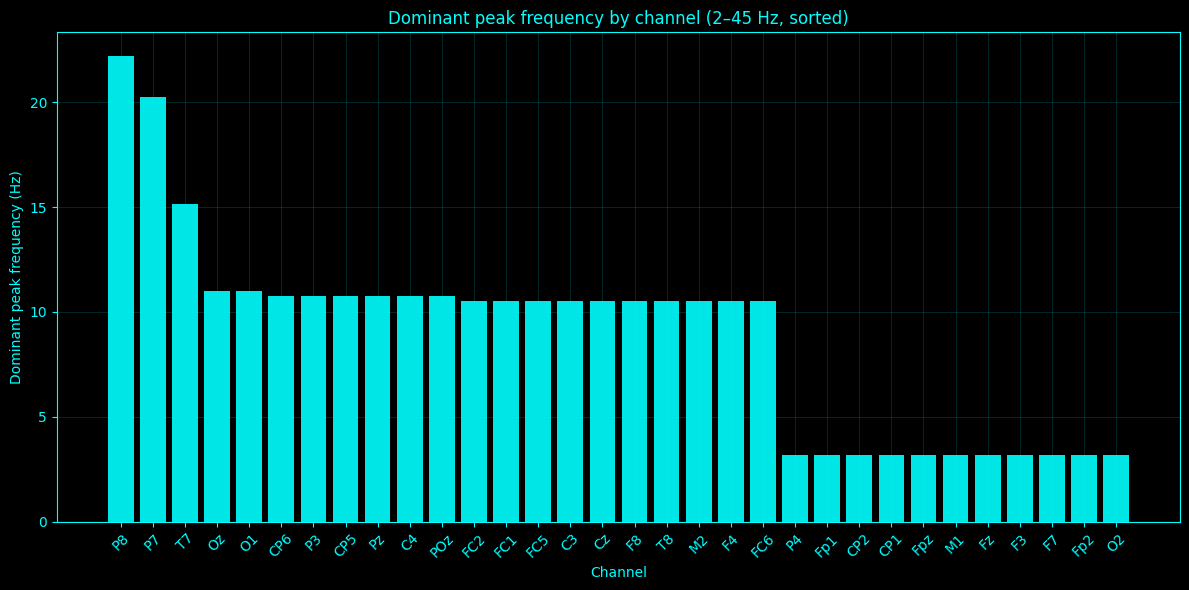

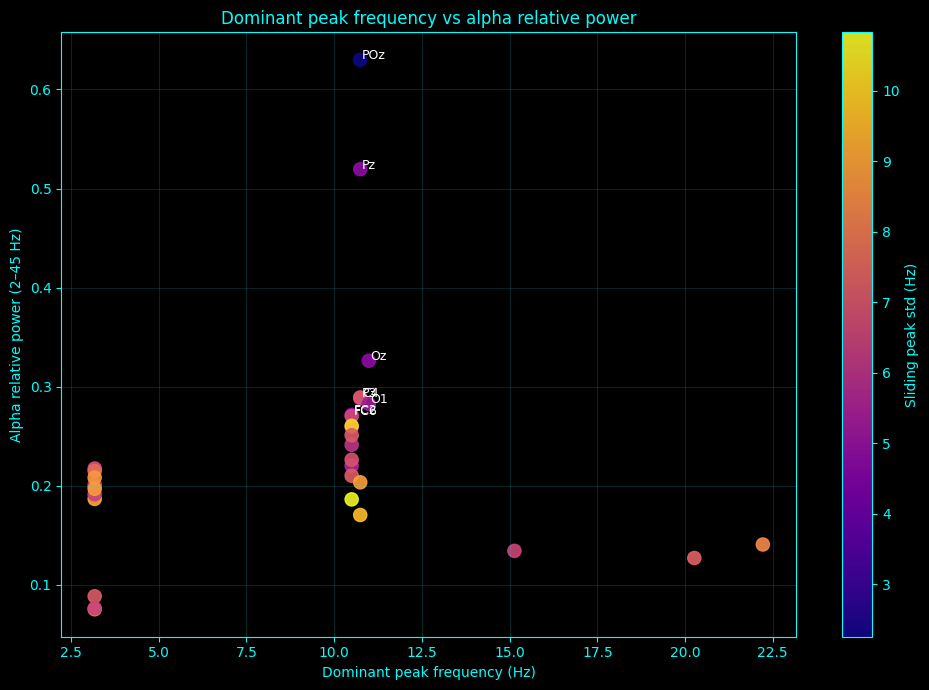

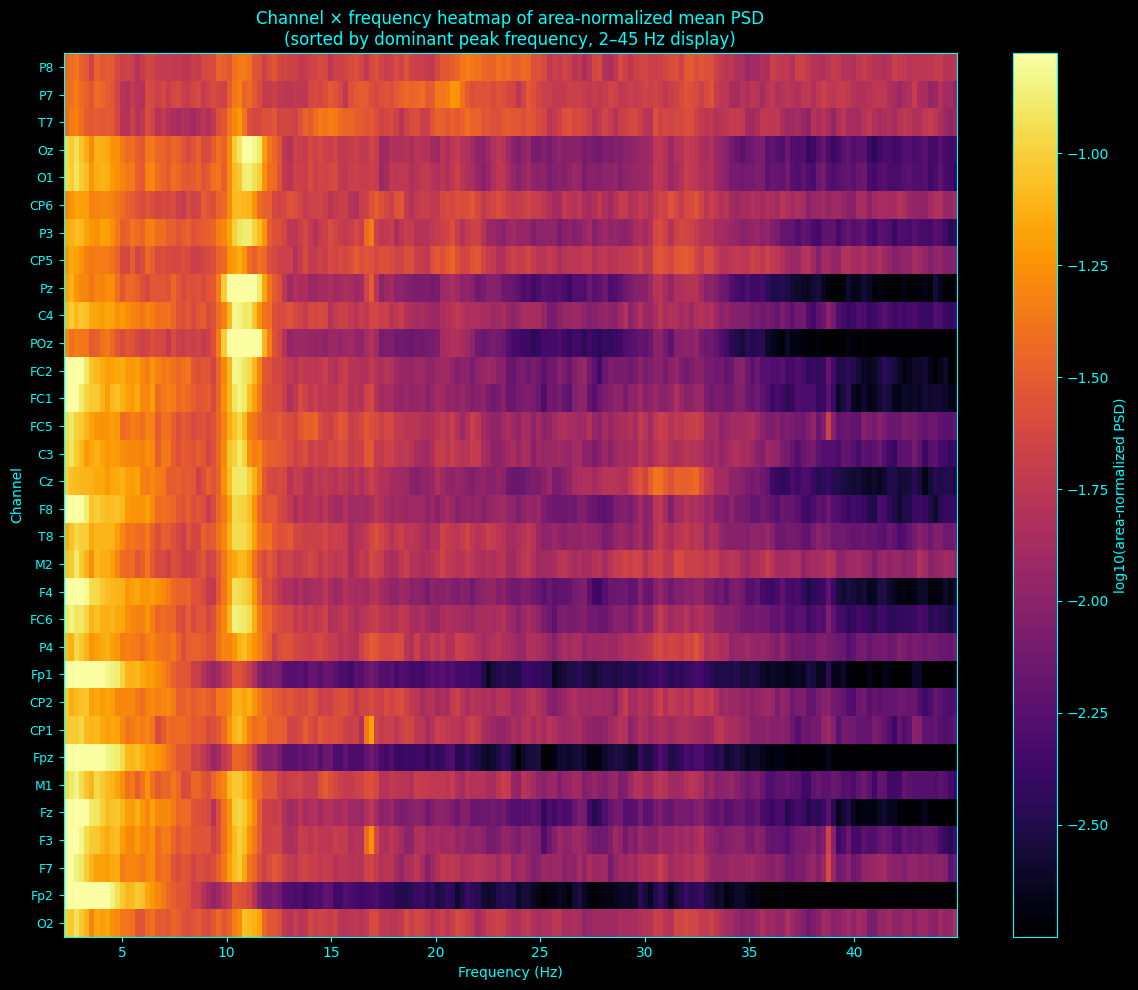

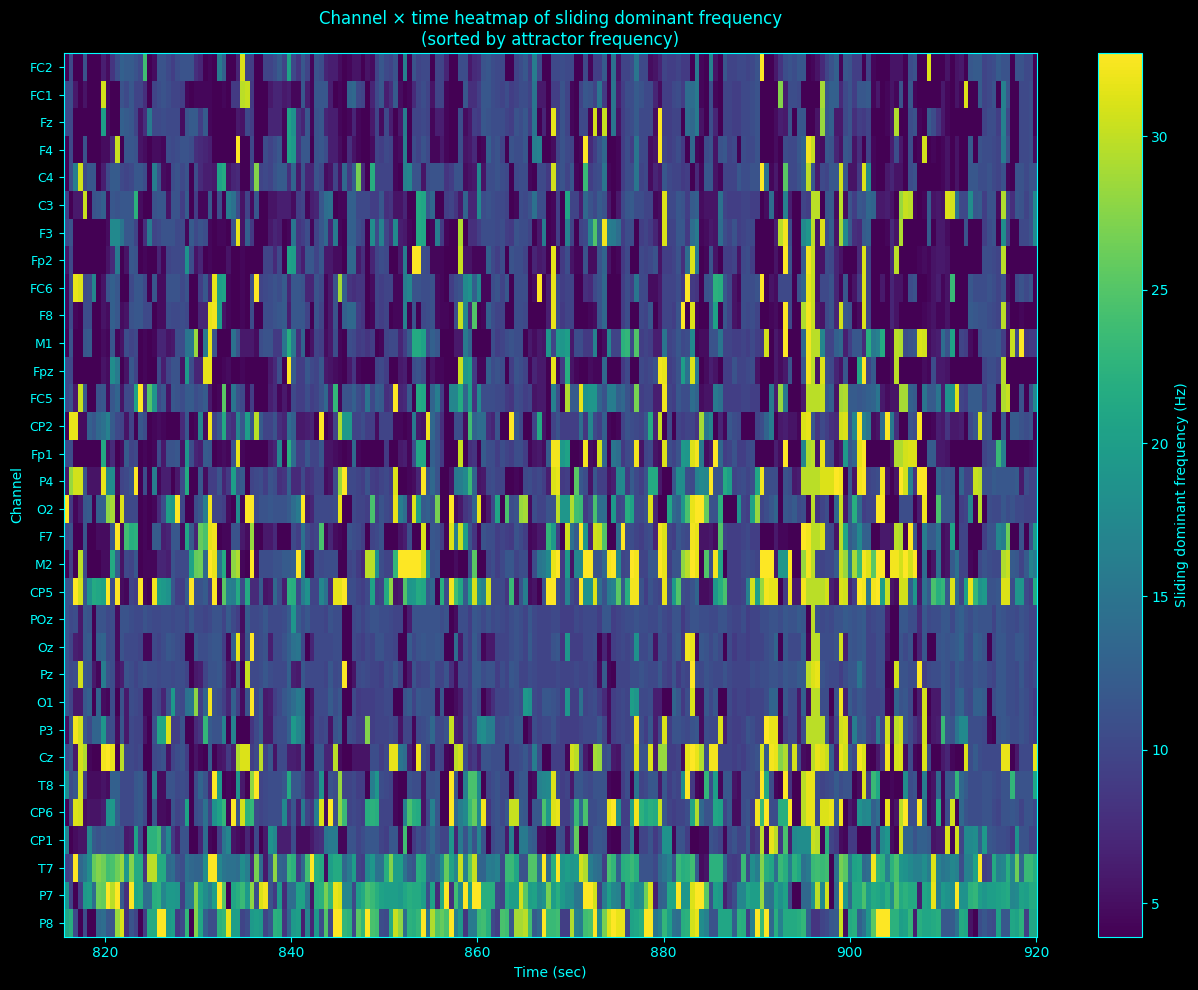

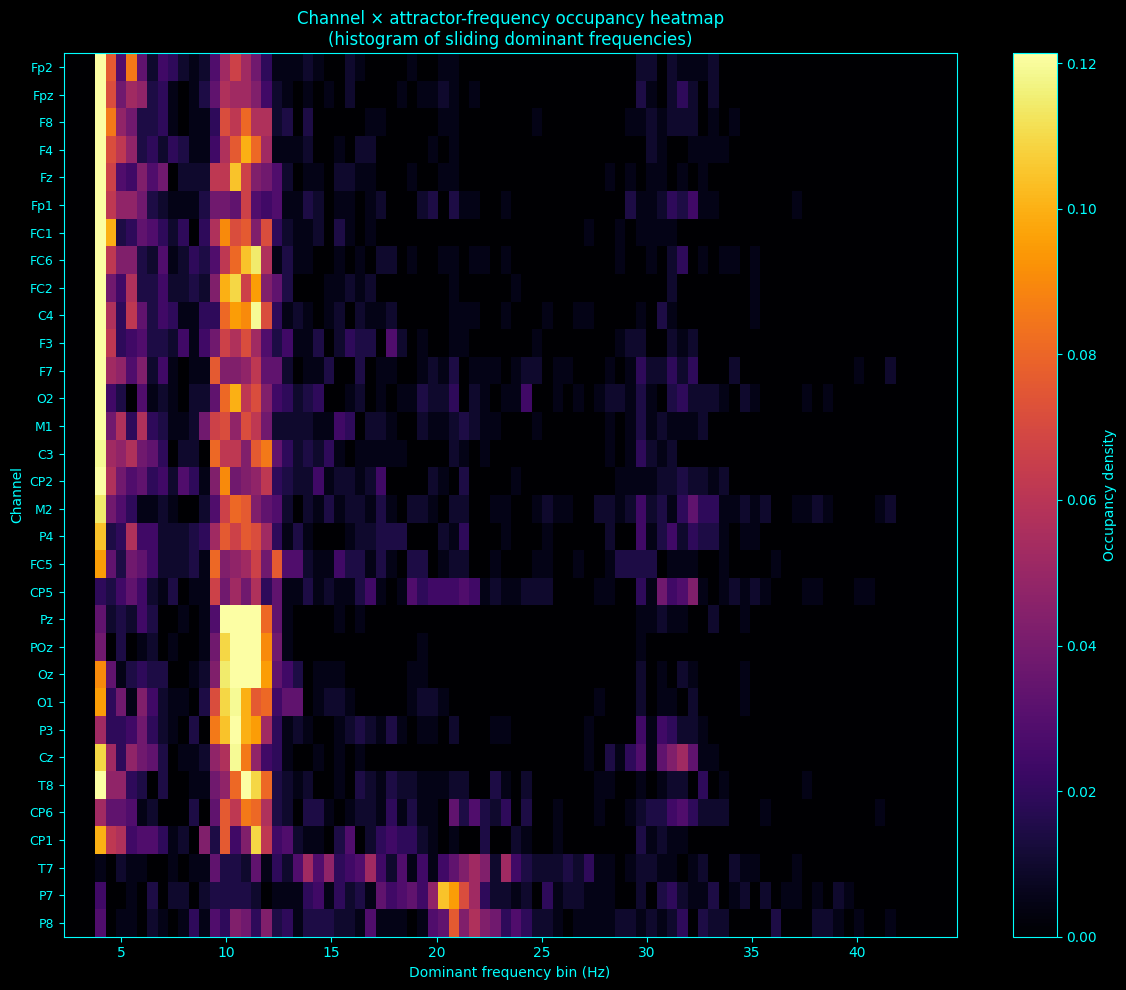

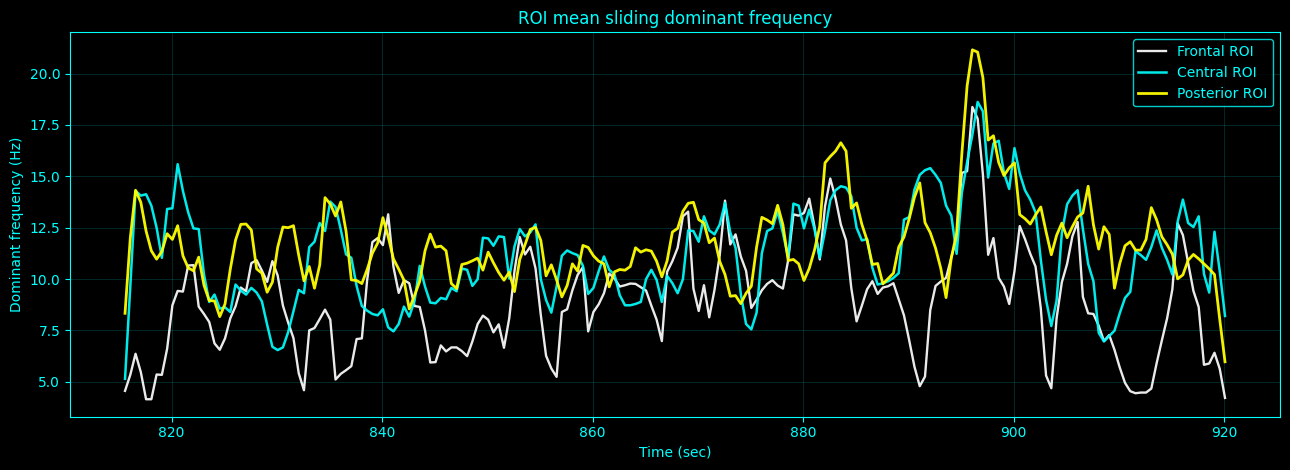

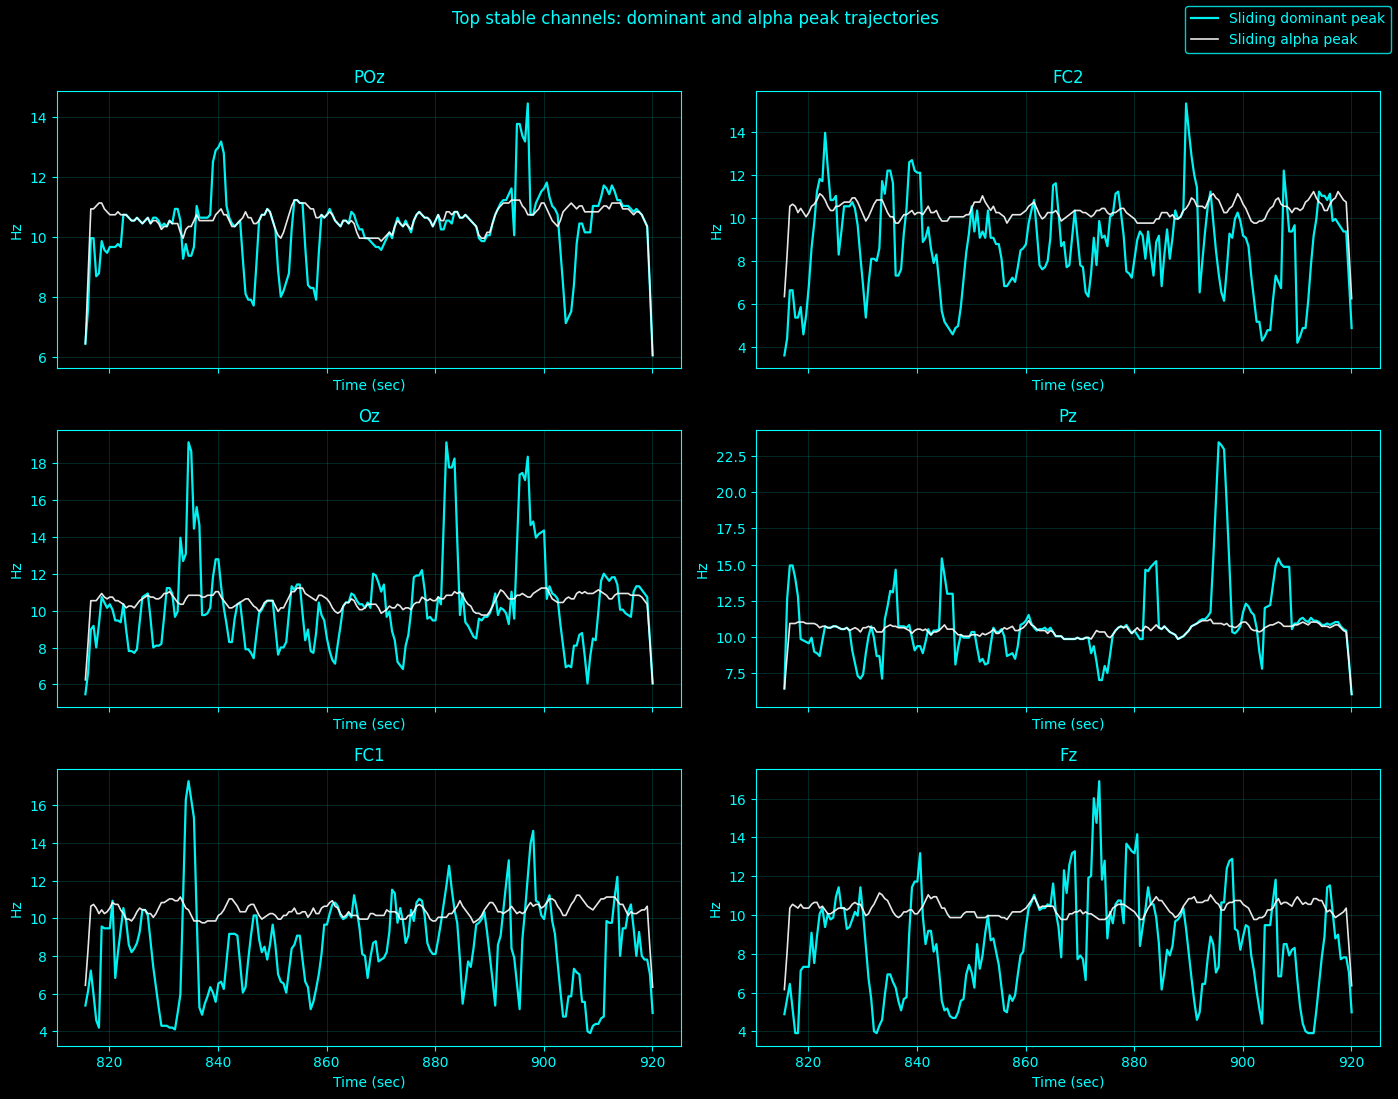


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/PeakFrequencies_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/exploratory_peak_frequency_atlas_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/peak_frequency_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/exploratory_peak_frequency_atlas_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_peak_frequency_atlas/plots
Done.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_peak_frequency_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}
band_names = list(band_defs.keys())

# Welch settings
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 4096
detrend_mode = "constant"
apply_common_average_reference = False

# Sliding spectral-peak settings
sliding_window_sec = 2.0
sliding_step_sec = 0.50
sliding_nfft = 2048

# Frequency attractor histogram
peak_hist_bin_width_hz = 0.5

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def dominant_peak_with_fallback(freqs_hz, spectrum_1d, band=(2.0, 45.0), smooth_win=9):
    """
    Returns a robust dominant frequency estimate.
    First tries to find a real local peak with nontrivial prominence.
    If none exists, falls back to the maximum of the smoothed spectrum in-band.
    """
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) > 0:
        prominences = signal.peak_prominences(y, peaks)[0]
        valid = (peaks > 0) & (peaks < len(y) - 1)
        if np.any(valid):
            peaks = peaks[valid]
            prominences = prominences[valid]

            min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
            strong = prominences >= min_prominence
            if np.any(strong):
                peaks = peaks[strong]
                prominences = prominences[strong]
                winner = int(np.argmax(prominences))
                peak_idx = peaks[winner]

                peak_freq = float(f[peak_idx])
                peak_height = float(y[peak_idx])
                peak_prominence = float(prominences[winner])
                peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
                return peak_freq, peak_height, peak_prominence, peak_contrast, True

    # Fallback: smooth in-band argmax
    idx = int(np.nanargmax(y))
    peak_freq = float(f[idx])
    peak_height = float(y[idx])
    peak_prominence = np.nan
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast, False

def classify_dominant_band(freqs_hz, pxx_norm, band_defs):
    band_values = {}
    for band_name, band in band_defs.items():
        band_values[band_name] = integrate_band_1d(freqs_hz, pxx_norm, band)

    if not np.any(np.isfinite(list(band_values.values()))):
        return "unknown", band_values

    best_band = max(band_values, key=lambda k: (-np.inf if not np.isfinite(band_values[k]) else band_values[k]))
    return best_band, band_values

def sliding_peak_dynamics(y, fs, analysis_band=(2.0, 45.0), alpha_band=(8.0, 13.0),
                          band_defs=None, window_sec=2.0, step_sec=0.5, detrend="constant", nfft=2048):
    win = max(int(round(window_sec * fs)), 256)
    step = max(int(round(step_sec * fs)), 1)

    centers_sec = []
    dominant_peak_series = []
    alpha_peak_series = []
    dominant_band_series = []
    is_local_peak_series = []
    centroid_series = []
    entropy_series = []

    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]

        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend,
            nfft=nfft,
        )

        pxx_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

        dom_peak, _, _, _, is_local = dominant_peak_with_fallback(
            freqs_hz,
            pxx_norm,
            band=analysis_band,
            smooth_win=7,
        )
        alpha_peak, _, _, _, _ = dominant_peak_with_fallback(
            freqs_hz,
            pxx_norm,
            band=alpha_band,
            smooth_win=7,
        )
        dom_band, _ = classify_dominant_band(freqs_hz, pxx_norm, band_defs)
        centroid = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
        _, Hn = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

        centers_sec.append((start + stop) / 2.0 / fs)
        dominant_peak_series.append(dom_peak)
        alpha_peak_series.append(alpha_peak)
        dominant_band_series.append(dom_band)
        is_local_peak_series.append(bool(is_local))
        centroid_series.append(centroid)
        entropy_series.append(Hn)

    return {
        "time_sec_rel": np.asarray(centers_sec),
        "dominant_peak_frequency_Hz": np.asarray(dominant_peak_series),
        "alpha_peak_frequency_Hz": np.asarray(alpha_peak_series),
        "dominant_band": np.asarray(dominant_band_series, dtype=object),
        "is_local_peak": np.asarray(is_local_peak_series, dtype=bool),
        "spectral_centroid_Hz": np.asarray(centroid_series),
        "spectral_entropy_normalized": np.asarray(entropy_series),
    }

def peak_frequency_histogram(peak_series_hz, band=(2.0, 45.0), bin_width_hz=0.5):
    valid = np.asarray(peak_series_hz, dtype=float)
    valid = valid[np.isfinite(valid)]
    valid = valid[(valid >= band[0]) & (valid <= band[1])]

    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)
    if len(valid) == 0:
        hist = np.zeros(len(bins) - 1, dtype=float)
    else:
        hist, _ = np.histogram(valid, bins=bins)
        hist = hist.astype(float)
        hist = hist / (np.sum(hist) + eps)

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, hist

def normalized_hist_entropy(hist):
    hist = np.asarray(hist, dtype=float)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan
    H = -np.sum(hist * np.log(hist + eps))
    Hmax = np.log(len(hist) + eps)
    return float(H / (Hmax + eps))

def band_transition_rate(band_series):
    if len(band_series) < 2:
        return np.nan
    changes = 0
    valid_steps = 0
    for a, b in zip(band_series[:-1], band_series[1:]):
        if a == "unknown" or b == "unknown":
            continue
        valid_steps += 1
        if a != b:
            changes += 1
    if valid_steps == 0:
        return np.nan
    return float(changes / valid_steps)

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
peak_frequency_dict = {}

summary_rows = []
mean_psd_matrix = []
sliding_peak_matrix = []
sliding_alpha_peak_matrix = []
sliding_centroid_matrix = []
sliding_entropy_matrix = []
peak_hist_matrix = []

time_centers_ref = None
freqs_ref = None
peak_hist_centers_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    # Stationary PSD / peak geometry
    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

    dom_peak_hz, dom_peak_height, dom_peak_prominence, dom_peak_contrast, dom_is_local = dominant_peak_with_fallback(
        freqs_hz,
        mean_psd_norm,
        band=analysis_band,
        smooth_win=9,
    )
    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast, alpha_is_local = dominant_peak_with_fallback(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    dom_band, band_values = classify_dominant_band(freqs_hz, mean_psd_norm, band_defs)

    centroid_hz = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

    # Sliding dynamics
    sliding = sliding_peak_dynamics(
        y,
        fs=sampling_rate,
        analysis_band=analysis_band,
        alpha_band=alpha_band,
        band_defs=band_defs,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
        detrend=detrend_mode,
        nfft=sliding_nfft,
    )

    if time_centers_ref is None:
        time_centers_ref = sliding["time_sec_rel"]

    peak_hist_centers, peak_hist = peak_frequency_histogram(
        sliding["dominant_peak_frequency_Hz"],
        band=analysis_band,
        bin_width_hz=peak_hist_bin_width_hz,
    )
    if peak_hist_centers_ref is None:
        peak_hist_centers_ref = peak_hist_centers

    attractor_freq_hz = float(peak_hist_centers[np.argmax(peak_hist)]) if np.any(np.isfinite(peak_hist)) else np.nan
    attractor_entropy = normalized_hist_entropy(peak_hist)

    valid_dom = sliding["dominant_peak_frequency_Hz"][np.isfinite(sliding["dominant_peak_frequency_Hz"])]
    if len(valid_dom) > 0:
        peak_stability_std_hz = float(np.nanstd(valid_dom))
        peak_range_hz = float(np.nanmax(valid_dom) - np.nanmin(valid_dom))
        peak_median_hz = float(np.nanmedian(valid_dom))
    else:
        peak_stability_std_hz = np.nan
        peak_range_hz = np.nan
        peak_median_hz = np.nan

    if np.sum(np.isfinite(sliding["dominant_peak_frequency_Hz"])) > 1:
        diffs = np.abs(np.diff(sliding["dominant_peak_frequency_Hz"]))
        peak_jump_mean_hz = float(np.nanmean(diffs))
    else:
        peak_jump_mean_hz = np.nan

    alpha_occupancy_fraction = float(np.nanmean(
        (sliding["dominant_peak_frequency_Hz"] >= alpha_band[0]) &
        (sliding["dominant_peak_frequency_Hz"] <= alpha_band[1])
    ))

    local_peak_fraction = float(np.nanmean(sliding["is_local_peak"]))
    transition_rate = band_transition_rate(sliding["dominant_band"])

    # Novel exploratory idea:
    # "attractor mismatch" = stationary dominant peak minus sliding attractor frequency.
    # If large, the stationary peak may be averaging over multiple states rather than reflecting the main one.
    stationary_vs_attractor_mismatch = (
        dom_peak_hz - attractor_freq_hz
        if np.isfinite(dom_peak_hz) and np.isfinite(attractor_freq_hz)
        else np.nan
    )

    peak_frequency_dict[ch_name] = {
        "dominant_peak_frequency_Hz": dom_peak_hz,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "dominant_band": dom_band,
        "dominant_peak_is_local": bool(dom_is_local),
        "alpha_peak_is_local": bool(alpha_is_local),
        "stationary_spectral_centroid_Hz": centroid_hz,
        "stationary_spectral_entropy_normalized_2_45Hz": entropy_norm,
        "band_values_area_norm": band_values,
        "sliding_dominant_peak_frequency_Hz": sliding["dominant_peak_frequency_Hz"],
        "sliding_alpha_peak_frequency_Hz": sliding["alpha_peak_frequency_Hz"],
        "sliding_dominant_band": sliding["dominant_band"],
        "sliding_is_local_peak": sliding["is_local_peak"],
        "sliding_spectral_centroid_Hz": sliding["spectral_centroid_Hz"],
        "sliding_spectral_entropy_normalized": sliding["spectral_entropy_normalized"],
        "peak_frequency_hist_centers_Hz": peak_hist_centers,
        "peak_frequency_hist_density": peak_hist,
        "attractor_frequency_Hz": attractor_freq_hz,
        "attractor_entropy": attractor_entropy,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
        "frequencies_hz": freqs_hz,
        "time_sec_rel": sliding["time_sec_rel"],
    }

    summary_rows.append({
        "channel": ch_name,
        "dominant_peak_frequency_Hz_2_45Hz": dom_peak_hz,
        "dominant_peak_height_area_norm": dom_peak_height,
        "dominant_peak_prominence": dom_peak_prominence,
        "dominant_peak_contrast": dom_peak_contrast,
        "dominant_peak_is_local": bool(dom_is_local),
        "dominant_band": dom_band,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_peak_is_local": bool(alpha_is_local),
        "alpha_relative_power_2_45Hz": band_values["alpha"],
        "theta_relative_power_2_45Hz": band_values["theta"],
        "beta_relative_power_2_45Hz": band_values["beta"],
        "delta_relative_power_2_45Hz": band_values["delta"],
        "low_gamma_relative_power_2_45Hz": band_values["low_gamma"],
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "sliding_peak_presence_fraction": float(np.nanmean(np.isfinite(sliding["dominant_peak_frequency_Hz"]))),
        "sliding_local_peak_fraction": local_peak_fraction,
        "sliding_peak_median_Hz": peak_median_hz,
        "sliding_peak_std_Hz": peak_stability_std_hz,
        "sliding_peak_range_Hz": peak_range_hz,
        "sliding_peak_jump_mean_Hz": peak_jump_mean_hz,
        "alpha_occupancy_fraction": alpha_occupancy_fraction,
        "dominant_band_transition_rate": transition_rate,
        "attractor_frequency_Hz": attractor_freq_hz,
        "attractor_entropy": attractor_entropy,
        "stationary_vs_attractor_mismatch_Hz": stationary_vs_attractor_mismatch,
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_peak_matrix.append(sliding["dominant_peak_frequency_Hz"])
    sliding_alpha_peak_matrix.append(sliding["alpha_peak_frequency_Hz"])
    sliding_centroid_matrix.append(sliding["spectral_centroid_Hz"])
    sliding_entropy_matrix.append(sliding["spectral_entropy_normalized"])
    peak_hist_matrix.append(peak_hist)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col not in ["channel", "dominant_band"]:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_peak_matrix = np.column_stack(sliding_peak_matrix)
sliding_alpha_peak_matrix = np.column_stack(sliding_alpha_peak_matrix)
sliding_centroid_matrix = np.column_stack(sliding_centroid_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
peak_hist_matrix = np.column_stack(peak_hist_matrix)
time_sec_abs = start_time + time_centers_ref

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "PeakFrequencies_x.npy")
npz_path = os.path.join(out_dir, "exploratory_peak_frequency_atlas_outputs.npz")
summary_csv_path = os.path.join(out_dir, "peak_frequency_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_peak_frequency_atlas_notes.txt")

np.save(dict_npy_path, peak_frequency_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    peak_hist_centers_Hz=peak_hist_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_dominant_peak_frequency_Hz=sliding_peak_matrix,
    sliding_alpha_peak_frequency_Hz=sliding_alpha_peak_matrix,
    sliding_spectral_centroid_Hz=sliding_centroid_matrix,
    sliding_spectral_entropy_normalized=sliding_entropy_matrix,
    peak_frequency_hist_density=peak_hist_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
)

summary_df.to_csv(summary_csv_path, index=False)

top_dom = summary_df.sort_values("dominant_peak_frequency_Hz_2_45Hz", ascending=False).head(8)
top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_stable = summary_df.sort_values("sliding_peak_std_Hz", ascending=True).head(8)
top_unstable = summary_df.sort_values("sliding_peak_std_Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory peak-frequency atlas notes\n")
    f.write("======================================\n\n")
    f.write("Intent:\n")
    f.write("This pass treats peak frequency as a dynamic spectral-landscape problem rather than a single raw FFT argmax.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Key methodological upgrades relative to the original block:\n")
    f.write("1. Uses the selected recording interval only.\n")
    f.write("2. Uses one-sided Welch PSD in a controlled 2–45 Hz analysis band.\n")
    f.write("3. Separates stationary dominant peak from alpha-specific peak.\n")
    f.write("4. Requires a real local peak when possible, with a fallback estimate when not.\n")
    f.write("5. Adds sliding dominant-frequency trajectories.\n")
    f.write("6. Adds peak-frequency attractor histograms and attractor entropy.\n")
    f.write("7. Adds band-state transition rate and alpha occupancy as dynamic descriptors.\n")
    f.write("8. Adds stationary-vs-attractor mismatch as a novel exploratory check for hidden multistate structure.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis band: [{analysis_band[0]:.1f}, {analysis_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest dominant-frequency channels:\n")
    for _, row in top_dom.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"dom_peak={row['dominant_peak_frequency_Hz_2_45Hz']:.3f} Hz, "
            f"dom_band={row['dominant_band']}, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"attractor={row['attractor_frequency_Hz']:.3f} Hz\n"
        )

    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz, "
            f"alpha_occupancy={row['alpha_occupancy_fraction']:.3f}\n"
        )

    f.write("\nMost stable sliding-peak channels:\n")
    for _, row in top_stable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"peak_std={row['sliding_peak_std_Hz']:.3f} Hz, "
            f"attractor_entropy={row['attractor_entropy']:.3f}, "
            f"transition_rate={row['dominant_band_transition_rate']}\n"
        )

    f.write("\nMost unstable sliding-peak channels:\n")
    for _, row in top_unstable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"peak_std={row['sliding_peak_std_Hz']:.3f} Hz, "
            f"peak_jump_mean={row['sliding_peak_jump_mean_Hz']:.3f}, "
            f"stationary-vs-attractor mismatch={row['stationary_vs_attractor_mismatch_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bar plot of dominant peak frequencies sorted by dominant peak
sort_df = summary_df.sort_values("dominant_peak_frequency_Hz_2_45Hz", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)
ax.bar(sort_df["channel"], sort_df["dominant_peak_frequency_Hz_2_45Hz"], color=ACCENT, alpha=0.9)
ax.set_title("Dominant peak frequency by channel (2–45 Hz, sorted)")
ax.set_xlabel("Channel")
ax.set_ylabel("Dominant peak frequency (Hz)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_dominant_peak_frequency_bar_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Descriptor space: dominant peak vs alpha relative power
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["dominant_peak_frequency_Hz_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["sliding_peak_std_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["dominant_peak_frequency_Hz_2_45Hz"] + 0.05,
        row["alpha_relative_power_2_45Hz"] + 0.0007,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("Dominant peak frequency vs alpha relative power")
ax.set_xlabel("Dominant peak frequency (Hz)")
ax.set_ylabel("Alpha relative power (2–45 Hz)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Sliding peak std (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_peak_vs_alpha_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean PSD, sorted by dominant peak frequency
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, display_band)
freqs_display = freqs_ref[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by dominant peak frequency, 2–45 Hz display)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_peak_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of sliding dominant frequency
dyn_sort_df = summary_df.sort_values(
    by=["attractor_frequency_Hz", "sliding_peak_std_Hz"],
    ascending=[True, True],
).reset_index(drop=True)
dyn_sorted_channels = list(dyn_sort_df["channel"].values)
dyn_sorted_idx = [eeg_channel_names.index(ch) for ch in dyn_sorted_channels]

sliding_heat = sliding_peak_matrix[:, dyn_sorted_idx].T
vmin, vmax = percentile_limits(sliding_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    sliding_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(dyn_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of sliding dominant frequency\n(sorted by attractor frequency)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(dyn_sorted_channels)) + 0.5)
ax.set_yticklabels(dyn_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Sliding dominant frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_sliding_dominant_frequency_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel × attractor-frequency histogram heatmap
attractor_sort_df = summary_df.sort_values(
    by=["attractor_frequency_Hz", "attractor_entropy"],
    ascending=[True, True],
).reset_index(drop=True)
attractor_sorted_channels = list(attractor_sort_df["channel"].values)
attractor_sorted_idx = [eeg_channel_names.index(ch) for ch in attractor_sorted_channels]

heat = peak_hist_matrix[:, attractor_sorted_idx].T
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[peak_hist_centers_ref[0], peak_hist_centers_ref[-1], len(attractor_sorted_channels), 0],
)
ax.set_title("Channel × attractor-frequency occupancy heatmap\n(histogram of sliding dominant frequencies)")
ax.set_xlabel("Dominant frequency bin (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(attractor_sorted_channels)) + 0.5)
ax.set_yticklabels(attractor_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Occupancy density", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_attractor_frequency_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) ROI mean sliding dominant frequency
frontal_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["frontal"])
central_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["central"])
posterior_peak = roi_average_matrix(sliding_peak_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)
ax.plot(time_sec_abs, smooth_1d(frontal_peak, win=5), color="white", linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_1d(central_peak, win=5), color=ACCENT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_1d(posterior_peak, win=5), color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.set_title("ROI mean sliding dominant frequency")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Dominant frequency (Hz)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_roi_mean_sliding_dominant_frequency.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top stable channels: dominant and alpha peak trajectories
top_stable_channels = list(summary_df.sort_values("sliding_peak_std_Hz", ascending=True).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=False)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_stable_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)

    dom_series = smooth_1d(sliding_peak_matrix[:, ch_idx], win=5)
    alpha_series = smooth_1d(sliding_alpha_peak_matrix[:, ch_idx], win=5)

    ax.plot(time_sec_abs, dom_series, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding dominant peak")
    ax.plot(time_sec_abs, alpha_series, color="white", linewidth=1.2, alpha=0.9, label="Sliding alpha peak")
    ax.set_title(ch_name)
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Hz")

for ax in axes[len(top_stable_channels):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top stable channels: dominant and alpha peak trajectories", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_stable_channels_peak_trajectories.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Spectral Edge Density

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code calculates the spectral edge density for multiple EEG channels. Spectral edge density is a feature commonly used in EEG analysis to locate the frequency below which a certain percentage of the total power in the spectrum resides. This is especially helpful for identifying the dominant frequency components in brain activity.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>The Fourier Transform is used to transition from the time domain to the frequency domain. The spectral edge density is computed by first finding the total power in the spectrum:</p>
        \[
        P_{\text{total}} = \sum_{f \geq 0} |F(f)|^2
        \]
        <p>We then set a threshold, based on a given percentage (in this code, 95% is used), of the total power:</p>
        \[
        P_{\text{threshold}} = P_{\text{total}} \times \frac{\text{percentage}}{100}
        \]
        <p>We sum the power in descending order of magnitude and identify the frequency at which this sum first exceeds \( P_{\text{threshold}} \). This frequency is the spectral edge density:</p>
        \[
        f_{\text{edge}} = \text{argmax}_{f \geq 0} \left( \text{cumulative sum}(|F(f)|^2) \geq P_{\text{threshold}} \right)
        \]
        <p>The calculated spectral edge density for each EEG channel is stored in a dictionary named <code>spectral_edge_densities</code>.</p>
        <p>The bar chart plots the spectral edge densities across the EEG channels, providing a quick graphical summary. The calculated values are also saved as a numpy array for further analysis.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


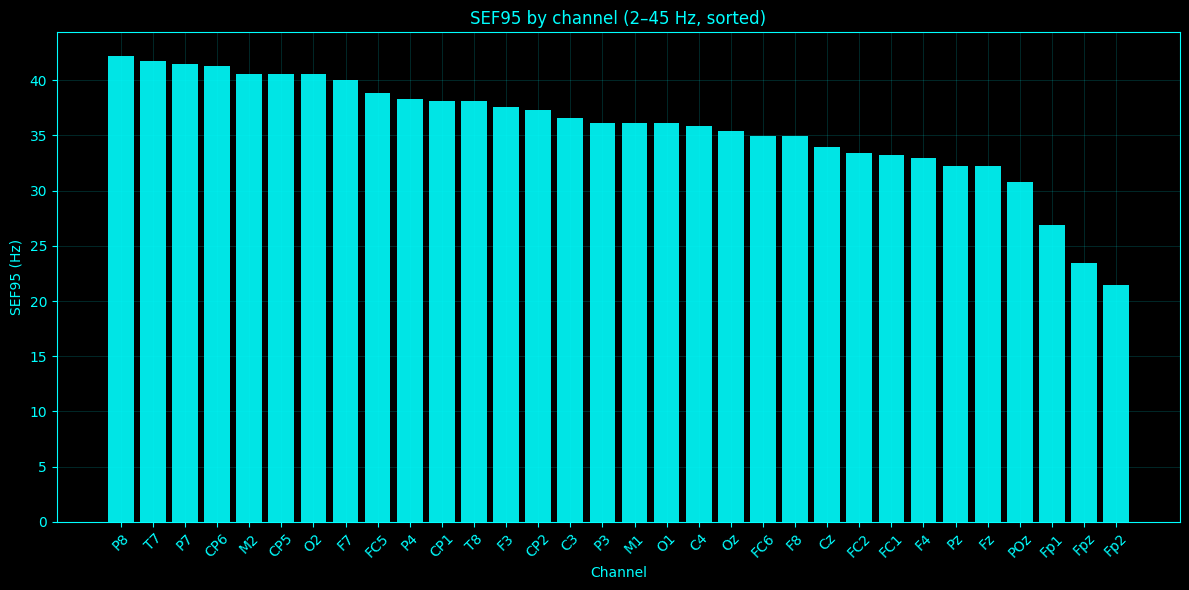

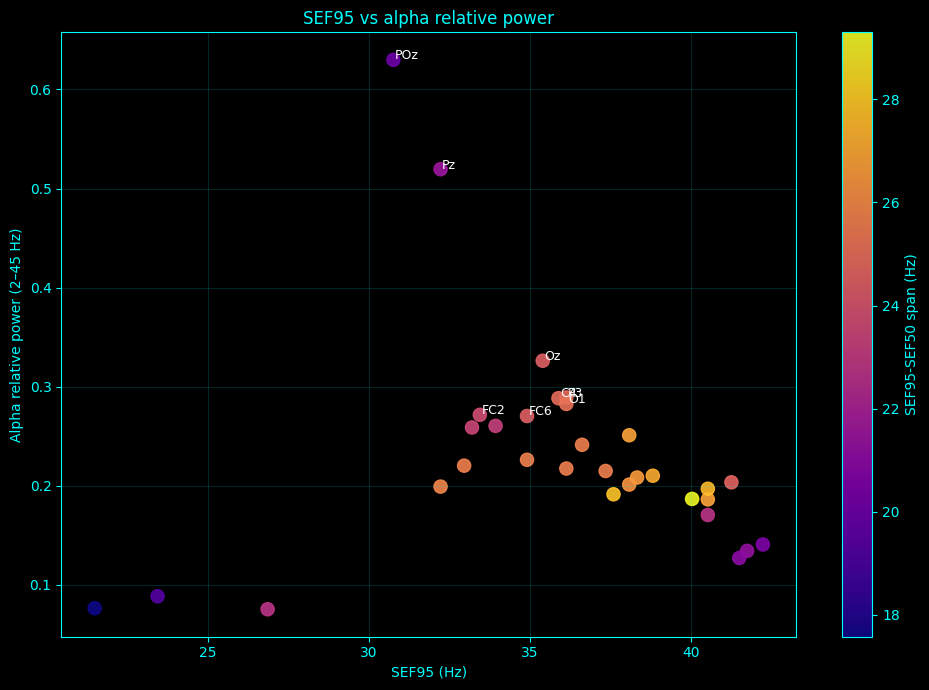

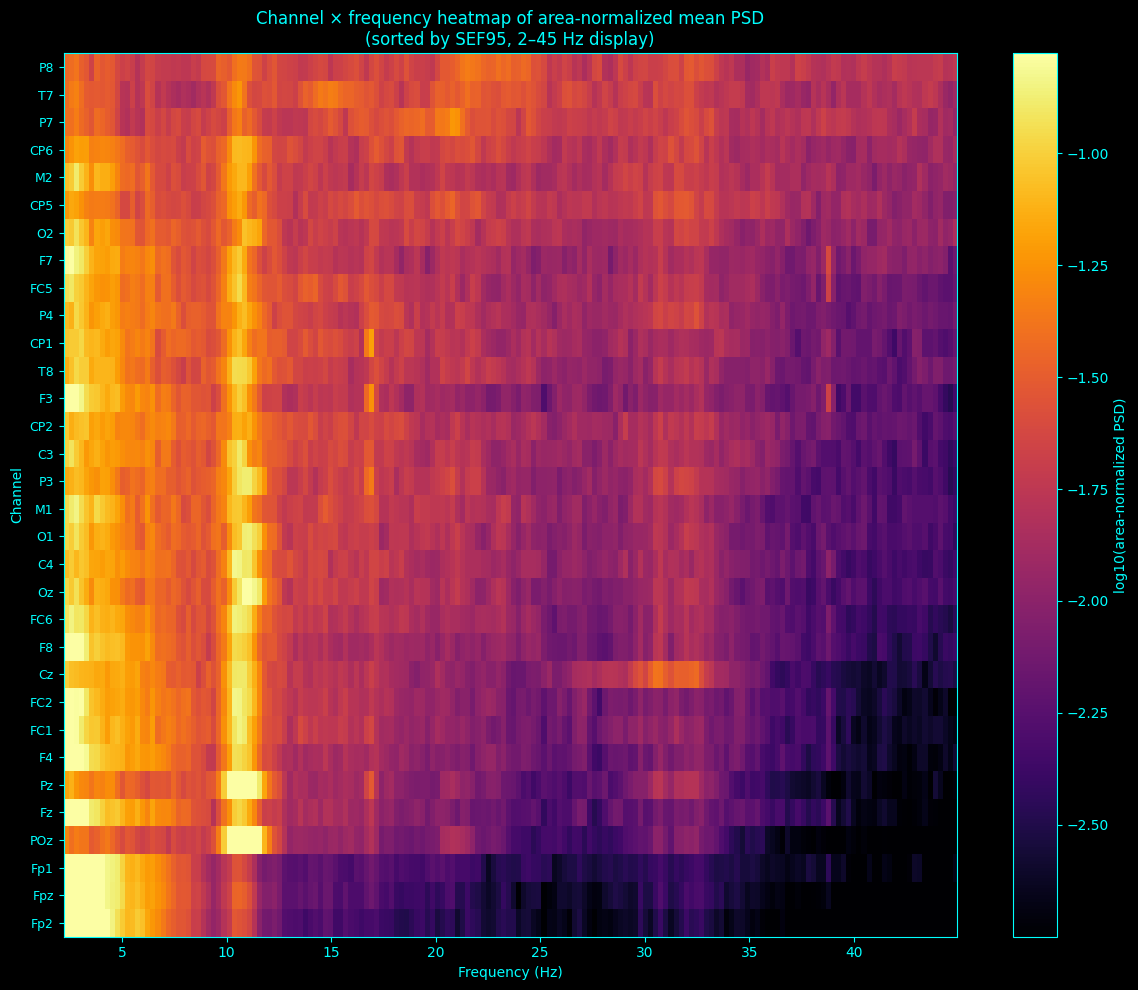

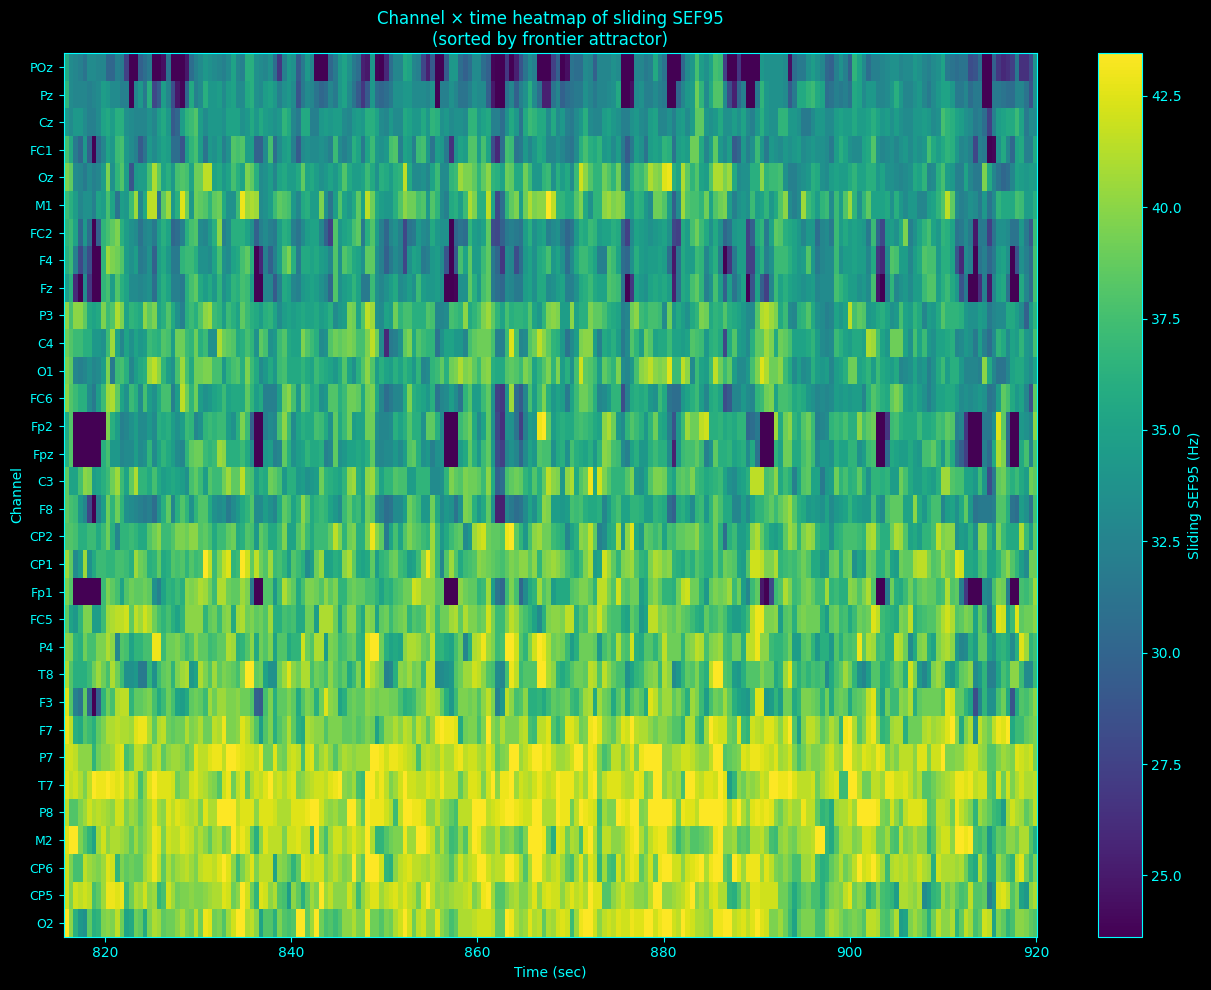

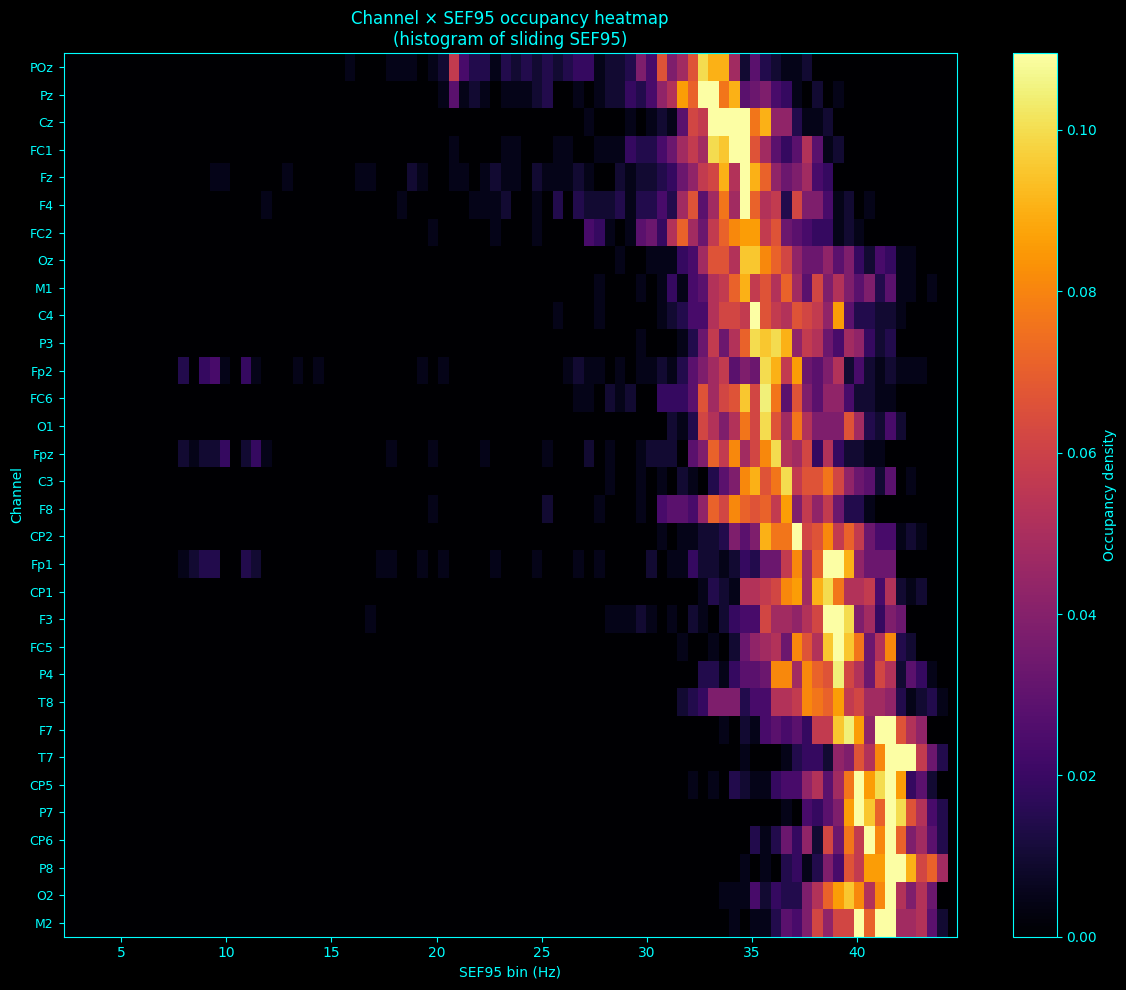

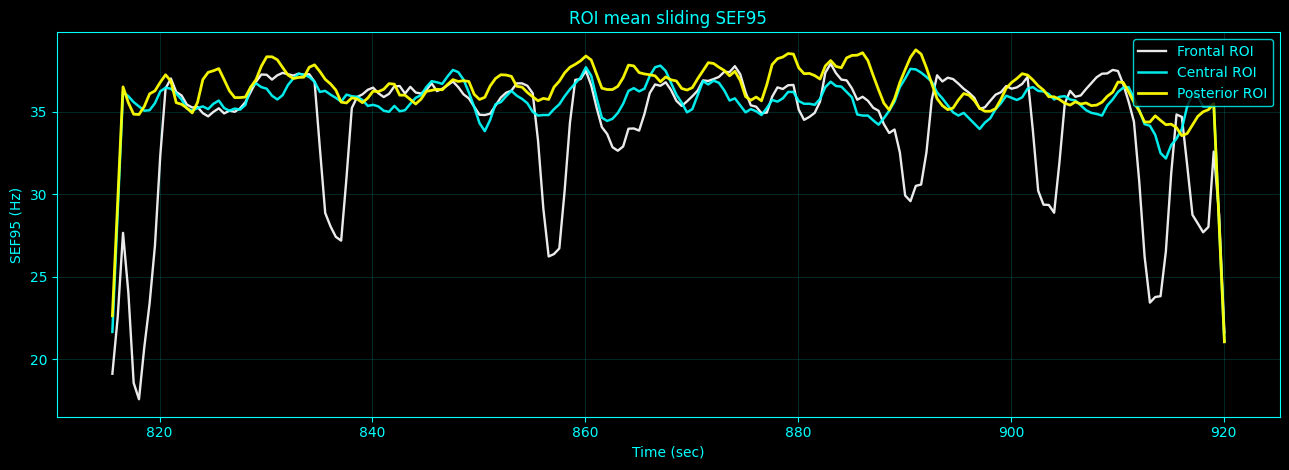

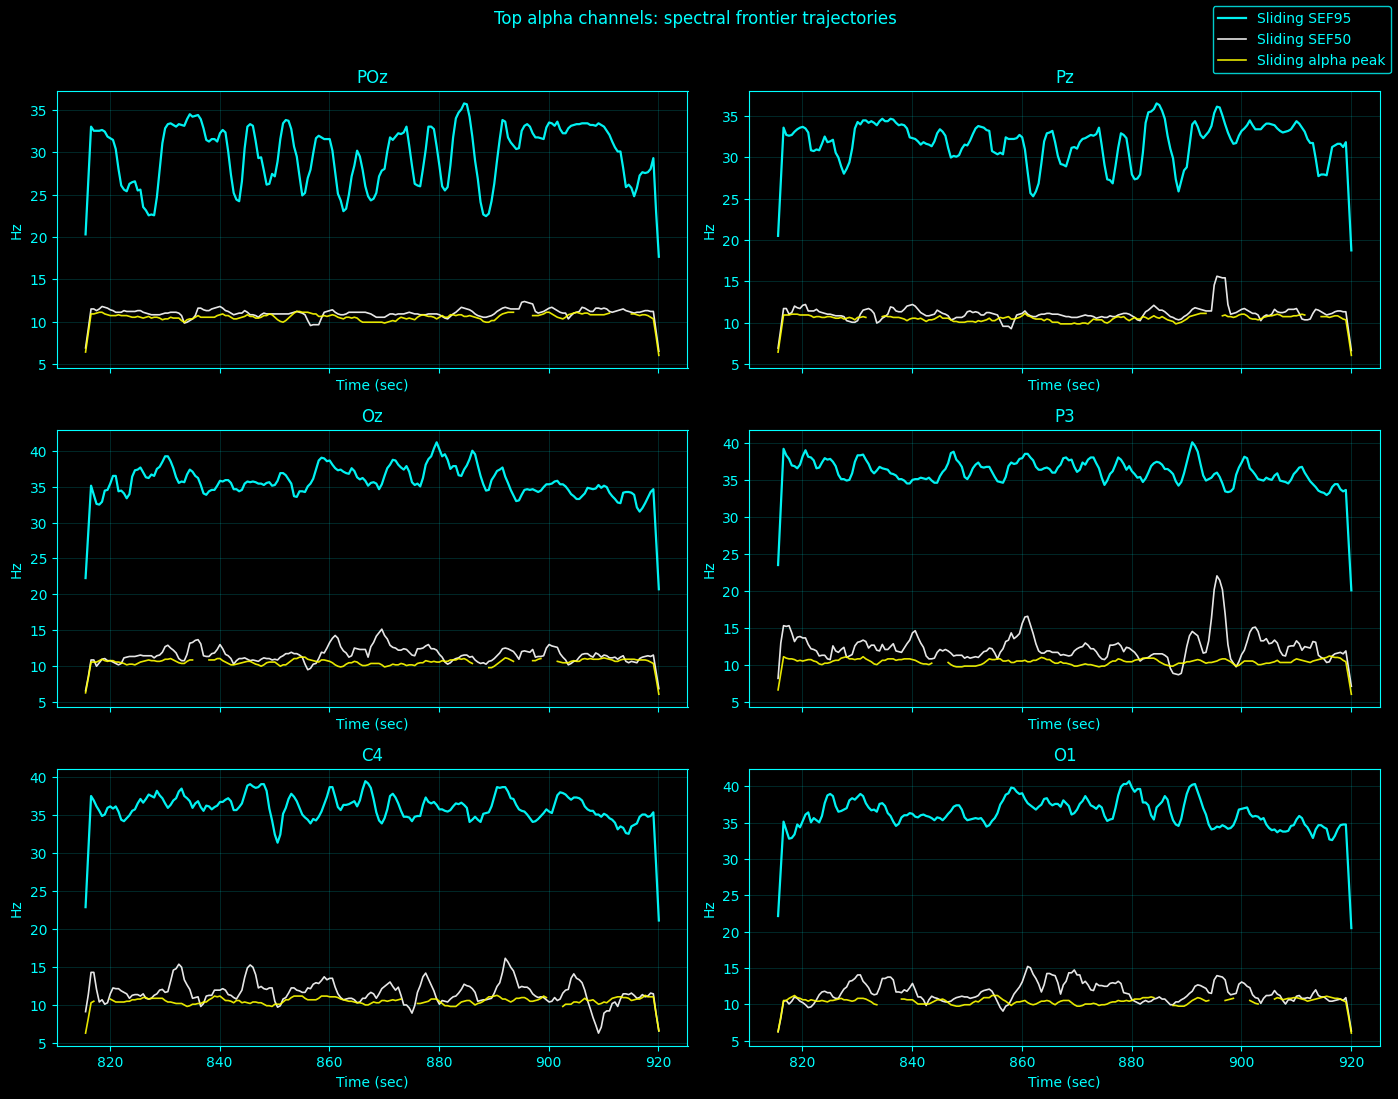


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/SpectralEdgeDensities_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/exploratory_spectral_edge_atlas_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/spectral_edge_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/exploratory_spectral_edge_atlas_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_spectral_edge_atlas/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, integrate

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_spectral_edge_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}

# Welch settings
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 4096
detrend_mode = "constant"
apply_common_average_reference = False

# Sliding spectral-frontier settings
sliding_window_sec = 2.0
sliding_step_sec = 0.50
sliding_nfft = 2048

# Occupancy histogram for sliding SEF95
edge_hist_bin_width_hz = 0.5

# Canonical channel order used in the earlier scripts
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=(2.0, 45.0)):
    """
    Proper SEF:
    cumulative power across increasing frequency within the analysis band.
    """
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    cumulative = integrate.cumulative_trapezoid(p, f, initial=0.0)
    total = cumulative[-1]
    if not np.isfinite(total) or total <= 0:
        return np.nan

    target = edge * total
    idx = int(np.searchsorted(cumulative, target))
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]

    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def sliding_edge_dynamics(y, fs, analysis_band=(2.0, 45.0), alpha_band=(8.0, 13.0),
                          window_sec=2.0, step_sec=0.5, detrend="constant", nfft=2048):
    win = max(int(round(window_sec * fs)), 256)
    step = max(int(round(step_sec * fs)), 1)

    centers_sec = []
    sef50_series = []
    sef90_series = []
    sef95_series = []
    centroid_series = []
    entropy_series = []
    alpha_peak_series = []

    for start in range(0, len(y) - win + 1, step):
        stop = start + win
        chunk = y[start:stop]

        freqs_hz, pxx = welch_psd(
            chunk,
            fs=fs,
            window_sec=min(window_sec, len(chunk) / fs),
            overlap=0.5,
            detrend=detrend,
            nfft=nfft,
        )

        pxx_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

        sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=analysis_band)
        sef90 = spectral_edge_frequency(freqs_hz, pxx, edge=0.90, band=analysis_band)
        sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=analysis_band)
        centroid = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
        _, Hn = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)
        alpha_peak, _, _, _ = robust_peak_in_band(freqs_hz, pxx_norm, band=alpha_band, smooth_win=7)

        centers_sec.append((start + stop) / 2.0 / fs)
        sef50_series.append(sef50)
        sef90_series.append(sef90)
        sef95_series.append(sef95)
        centroid_series.append(centroid)
        entropy_series.append(Hn)
        alpha_peak_series.append(alpha_peak)

    return {
        "time_sec_rel": np.asarray(centers_sec),
        "sef50_Hz": np.asarray(sef50_series),
        "sef90_Hz": np.asarray(sef90_series),
        "sef95_Hz": np.asarray(sef95_series),
        "spectral_centroid_Hz": np.asarray(centroid_series),
        "spectral_entropy_normalized": np.asarray(entropy_series),
        "alpha_peak_frequency_Hz": np.asarray(alpha_peak_series),
    }

def edge_histogram(edge_series_hz, band=(2.0, 45.0), bin_width_hz=0.5):
    valid = np.asarray(edge_series_hz, dtype=float)
    valid = valid[np.isfinite(valid)]
    valid = valid[(valid >= band[0]) & (valid <= band[1])]

    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)
    if len(valid) == 0:
        hist = np.zeros(len(bins) - 1, dtype=float)
    else:
        hist, _ = np.histogram(valid, bins=bins)
        hist = hist.astype(float)
        hist = hist / (np.sum(hist) + eps)

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, hist

def normalized_hist_entropy(hist):
    hist = np.asarray(hist, dtype=float)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan
    H = -np.sum(hist * np.log(hist + eps))
    Hmax = np.log(len(hist) + eps)
    return float(H / (Hmax + eps))

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
spectral_edge_dict = {}

summary_rows = []
mean_psd_matrix = []
sliding_sef50_matrix = []
sliding_sef90_matrix = []
sliding_sef95_matrix = []
sliding_centroid_matrix = []
sliding_entropy_matrix = []
sliding_alpha_peak_matrix = []
edge_hist_matrix = []

time_centers_ref = None
freqs_ref = None
edge_hist_centers_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    # Stationary PSD / frontier geometry
    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

    sef50 = spectral_edge_frequency(freqs_hz, pxx, edge=0.50, band=analysis_band)
    sef90 = spectral_edge_frequency(freqs_hz, pxx, edge=0.90, band=analysis_band)
    sef95 = spectral_edge_frequency(freqs_hz, pxx, edge=0.95, band=analysis_band)

    edge_span_50_95 = sef95 - sef50 if np.isfinite(sef95) and np.isfinite(sef50) else np.nan
    edge_span_90_95 = sef95 - sef90 if np.isfinite(sef95) and np.isfinite(sef90) else np.nan

    centroid_hz = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    alpha_rel = integrate_band_1d(freqs_hz, mean_psd_norm, alpha_band)
    theta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, theta_band)
    beta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, beta_band)
    delta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, delta_band)
    low_gamma_rel = integrate_band_1d(freqs_hz, mean_psd_norm, low_gamma_band)

    # Novel exploratory frontier descriptors
    frontier_alpha_gap = (
        sef50 - alpha_peak_hz
        if np.isfinite(sef50) and np.isfinite(alpha_peak_hz)
        else np.nan
    )
    frontier_centroid_gap = (
        sef95 - centroid_hz
        if np.isfinite(sef95) and np.isfinite(centroid_hz)
        else np.nan
    )

    # Sliding edge dynamics
    sliding = sliding_edge_dynamics(
        y,
        fs=sampling_rate,
        analysis_band=analysis_band,
        alpha_band=alpha_band,
        window_sec=sliding_window_sec,
        step_sec=sliding_step_sec,
        detrend=detrend_mode,
        nfft=sliding_nfft,
    )

    if time_centers_ref is None:
        time_centers_ref = sliding["time_sec_rel"]

    hist_centers, hist_density = edge_histogram(
        sliding["sef95_Hz"],
        band=analysis_band,
        bin_width_hz=edge_hist_bin_width_hz,
    )
    if edge_hist_centers_ref is None:
        edge_hist_centers_ref = hist_centers

    attractor_edge_hz = float(hist_centers[np.argmax(hist_density)]) if np.any(np.isfinite(hist_density)) else np.nan
    attractor_entropy = normalized_hist_entropy(hist_density)

    valid_sef95 = sliding["sef95_Hz"][np.isfinite(sliding["sef95_Hz"])]
    if len(valid_sef95) > 0:
        sef95_std = float(np.nanstd(valid_sef95))
        sef95_range = float(np.nanmax(valid_sef95) - np.nanmin(valid_sef95))
        sef95_median = float(np.nanmedian(valid_sef95))
    else:
        sef95_std = np.nan
        sef95_range = np.nan
        sef95_median = np.nan

    if np.sum(np.isfinite(sliding["sef95_Hz"])) > 1:
        sef95_jump_mean = float(np.nanmean(np.abs(np.diff(sliding["sef95_Hz"]))))
    else:
        sef95_jump_mean = np.nan

    if np.nanstd(sliding["sef95_Hz"]) > 0 and np.nanstd(sliding["spectral_entropy_normalized"]) > 0:
        frontier_entropy_coupling = float(np.corrcoef(sliding["sef95_Hz"], sliding["spectral_entropy_normalized"])[0, 1])
    else:
        frontier_entropy_coupling = np.nan

    if np.nanstd(sliding["sef95_Hz"]) > 0 and np.nanstd(sliding["spectral_centroid_Hz"]) > 0:
        frontier_centroid_coupling = float(np.corrcoef(sliding["sef95_Hz"], sliding["spectral_centroid_Hz"])[0, 1])
    else:
        frontier_centroid_coupling = np.nan

    frontier_alpha_gap_series = sliding["sef50_Hz"] - sliding["alpha_peak_frequency_Hz"]
    frontier_alpha_gap_mean = float(np.nanmean(frontier_alpha_gap_series))
    frontier_alpha_gap_std = float(np.nanstd(frontier_alpha_gap_series))

    stationary_vs_attractor_mismatch = (
        sef95 - attractor_edge_hz
        if np.isfinite(sef95) and np.isfinite(attractor_edge_hz)
        else np.nan
    )

    spectral_edge_dict[ch_name] = {
        "sef50_Hz": sef50,
        "sef90_Hz": sef90,
        "sef95_Hz": sef95,
        "edge_span_50_95_Hz": edge_span_50_95,
        "edge_span_90_95_Hz": edge_span_90_95,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "frontier_alpha_gap_Hz": frontier_alpha_gap,
        "frontier_centroid_gap_Hz": frontier_centroid_gap,
        "sliding_sef50_Hz": sliding["sef50_Hz"],
        "sliding_sef90_Hz": sliding["sef90_Hz"],
        "sliding_sef95_Hz": sliding["sef95_Hz"],
        "sliding_spectral_centroid_Hz": sliding["spectral_centroid_Hz"],
        "sliding_spectral_entropy_normalized": sliding["spectral_entropy_normalized"],
        "sliding_alpha_peak_frequency_Hz": sliding["alpha_peak_frequency_Hz"],
        "edge_hist_centers_Hz": hist_centers,
        "edge_hist_density": hist_density,
        "attractor_edge_Hz": attractor_edge_hz,
        "attractor_entropy": attractor_entropy,
        "frequencies_hz": freqs_hz,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
        "time_sec_rel": sliding["time_sec_rel"],
    }

    summary_rows.append({
        "channel": ch_name,
        "sef50_Hz_2_45Hz": sef50,
        "sef90_Hz_2_45Hz": sef90,
        "sef95_Hz_2_45Hz": sef95,
        "edge_span_50_95_Hz": edge_span_50_95,
        "edge_span_90_95_Hz": edge_span_90_95,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "delta_relative_power_2_45Hz": delta_rel,
        "low_gamma_relative_power_2_45Hz": low_gamma_rel,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "frontier_alpha_gap_Hz": frontier_alpha_gap,
        "frontier_centroid_gap_Hz": frontier_centroid_gap,
        "sliding_sef95_median_Hz": sef95_median,
        "sliding_sef95_std_Hz": sef95_std,
        "sliding_sef95_range_Hz": sef95_range,
        "sliding_sef95_jump_mean_Hz": sef95_jump_mean,
        "frontier_entropy_coupling": frontier_entropy_coupling,
        "frontier_centroid_coupling": frontier_centroid_coupling,
        "frontier_alpha_gap_mean_Hz": frontier_alpha_gap_mean,
        "frontier_alpha_gap_std_Hz": frontier_alpha_gap_std,
        "attractor_edge_Hz": attractor_edge_hz,
        "attractor_entropy": attractor_entropy,
        "stationary_vs_attractor_mismatch_Hz": stationary_vs_attractor_mismatch,
    })

    mean_psd_matrix.append(mean_psd_norm)
    sliding_sef50_matrix.append(sliding["sef50_Hz"])
    sliding_sef90_matrix.append(sliding["sef90_Hz"])
    sliding_sef95_matrix.append(sliding["sef95_Hz"])
    sliding_centroid_matrix.append(sliding["spectral_centroid_Hz"])
    sliding_entropy_matrix.append(sliding["spectral_entropy_normalized"])
    sliding_alpha_peak_matrix.append(sliding["alpha_peak_frequency_Hz"])
    edge_hist_matrix.append(hist_density)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
sliding_sef50_matrix = np.column_stack(sliding_sef50_matrix)
sliding_sef90_matrix = np.column_stack(sliding_sef90_matrix)
sliding_sef95_matrix = np.column_stack(sliding_sef95_matrix)
sliding_centroid_matrix = np.column_stack(sliding_centroid_matrix)
sliding_entropy_matrix = np.column_stack(sliding_entropy_matrix)
sliding_alpha_peak_matrix = np.column_stack(sliding_alpha_peak_matrix)
edge_hist_matrix = np.column_stack(edge_hist_matrix)
time_sec_abs = start_time + time_centers_ref

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "SpectralEdgeDensities_x.npy")
npz_path = os.path.join(out_dir, "exploratory_spectral_edge_atlas_outputs.npz")
summary_csv_path = os.path.join(out_dir, "spectral_edge_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_spectral_edge_atlas_notes.txt")

np.save(dict_npy_path, spectral_edge_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    time_sec_abs=time_sec_abs,
    time_sec_rel=time_centers_ref,
    edge_hist_centers_Hz=edge_hist_centers_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    sliding_sef50_Hz=sliding_sef50_matrix,
    sliding_sef90_Hz=sliding_sef90_matrix,
    sliding_sef95_Hz=sliding_sef95_matrix,
    sliding_spectral_centroid_Hz=sliding_centroid_matrix,
    sliding_spectral_entropy_normalized=sliding_entropy_matrix,
    sliding_alpha_peak_frequency_Hz=sliding_alpha_peak_matrix,
    edge_hist_density=edge_hist_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    analysis_band=np.array(analysis_band, dtype=float),
    welch_window_sec=welch_window_sec,
    sliding_window_sec=sliding_window_sec,
    sliding_step_sec=sliding_step_sec,
)

summary_df.to_csv(summary_csv_path, index=False)

top_sef95 = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=False).head(8)
low_sef95 = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=True).head(8)
top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_stable = summary_df.sort_values("sliding_sef95_std_Hz", ascending=True).head(8)
top_unstable = summary_df.sort_values("sliding_sef95_std_Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory spectral edge atlas notes\n")
    f.write("=====================================\n\n")
    f.write("Intent:\n")
    f.write("This pass treats spectral edge as a dynamic spectral-frontier problem rather than a raw FFT magnitude trick.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Why the original version failed:\n")
    f.write("1. It sorted magnitudes instead of integrating power across increasing frequency.\n")
    f.write("2. It used raw FFT magnitude rather than a stable PSD estimate.\n")
    f.write("3. It ignored the selected segment of interest and physiological band control.\n\n")
    f.write("What this version adds:\n")
    f.write("1. Proper one-sided Welch PSD.\n")
    f.write("2. Proper SEF50 / SEF90 / SEF95 in 2–45 Hz.\n")
    f.write("3. Frontier geometry: edge spans, alpha anchoring, centroid gap.\n")
    f.write("4. Sliding SEF dynamics over time.\n")
    f.write("5. Frontier occupancy histograms and attractor entropy.\n")
    f.write("6. Novel exploratory descriptors: frontier mobility, frontier-entropy coupling, frontier-alpha gap stability,\n")
    f.write("   and stationary-vs-attractor mismatch.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis band: [{analysis_band[0]:.1f}, {analysis_band[1]:.1f}] Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Sliding window: {sliding_window_sec:.2f} sec\n")
    f.write(f"Sliding step: {sliding_step_sec:.2f} sec\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest SEF95 channels:\n")
    for _, row in top_sef95.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95={row['sef95_Hz_2_45Hz']:.3f} Hz, "
            f"SEF50={row['sef50_Hz_2_45Hz']:.3f} Hz, "
            f"edge_span={row['edge_span_50_95_Hz']:.3f} Hz, "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}\n"
        )

    f.write("\nLowest SEF95 channels:\n")
    for _, row in low_sef95.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95={row['sef95_Hz_2_45Hz']:.3f} Hz, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"frontier_alpha_gap={row['frontier_alpha_gap_Hz']}\n"
        )

    f.write("\nTop alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz, "
            f"SEF50={row['sef50_Hz_2_45Hz']:.3f} Hz\n"
        )

    f.write("\nMost stable sliding-SEF95 channels:\n")
    for _, row in top_stable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95 std={row['sliding_sef95_std_Hz']:.3f} Hz, "
            f"attractor_entropy={row['attractor_entropy']:.3f}, "
            f"frontier_entropy_coupling={row['frontier_entropy_coupling']}\n"
        )

    f.write("\nMost unstable sliding-SEF95 channels:\n")
    for _, row in top_unstable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"SEF95 std={row['sliding_sef95_std_Hz']:.3f} Hz, "
            f"SEF95 jump mean={row['sliding_sef95_jump_mean_Hz']:.3f} Hz, "
            f"stationary-vs-attractor mismatch={row['stationary_vs_attractor_mismatch_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Bar plot of SEF95 sorted by SEF95
sort_df = summary_df.sort_values("sef95_Hz_2_45Hz", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
style_ax(ax)
ax.bar(sort_df["channel"], sort_df["sef95_Hz_2_45Hz"], color=ACCENT, alpha=0.9)
ax.set_title("SEF95 by channel (2–45 Hz, sorted)")
ax.set_xlabel("Channel")
ax.set_ylabel("SEF95 (Hz)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_sef95_bar_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Descriptor space: SEF95 vs alpha relative power
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["sef95_Hz_2_45Hz"].values,
    summary_df["alpha_relative_power_2_45Hz"].values,
    c=summary_df["edge_span_50_95_Hz"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    ax.text(
        row["sef95_Hz_2_45Hz"] + 0.05,
        row["alpha_relative_power_2_45Hz"] + 0.0007,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("SEF95 vs alpha relative power")
ax.set_xlabel("SEF95 (Hz)")
ax.set_ylabel("Alpha relative power (2–45 Hz)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("SEF95-SEF50 span (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_sef95_vs_alpha_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean PSD, sorted by SEF95
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, display_band)
freqs_display = freqs_ref[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by SEF95, 2–45 Hz display)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_sef_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of sliding SEF95
dyn_sort_df = summary_df.sort_values(
    by=["attractor_edge_Hz", "sliding_sef95_std_Hz"],
    ascending=[True, True],
).reset_index(drop=True)
dyn_sorted_channels = list(dyn_sort_df["channel"].values)
dyn_sorted_idx = [eeg_channel_names.index(ch) for ch in dyn_sorted_channels]

sliding_heat = sliding_sef95_matrix[:, dyn_sorted_idx].T
vmin, vmax = percentile_limits(sliding_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    sliding_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs[0], time_sec_abs[-1], len(dyn_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of sliding SEF95\n(sorted by frontier attractor)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(dyn_sorted_channels)) + 0.5)
ax.set_yticklabels(dyn_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Sliding SEF95 (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_sliding_sef95_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel × SEF95 occupancy heatmap
edge_sort_df = summary_df.sort_values(
    by=["attractor_edge_Hz", "attractor_entropy"],
    ascending=[True, True],
).reset_index(drop=True)
edge_sorted_channels = list(edge_sort_df["channel"].values)
edge_sorted_idx = [eeg_channel_names.index(ch) for ch in edge_sorted_channels]

heat = edge_hist_matrix[:, edge_sorted_idx].T
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[edge_hist_centers_ref[0], edge_hist_centers_ref[-1], len(edge_sorted_channels), 0],
)
ax.set_title("Channel × SEF95 occupancy heatmap\n(histogram of sliding SEF95)")
ax.set_xlabel("SEF95 bin (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(edge_sorted_channels)) + 0.5)
ax.set_yticklabels(edge_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Occupancy density", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_sef95_occupancy_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) ROI mean sliding SEF95
frontal_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["frontal"])
central_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["central"])
posterior_sef95 = roi_average_matrix(sliding_sef95_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BG)
style_ax(ax)
ax.plot(time_sec_abs, smooth_1d(frontal_sef95, win=5), color="white", linewidth=1.7, alpha=0.92, label="Frontal ROI")
ax.plot(time_sec_abs, smooth_1d(central_sef95, win=5), color=ACCENT, linewidth=1.8, alpha=0.92, label="Central ROI")
ax.plot(time_sec_abs, smooth_1d(posterior_sef95, win=5), color="yellow", linewidth=2.0, alpha=0.95, label="Posterior ROI")
ax.set_title("ROI mean sliding SEF95")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("SEF95 (Hz)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_roi_mean_sliding_sef95.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top alpha channels: SEF95, SEF50, and alpha peak trajectories
top_alpha_channels = list(summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=False)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_alpha_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)

    sef95_series = smooth_1d(sliding_sef95_matrix[:, ch_idx], win=5)
    sef50_series = smooth_1d(sliding_sef50_matrix[:, ch_idx], win=5)
    alpha_series = smooth_1d(sliding_alpha_peak_matrix[:, ch_idx], win=5)

    ax.plot(time_sec_abs, sef95_series, color=ACCENT, linewidth=1.6, alpha=0.95, label="Sliding SEF95")
    ax.plot(time_sec_abs, sef50_series, color="white", linewidth=1.2, alpha=0.9, label="Sliding SEF50")
    ax.plot(time_sec_abs, alpha_series, color="yellow", linewidth=1.2, alpha=0.9, label="Sliding alpha peak")
    ax.set_title(ch_name)
    ax.set_xlabel("Time (sec)")
    ax.set_ylabel("Hz")

for ax in axes[len(top_alpha_channels):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top alpha channels: spectral frontier trajectories", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_alpha_channels_frontier_trajectories.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

# Continuous Wavelet Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This code focuses on extracting wavelet coefficients from EEG data across multiple channels. It uses Continuous Wavelet Transform (CWT) for time-frequency analysis. The aim is to identify time-locked events and analyze localized frequency content of the EEG signals.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>The Continuous Wavelet Transform is used to analyze signals in both the time and frequency domains simultaneously. The wavelet is a small wave that is used to analyze localized variations in a signal. In this code, the 'morl' (Morlet) wavelet is used for transformation.</p>
        \[
        CWT_{x}(a, b) = \frac{1}{\sqrt{|a|}} \int x(t)\psi \left( \frac{t-b}{a} \right) dt
        \]
        <p>Where \( \psi \) is the wavelet function, \( a \) is the scaling parameter, and \( b \) is the translation parameter.</p>
        <p>The CWT is calculated at logarithmically spaced frequencies, making it suitable for analyzing signals that contain components at multiple scales.</p>
        <p>Each channel's wavelet coefficients are stored in a dictionary, <code>wavelet_coefficients</code>, and the coefficients are also visualized using a heatmap. This enables easy comparison between channels and provides a sense of how the frequency content changes over time.</p>
        <p>The wavelet coefficients are saved as a numpy array for subsequent analyses. The output is saved to the directory specified in the <code>results_path</code> and <code>results_file</code> variables.</p>
    </div>
</div>